# SDV Models: Comprehensive Evaluation - Wine Quality (White Wine)

This notebook evaluates four synthetic data generation models on the **White Wine Quality** dataset:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using fidelity metrics (KS, JS divergence, Wasserstein) and utility (TSTR/TRTR with 10 classifiers). Target variable: **quality** (multiclass).


## 1. Data Loading and Setup


In [2]:
import pandas as pd
from sdv.metadata import SingleTableMetadata
import warnings
warnings.filterwarnings('ignore')

# Load White Wine Quality dataset (semicolon-separated)
# Path works when run from project root or from Notebooks folder
import os
_csv_paths = [
    'Datasets/wine+quality/winequality-white.csv',
    '../Datasets/wine+quality/winequality-white.csv',
]
csv_path = next((p for p in _csv_paths if os.path.exists(p)), _csv_paths[0])
wine_data = pd.read_csv(csv_path, sep=';')

# Basic info
print("Data shape:", wine_data.shape)
print("Columns:", list(wine_data.columns))
print("\nQuality distribution:")
print(wine_data['quality'].value_counts().sort_index())

# Detect metadata for SDV
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(wine_data)
print(f"\nMetadata detected. Columns: {len(wine_data.columns)}")

Data shape: (4898, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Quality distribution:
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

Metadata detected. Columns: 12


## 2. Helper Functions – Plotting and TSTR/TRTR Evaluation


In [58]:
import numpy as np
import matplotlib.pyplot as plt

def plot_comparison_all_models(results_df, metric='AUC', title_suffix=''):
    trtr_col = f"{metric}_TRTR"
    tstr_col = f"{metric}_TSTR"
    if trtr_col not in results_df.columns or tstr_col not in results_df.columns:
        print(f"Warning: {trtr_col} or {tstr_col} not found")
        return
    results_df = results_df.copy()
    results_df['Drop'] = results_df[trtr_col] - results_df[tstr_col]
    results_df = results_df.sort_values('Drop', ascending=False)
    x = np.arange(len(results_df))
    w = 0.35
    fig, ax = plt.subplots(figsize=(14, 6))
    bars_trtr = ax.bar(x - w/2, results_df[trtr_col], w, label=f'{metric} TRTR', alpha=0.8)
    bars_tstr = ax.bar(x + w/2, results_df[tstr_col], w, label=f'{metric} TSTR', alpha=0.8)
    # Label TRTR and TSTR values on bars
    for i, (v_trtr, v_tstr, drop) in enumerate(zip(results_df[trtr_col], results_df[tstr_col], results_df['Drop'])):
        ax.text(x[i] - w/2, v_trtr + 0.01, f'{v_trtr:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.text(x[i] + w/2, v_tstr + 0.01, f'{v_tstr:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        # Show drop clearly between the two bars
        ax.text(x[i], (v_trtr + v_tstr) / 2, f'Drop: {drop:.2f}', ha='center', va='center', fontsize=8, color='darkred', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df["Model"], rotation=45, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(f'TRTR vs TSTR ({metric}) — drop = TRTR − TSTR{title_suffix}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_metric_drop(results_df, metric='AUC', title_suffix=''):
    trtr_col = f"{metric}_TRTR"
    tstr_col = f"{metric}_TSTR"
    if trtr_col not in results_df.columns or tstr_col not in results_df.columns:
        return
    results_df = results_df.copy()
    results_df[f'{metric}_Drop'] = results_df[trtr_col] - results_df[tstr_col]
    results_df = results_df.sort_values(f'{metric}_Drop', ascending=False)
    x = np.arange(len(results_df))
    drop_vals = results_df[f'{metric}_Drop']
    fig, ax = plt.subplots(figsize=(14, 6))
    colors = plt.cm.RdYlGn_r((drop_vals - drop_vals.min()) / (drop_vals.max() - drop_vals.min() + 1e-10))
    bars = ax.bar(x, drop_vals, color=colors, alpha=0.7)
    # Label each bar with the exact drop value
    for i, (bar, val) in enumerate(zip(bars, drop_vals)):
        height = bar.get_height()
        va = 'bottom' if height >= 0 else 'top'
        y_off = 0.02 if height >= 0 else -0.02
        ax.text(bar.get_x() + bar.get_width()/2., height + y_off, f'{val:.3f}', ha='center', va=va, fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results_df["Model"], rotation=45, ha='right')
    ax.set_ylabel(f'{metric} Drop (TRTR − TSTR)')
    ax.set_title(f'{metric} Drop: how much lower TSTR is vs TRTR{title_suffix}')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_trtr_tstr_drop_diagram(results_df, metric='AUC', title_suffix=''):
    """Single diagram clearly showing TRTR, TSTR, and the drop (TRTR - TSTR) with explicit values."""
    trtr_col = f"{metric}_TRTR"
    tstr_col = f"{metric}_TSTR"
    if trtr_col not in results_df.columns or tstr_col not in results_df.columns:
        return
    df = results_df.copy()
    df['Drop'] = df[trtr_col] - df[tstr_col]
    df = df.sort_values('Drop', ascending=False)
    x = np.arange(len(df))
    w = 0.35
    fig, ax = plt.subplots(figsize=(14, 7))
    bars_trtr = ax.bar(x - w/2, df[trtr_col], w, label='TRTR (Train Real, Test Real)', color='steelblue', alpha=0.85)
    bars_tstr = ax.bar(x + w/2, df[tstr_col], w, label='TSTR (Train Synthetic, Test Real)', color='coral', alpha=0.85)
    for i in range(len(df)):
        r, t, d = df[trtr_col].iloc[i], df[tstr_col].iloc[i], df['Drop'].iloc[i]
        ax.text(x[i] - w/2, r + 0.015, f'{r:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.text(x[i] + w/2, t + 0.015, f'{t:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.text(x[i], (r + t) / 2, f'Drop:\n{d:.2f}', ha='center', va='center', fontsize=8, fontweight='bold', color='darkred')
    ax.set_xticks(x)
    ax.set_xticklabels(df["Model"], rotation=45, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(f'TRTR vs TSTR ({metric}) — Drop = TRTR − TSTR (how much performance drops with synthetic data){title_suffix}', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def create_comprehensive_comparison(results_df, model_name=''):
    for metric in ['AUC', 'Accuracy', 'F1', 'Precision', 'Recall', 'PRAUC']:
        try:
            plot_comparison_all_models(results_df, metric=metric, title_suffix=f' - {model_name}' if model_name else '')
            plot_metric_drop(results_df, metric=metric, title_suffix=f' - {model_name}' if model_name else '')
            if metric == 'AUC':
                plot_trtr_tstr_drop_diagram(results_df, metric=metric, title_suffix=f' - {model_name}' if model_name else '')
        except Exception as e:
            print(f"Error plotting {metric}: {e}")

def print_delta_metrics_summary(results_df, model_name=''):
    """Print a summary table of delta metrics (TRTR - TSTR) for all classifiers."""
    drop_cols = [c for c in results_df.columns if c.endswith('_Drop')]
    if not drop_cols:
        return
    title = f'Delta metrics (TRTR − TSTR) — {model_name}' if model_name else 'Delta metrics (TRTR − TSTR)'
    print(f"\n{title}\n" + "=" * 60)
    display(results_df[['Model'] + drop_cols].round(4))

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

models_dict = {
    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', class_weight='balanced', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'ExtraTrees': ExtraTreesClassifier(class_weight='balanced', random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'MLP': MLPClassifier(max_iter=2000, random_state=42),
}

def _get_auc_multiclass(y_true, y_proba):
    if y_proba is None or len(np.unique(y_true)) < 2:
        return float("nan")
    try:
        return roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    except Exception:
        return float("nan")

def _get_prauc_multiclass(y_true, y_proba):
    if y_proba is None or len(np.unique(y_true)) < 2:
        return float("nan")
    try:
        classes = np.unique(y_true)
        y_bin = label_binarize(y_true, classes=classes)
        if y_proba.shape[1] != y_bin.shape[1]:
            return float("nan")
        return average_precision_score(y_bin, y_proba, average='weighted')
    except Exception:
        return float("nan")

def evaluate_tstr_trtr_10models(real_data, synthetic_data=None, target_col='quality', models=None,
                                 test_size=0.2, random_state=42, name='Model'):
    if models is None:
        models = models_dict
    if target_col not in real_data.columns:
        print(f"[{name}] Target '{target_col}' not in real_data. Skipping.")
        return None
    X_real = real_data.drop(columns=[target_col])
    y_real = real_data[target_col]
    X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
        X_real, y_real, test_size=test_size, random_state=random_state, stratify=y_real
    )
    scaler_trtr = StandardScaler().fit(X_train_real)
    X_train_real_scaled = scaler_trtr.transform(X_train_real)
    X_test_real_scaled = scaler_trtr.transform(X_test_real)
    classes = np.unique(y_train_real)
    sample_weight_trtr = np.array([(1.0 / (np.sum(y_train_real == c) / len(y_train_real))) for c in y_train_real])
    sample_weight_trtr = sample_weight_trtr / sample_weight_trtr.sum() * len(sample_weight_trtr)
    results = []
    for model_name, clf in models.items():
        print(f"\n===== {name} | {model_name} =====")
        clf_trtr = type(clf)(**clf.get_params()) if hasattr(clf, 'get_params') else clf
        try:
            clf_trtr.fit(X_train_real_scaled, y_train_real, sample_weight=sample_weight_trtr)
        except TypeError:
            clf_trtr.fit(X_train_real_scaled, y_train_real)
        y_pred_trtr = clf_trtr.predict(X_test_real_scaled)
        y_prob_trtr = clf_trtr.predict_proba(X_test_real_scaled) if hasattr(clf_trtr, "predict_proba") else None
        auc_trtr = _get_auc_multiclass(y_test_real, y_prob_trtr)
        prauc_trtr = _get_prauc_multiclass(y_test_real, y_prob_trtr)
        acc_trtr = accuracy_score(y_test_real, y_pred_trtr)
        f1_trtr = f1_score(y_test_real, y_pred_trtr, average='weighted')
        prec_trtr = precision_score(y_test_real, y_pred_trtr, average='weighted', zero_division=0)
        rec_trtr = recall_score(y_test_real, y_pred_trtr, average='weighted', zero_division=0)
        print(f"[TRTR] Accuracy={acc_trtr:.3f}, F1={f1_trtr:.3f}, AUC={auc_trtr:.3f}, PR-AUC={prauc_trtr:.3f}")
        acc_tstr = f1_tstr = prec_tstr = rec_tstr = auc_tstr = prauc_tstr = None
        if synthetic_data is not None and target_col in synthetic_data.columns:
            X_synth = synthetic_data.drop(columns=[target_col])
            y_synth = synthetic_data[target_col]
            stratify_synth = y_synth if (y_synth.value_counts() >= 2).all() else None
            X_train_synth, _, y_train_synth, _ = train_test_split(
                X_synth, y_synth, test_size=test_size, random_state=random_state, stratify=stratify_synth
            )
            sample_weight_tstr = np.array([(1.0 / (np.sum(y_train_synth == c) / len(y_train_synth))) for c in y_train_synth])
            sample_weight_tstr = sample_weight_tstr / sample_weight_tstr.sum() * len(sample_weight_tstr)
            scaler_tstr = StandardScaler().fit(X_train_synth)
            X_train_synth_scaled = scaler_tstr.transform(X_train_synth)
            X_test_real_scaled_tstr = scaler_tstr.transform(X_test_real)
            clf_tstr = type(clf)(**clf.get_params()) if hasattr(clf, 'get_params') else clf
            try:
                clf_tstr.fit(X_train_synth_scaled, y_train_synth, sample_weight=sample_weight_tstr)
            except TypeError:
                clf_tstr.fit(X_train_synth_scaled, y_train_synth)
            y_pred_tstr = clf_tstr.predict(X_test_real_scaled_tstr)
            y_prob_tstr = clf_tstr.predict_proba(X_test_real_scaled_tstr) if hasattr(clf_tstr, "predict_proba") else None
            auc_tstr = _get_auc_multiclass(y_test_real, y_prob_tstr)
            prauc_tstr = _get_prauc_multiclass(y_test_real, y_prob_tstr)
            acc_tstr = accuracy_score(y_test_real, y_pred_tstr)
            f1_tstr = f1_score(y_test_real, y_pred_tstr, average='weighted')
            prec_tstr = precision_score(y_test_real, y_pred_tstr, average='weighted', zero_division=0)
            rec_tstr = recall_score(y_test_real, y_pred_tstr, average='weighted', zero_division=0)
            print(f"[TSTR] Accuracy={acc_tstr:.3f}, F1={f1_tstr:.3f}, AUC={auc_tstr:.3f}, PR-AUC={prauc_tstr:.3f}")
        results.append({
            "Model": model_name,
            "Accuracy_TRTR": acc_trtr, "F1_TRTR": f1_trtr, "Precision_TRTR": prec_trtr,
            "Recall_TRTR": rec_trtr, "AUC_TRTR": auc_trtr, "PRAUC_TRTR": prauc_trtr,
            "Accuracy_TSTR": acc_tstr, "F1_TSTR": f1_tstr, "Precision_TSTR": prec_tstr,
            "Recall_TSTR": rec_tstr, "AUC_TSTR": auc_tstr, "PRAUC_TSTR": prauc_tstr,
        })
    df = pd.DataFrame(results).sort_values(by="AUC_TRTR", ascending=False)
    for m in ['AUC', 'F1', 'Accuracy', 'Precision', 'Recall', 'PRAUC']:
        trtr_col, tstr_col = f"{m}_TRTR", f"{m}_TSTR"
        if trtr_col in df.columns and tstr_col in df.columns:
            df[f"{m}_Drop"] = df[trtr_col] - df[tstr_col]
    return df

## 3. Generate Synthetic Data (SDV Models)


In [60]:
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

models = {
    'CTGAN': CTGANSynthesizer,
    'CopulaGAN': CopulaGANSynthesizer,
    'TVAE': TVAESynthesizer,
    'GaussianCopula': GaussianCopulaSynthesizer
}

synthetic_data = {}
diagnostics = {}
quality_report = {}

def resample_synthetic_to_match_class_ratio(real_data, synthetic_data_df, target_col, random_state=42):
    """Resample synthetic data so that class distribution matches the original (real) data."""
    real_counts = real_data[target_col].value_counts().sort_index()
    parts = []
    for c in real_counts.index:
        subset = synthetic_data_df[synthetic_data_df[target_col] == c]
        n = int(real_counts[c])
        if len(subset) == 0:
            continue
        if len(subset) >= n:
            parts.append(subset.sample(n=n, random_state=random_state))
        else:
            parts.append(subset.sample(n=n, replace=True, random_state=random_state))
    if not parts:
        return synthetic_data_df
    out = pd.concat(parts, ignore_index=True)
    return out.sample(frac=1, random_state=random_state).reset_index(drop=True)

for name, Synthesizer in models.items():
    print(f"\nSynthesizing with {name}...")
    model = Synthesizer(metadata)
    model.fit(wine_data)
    n_rows = min(len(wine_data), 5000)
    raw_synth = model.sample(n_rows)
    synthetic_data[name] = resample_synthetic_to_match_class_ratio(wine_data, raw_synth, 'quality', random_state=42)
    print(f"  Class ratio preserved: {synthetic_data[name]['quality'].value_counts().sort_index().to_dict()}")
    diagnostics[name] = run_diagnostic(wine_data, synthetic_data[name], metadata)
    quality_report[name] = evaluate_quality(wine_data, synthetic_data[name], metadata)
    print(f'{name} synthetic data generated successfully!')

print("=========================================")
for name in models:
    print(f"Diagnostics for {name}:")
    print(diagnostics[name])
    print("-" * 40)
print("=========================================")
for name in models:
    print(f"Quality report for {name}:")
    print(quality_report[name])
    print("-" * 40)


Synthesizing with CTGAN...
  Class ratio preserved: {3: 20, 4: 163, 5: 1457, 6: 2198, 7: 880, 8: 175, 9: 5}
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 1459.14it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 200.02it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 355.79it/s]|
Column Shapes Score: 88.44%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 265.65it/s]|
Column Pair Trends Score: 87.16%

Overall Score (Average): 87.8%

CTGAN synthetic data generated successfully!

Synthesizing with CopulaGAN...
  Class ratio preserved: {3: 20, 4: 163, 5: 1457, 6: 2198, 7: 880, 8: 175, 9: 5}
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 844.38it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00

## 4. TSTR/TRTR Evaluation with 10 Classifiers


In [61]:
label_col = 'quality'
all_results = {}

for model_name in ['CTGAN', 'CopulaGAN', 'TVAE', 'GaussianCopula']:
    if model_name in synthetic_data:
        print(f"\n{'='*60}")
        print(f"Evaluating {model_name}")
        print(f"{'='*60}")
        results_df = evaluate_tstr_trtr_10models(
            real_data=wine_data,
            synthetic_data=synthetic_data[model_name],
            target_col=label_col,
            name=model_name
        )
        if results_df is not None:
            all_results[model_name] = results_df
            display(results_df)

print(f"\nEvaluation complete for {len(all_results)} models.")


Evaluating CTGAN

===== CTGAN | LogReg =====
[TRTR] Accuracy=0.022, F1=0.008, AUC=0.642, PR-AUC=0.433
[TSTR] Accuracy=0.036, F1=0.013, AUC=0.614, PR-AUC=0.404

===== CTGAN | SVM-RBF =====
[TRTR] Accuracy=0.216, F1=0.197, AUC=0.734, PR-AUC=0.514
[TSTR] Accuracy=0.166, F1=0.174, AUC=0.626, PR-AUC=0.421

===== CTGAN | KNN =====
[TRTR] Accuracy=0.527, F1=0.519, AUC=0.718, PR-AUC=0.512
[TSTR] Accuracy=0.406, F1=0.398, AUC=0.586, PR-AUC=0.372

===== CTGAN | NaiveBayes =====
[TRTR] Accuracy=0.321, F1=0.329, AUC=0.650, PR-AUC=0.445
[TSTR] Accuracy=0.259, F1=0.280, AUC=0.645, PR-AUC=0.434

===== CTGAN | DecisionTree =====
[TRTR] Accuracy=0.582, F1=0.580, AUC=0.681, PR-AUC=0.468
[TSTR] Accuracy=0.384, F1=0.403, AUC=0.573, PR-AUC=0.368

===== CTGAN | RandomForest =====
[TRTR] Accuracy=0.663, F1=0.650, AUC=0.848, PR-AUC=0.745
[TSTR] Accuracy=0.470, F1=0.454, AUC=0.641, PR-AUC=0.429

===== CTGAN | ExtraTrees =====
[TRTR] Accuracy=0.671, F1=0.661, AUC=0.851, PR-AUC=0.755
[TSTR] Accuracy=0.477, F1=0

,Model,Accuracy_TRTR,F1_TRTR,Precision_TRTR,Recall_TRTR,AUC_TRTR,PRAUC_TRTR,Accuracy_TSTR,F1_TSTR,Precision_TSTR,Recall_TSTR,AUC_TSTR,PRAUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Precision_Drop,Recall_Drop,PRAUC_Drop
6,ExtraTrees,0.671429,0.660887,0.683605,0.671429,0.851351,0.755094,0.476531,0.460029,0.449141,0.476531,0.652893,0.431395,0.198457,0.200858,0.194898,0.234465,0.194898,0.323700
5,RandomForest,0.663265,0.650381,0.672206,0.663265,0.847778,0.744976,0.470408,0.453580,0.440069,0.470408,0.640564,0.428584,0.207214,0.196801,0.192857,0.232137,0.192857,0.316392
7,GradientBoost,0.488776,0.493121,0.519807,0.488776,0.742979,0.555171,0.315306,0.330963,0.421274,0.315306,0.647421,0.424323,0.095557,0.162158,0.173469,0.098532,0.173469,0.130849
9,MLP,0.551020,0.545594,0.545033,0.551020,0.737484,0.541901,0.388776,0.402120,0.428797,0.388776,0.623932,0.420985,0.113552,0.143473,0.162245,0.116237,0.162245,0.120917
1,SVM-RBF,0.216327,0.196883,0.472963,0.216327,0.734308,0.514286,0.166327,0.174019,0.551303,0.166327,0.626394,0.420608,0.107915,0.022864,0.050000,-0.078340,0.050000,0.093678
2,KNN,0.526531,0.519092,0.519928,0.526531,0.718092,0.512328,0.406122,0.398194,0.391165,0.406122,0.585860,0.372243,0.132232,0.120898,0.120408,0.128762,0.120408,0.140085
4,DecisionTree,0.581633,0.579915,0.580219,0.581633,0.681331,0.467853,0.383673,0.402733,0.429876,0.383673,0.572566,0.368296,0.108765,0.177182,0.197959,0.150342,0.197959,0.099557
3,NaiveBayes,0.321429,0.328503,0.493270,0.321429,0.649808,0.444941,0.259184,0.280379,0.465196,0.259184,0.645120,0.433814,0.004688,0.048124,0.062245,0.028074,0.062245,0.011127
0,LogReg,0.022449,0.007942,0.005150,0.022449,0.641977,0.433394,0.035714,0.013450,0.155545,0.035714,0.614138,0.403602,0.027839,-0.005507,-0.013265,-0.150395,-0.013265,0.029792
8,AdaBoost,0.320408,0.337831,0.447480,0.320408,0.635170,0.416189,0.329592,0.361052,0.423919,0.329592,0.624821,0.402109,0.010348,-0.023221,-0.009184,0.023561,-0.009184,0.014081



Evaluating CopulaGAN

===== CopulaGAN | LogReg =====
[TRTR] Accuracy=0.022, F1=0.008, AUC=0.642, PR-AUC=0.433
[TSTR] Accuracy=0.069, F1=0.091, AUC=0.641, PR-AUC=0.444

===== CopulaGAN | SVM-RBF =====
[TRTR] Accuracy=0.216, F1=0.197, AUC=0.734, PR-AUC=0.514
[TSTR] Accuracy=0.261, F1=0.293, AUC=0.642, PR-AUC=0.445

===== CopulaGAN | KNN =====
[TRTR] Accuracy=0.527, F1=0.519, AUC=0.718, PR-AUC=0.512
[TSTR] Accuracy=0.462, F1=0.453, AUC=0.622, PR-AUC=0.411

===== CopulaGAN | NaiveBayes =====
[TRTR] Accuracy=0.321, F1=0.329, AUC=0.650, PR-AUC=0.445
[TSTR] Accuracy=0.321, F1=0.365, AUC=0.638, PR-AUC=0.442

===== CopulaGAN | DecisionTree =====
[TRTR] Accuracy=0.582, F1=0.580, AUC=0.681, PR-AUC=0.468
[TSTR] Accuracy=0.361, F1=0.370, AUC=0.543, PR-AUC=0.347

===== CopulaGAN | RandomForest =====
[TRTR] Accuracy=0.663, F1=0.650, AUC=0.848, PR-AUC=0.745
[TSTR] Accuracy=0.468, F1=0.450, AUC=0.660, PR-AUC=0.457

===== CopulaGAN | ExtraTrees =====
[TRTR] Accuracy=0.671, F1=0.661, AUC=0.851, PR-AUC=0

,Model,Accuracy_TRTR,F1_TRTR,Precision_TRTR,Recall_TRTR,AUC_TRTR,PRAUC_TRTR,Accuracy_TSTR,F1_TSTR,Precision_TSTR,Recall_TSTR,AUC_TSTR,PRAUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Precision_Drop,Recall_Drop,PRAUC_Drop
6,ExtraTrees,0.671429,0.660887,0.683605,0.671429,0.851351,0.755094,0.456122,0.439295,0.442320,0.456122,0.651827,0.442911,0.199524,0.221592,0.215306,0.241285,2.153061e-01,0.312183
5,RandomForest,0.663265,0.650381,0.672206,0.663265,0.847778,0.744976,0.468367,0.450221,0.458663,0.468367,0.659981,0.457372,0.187797,0.200160,0.194898,0.213542,1.948980e-01,0.287604
7,GradientBoost,0.488776,0.493121,0.519807,0.488776,0.742979,0.555171,0.437755,0.443109,0.469852,0.437755,0.661058,0.457334,0.081921,0.050012,0.051020,0.049955,5.102041e-02,0.097837
9,MLP,0.551020,0.545594,0.545033,0.551020,0.737484,0.541901,0.426531,0.429206,0.447560,0.426531,0.649836,0.438668,0.087648,0.116388,0.124490,0.097473,1.244898e-01,0.103233
1,SVM-RBF,0.216327,0.196883,0.472963,0.216327,0.734308,0.514286,0.261224,0.292628,0.461641,0.261224,0.641872,0.444922,0.092436,-0.095745,-0.044898,0.011322,-4.489796e-02,0.069364
2,KNN,0.526531,0.519092,0.519928,0.526531,0.718092,0.512328,0.462245,0.453348,0.453266,0.462245,0.622488,0.410762,0.095604,0.065743,0.064286,0.066662,6.428571e-02,0.101566
4,DecisionTree,0.581633,0.579915,0.580219,0.581633,0.681331,0.467853,0.361224,0.369632,0.389440,0.361224,0.543268,0.346502,0.138064,0.210283,0.220408,0.190779,2.204082e-01,0.121351
3,NaiveBayes,0.321429,0.328503,0.493270,0.321429,0.649808,0.444941,0.321429,0.365172,0.488448,0.321429,0.638030,0.441733,0.011778,-0.036669,0.000000,0.004821,-5.551115e-17,0.003208
0,LogReg,0.022449,0.007942,0.005150,0.022449,0.641977,0.433394,0.069388,0.091049,0.667441,0.069388,0.641485,0.443767,0.000491,-0.083107,-0.046939,-0.662291,-4.693878e-02,-0.010373
8,AdaBoost,0.320408,0.337831,0.447480,0.320408,0.635170,0.416189,0.396939,0.431743,0.510965,0.396939,0.630708,0.447662,0.004461,-0.093912,-0.076531,-0.063485,-7.653061e-02,-0.031472



Evaluating TVAE

===== TVAE | LogReg =====
[TRTR] Accuracy=0.022, F1=0.008, AUC=0.642, PR-AUC=0.433
[TSTR] Accuracy=0.422, F1=0.404, AUC=nan, PR-AUC=nan

===== TVAE | SVM-RBF =====
[TRTR] Accuracy=0.216, F1=0.197, AUC=0.734, PR-AUC=0.514
[TSTR] Accuracy=0.463, F1=0.437, AUC=nan, PR-AUC=nan

===== TVAE | KNN =====
[TRTR] Accuracy=0.527, F1=0.519, AUC=0.718, PR-AUC=0.512
[TSTR] Accuracy=0.508, F1=0.480, AUC=nan, PR-AUC=nan

===== TVAE | NaiveBayes =====
[TRTR] Accuracy=0.321, F1=0.329, AUC=0.650, PR-AUC=0.445
[TSTR] Accuracy=0.502, F1=0.478, AUC=nan, PR-AUC=nan

===== TVAE | DecisionTree =====
[TRTR] Accuracy=0.582, F1=0.580, AUC=0.681, PR-AUC=0.468
[TSTR] Accuracy=0.503, F1=0.469, AUC=nan, PR-AUC=nan

===== TVAE | RandomForest =====
[TRTR] Accuracy=0.663, F1=0.650, AUC=0.848, PR-AUC=0.745
[TSTR] Accuracy=0.540, F1=0.493, AUC=nan, PR-AUC=nan

===== TVAE | ExtraTrees =====
[TRTR] Accuracy=0.671, F1=0.661, AUC=0.851, PR-AUC=0.755
[TSTR] Accuracy=0.539, F1=0.495, AUC=nan, PR-AUC=nan

=====

,Model,Accuracy_TRTR,F1_TRTR,Precision_TRTR,Recall_TRTR,AUC_TRTR,PRAUC_TRTR,Accuracy_TSTR,F1_TSTR,Precision_TSTR,Recall_TSTR,AUC_TSTR,PRAUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Precision_Drop,Recall_Drop,PRAUC_Drop
6,ExtraTrees,0.671429,0.660887,0.683605,0.671429,0.851351,0.755094,0.538776,0.494780,0.499111,0.538776,NaN,NaN,NaN,0.166107,0.132653,0.184495,0.132653,NaN
5,RandomForest,0.663265,0.650381,0.672206,0.663265,0.847778,0.744976,0.539796,0.493372,0.501994,0.539796,NaN,NaN,NaN,0.157009,0.123469,0.170212,0.123469,NaN
7,GradientBoost,0.488776,0.493121,0.519807,0.488776,0.742979,0.555171,0.512245,0.488338,0.469061,0.512245,NaN,NaN,NaN,0.004783,-0.023469,0.050746,-0.023469,NaN
9,MLP,0.551020,0.545594,0.545033,0.551020,0.737484,0.541901,0.518367,0.484868,0.473440,0.518367,NaN,NaN,NaN,0.060725,0.032653,0.071593,0.032653,NaN
1,SVM-RBF,0.216327,0.196883,0.472963,0.216327,0.734308,0.514286,0.463265,0.436521,0.451987,0.463265,NaN,NaN,NaN,-0.239638,-0.246939,0.020977,-0.246939,NaN
2,KNN,0.526531,0.519092,0.519928,0.526531,0.718092,0.512328,0.508163,0.480373,0.477105,0.508163,NaN,NaN,NaN,0.038719,0.018367,0.042822,0.018367,NaN
4,DecisionTree,0.581633,0.579915,0.580219,0.581633,0.681331,0.467853,0.503061,0.469167,0.458964,0.503061,NaN,NaN,NaN,0.110748,0.078571,0.121254,0.078571,NaN
3,NaiveBayes,0.321429,0.328503,0.493270,0.321429,0.649808,0.444941,0.502041,0.477655,0.464866,0.502041,NaN,NaN,NaN,-0.149152,-0.180612,0.028404,-0.180612,NaN
0,LogReg,0.022449,0.007942,0.005150,0.022449,0.641977,0.433394,0.422449,0.404090,0.446008,0.422449,NaN,NaN,NaN,-0.396148,-0.400000,-0.440858,-0.400000,NaN
8,AdaBoost,0.320408,0.337831,0.447480,0.320408,0.635170,0.416189,0.445918,0.431448,0.425004,0.445918,NaN,NaN,NaN,-0.093617,-0.125510,0.022476,-0.125510,NaN



Evaluating GaussianCopula

===== GaussianCopula | LogReg =====
[TRTR] Accuracy=0.022, F1=0.008, AUC=0.642, PR-AUC=0.433
[TSTR] Accuracy=0.022, F1=0.005, AUC=0.513, PR-AUC=0.338

===== GaussianCopula | SVM-RBF =====
[TRTR] Accuracy=0.216, F1=0.197, AUC=0.734, PR-AUC=0.514
[TSTR] Accuracy=0.056, F1=0.032, AUC=0.514, PR-AUC=0.328

===== GaussianCopula | KNN =====
[TRTR] Accuracy=0.527, F1=0.519, AUC=0.718, PR-AUC=0.512
[TSTR] Accuracy=0.357, F1=0.332, AUC=0.493, PR-AUC=0.319

===== GaussianCopula | NaiveBayes =====
[TRTR] Accuracy=0.321, F1=0.329, AUC=0.650, PR-AUC=0.445
[TSTR] Accuracy=0.234, F1=0.229, AUC=0.545, PR-AUC=0.363

===== GaussianCopula | DecisionTree =====
[TRTR] Accuracy=0.582, F1=0.580, AUC=0.681, PR-AUC=0.468
[TSTR] Accuracy=0.338, F1=0.339, AUC=0.514, PR-AUC=0.332

===== GaussianCopula | RandomForest =====
[TRTR] Accuracy=0.663, F1=0.650, AUC=0.848, PR-AUC=0.745
[TSTR] Accuracy=0.418, F1=0.308, AUC=0.505, PR-AUC=0.322

===== GaussianCopula | ExtraTrees =====
[TRTR] Accur

,Model,Accuracy_TRTR,F1_TRTR,Precision_TRTR,Recall_TRTR,AUC_TRTR,PRAUC_TRTR,Accuracy_TSTR,F1_TSTR,Precision_TSTR,Recall_TSTR,AUC_TSTR,PRAUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Precision_Drop,Recall_Drop,PRAUC_Drop
6,ExtraTrees,0.671429,0.660887,0.683605,0.671429,0.851351,0.755094,0.433673,0.329134,0.295348,0.433673,0.525343,0.338331,0.326008,0.331753,0.237755,0.388257,0.237755,0.416763
5,RandomForest,0.663265,0.650381,0.672206,0.663265,0.847778,0.744976,0.418367,0.308289,0.274608,0.418367,0.504948,0.322484,0.342831,0.342092,0.244898,0.397597,0.244898,0.422492
7,GradientBoost,0.488776,0.493121,0.519807,0.488776,0.742979,0.555171,0.289796,0.305967,0.338835,0.289796,0.529390,0.339027,0.213589,0.187153,0.198980,0.180972,0.198980,0.216144
9,MLP,0.551020,0.545594,0.545033,0.551020,0.737484,0.541901,0.367347,0.335935,0.313577,0.367347,0.504792,0.330601,0.232692,0.209659,0.183673,0.231456,0.183673,0.211301
1,SVM-RBF,0.216327,0.196883,0.472963,0.216327,0.734308,0.514286,0.056122,0.032012,0.068464,0.056122,0.514446,0.328028,0.219862,0.164871,0.160204,0.404499,0.160204,0.186258
2,KNN,0.526531,0.519092,0.519928,0.526531,0.718092,0.512328,0.357143,0.331710,0.312496,0.357143,0.493301,0.319430,0.224791,0.187382,0.169388,0.207432,0.169388,0.192898
4,DecisionTree,0.581633,0.579915,0.580219,0.581633,0.681331,0.467853,0.337755,0.338862,0.341784,0.337755,0.513924,0.331620,0.167407,0.241053,0.243878,0.238434,0.243878,0.136233
3,NaiveBayes,0.321429,0.328503,0.493270,0.321429,0.649808,0.444941,0.233673,0.228805,0.335354,0.233673,0.545234,0.362516,0.104574,0.099697,0.087755,0.157916,0.087755,0.082425
0,LogReg,0.022449,0.007942,0.005150,0.022449,0.641977,0.433394,0.022449,0.004662,0.002967,0.022449,0.513233,0.338398,0.128744,0.003280,0.000000,0.002184,0.000000,0.094995
8,AdaBoost,0.320408,0.337831,0.447480,0.320408,0.635170,0.416189,0.206122,0.193612,0.361702,0.206122,0.514516,0.335282,0.120654,0.144219,0.114286,0.085778,0.114286,0.080907



Evaluation complete for 4 models.



Comparison Graphs for CTGAN


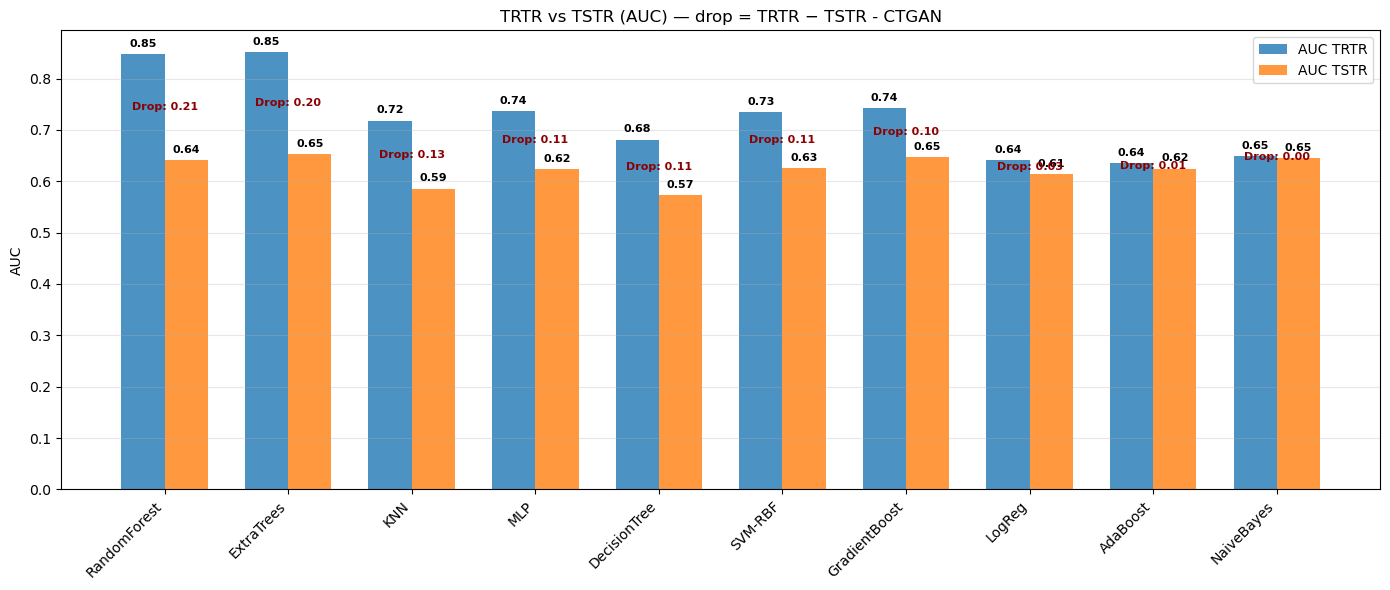

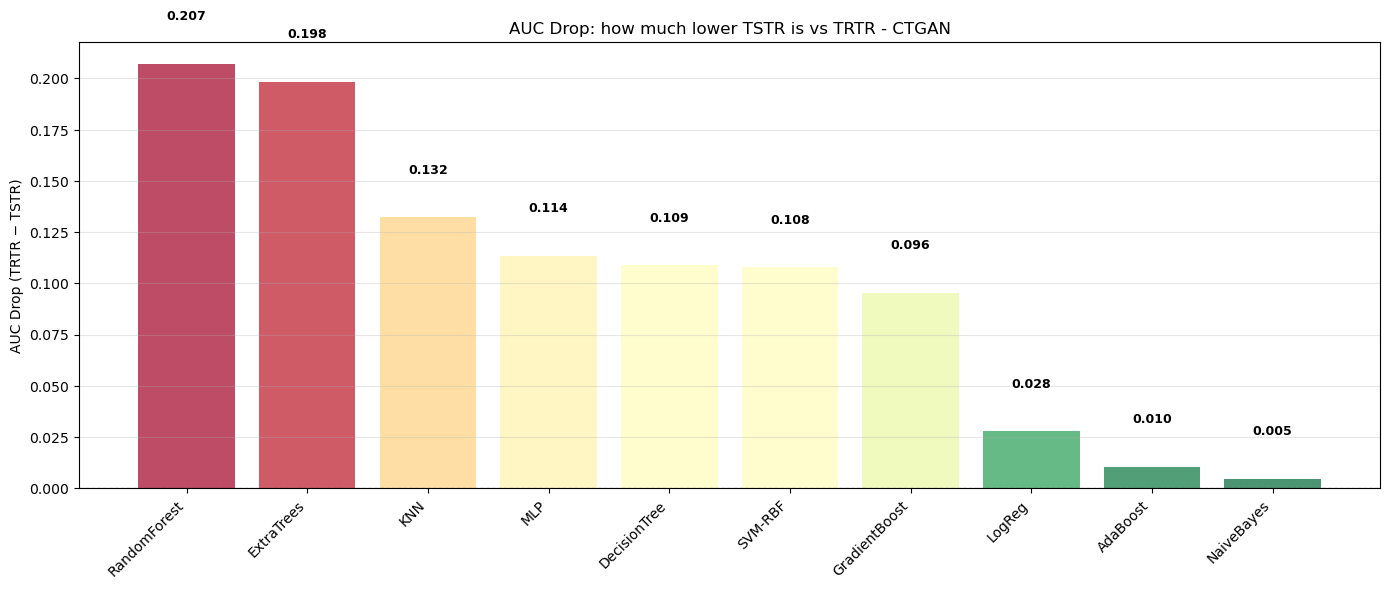

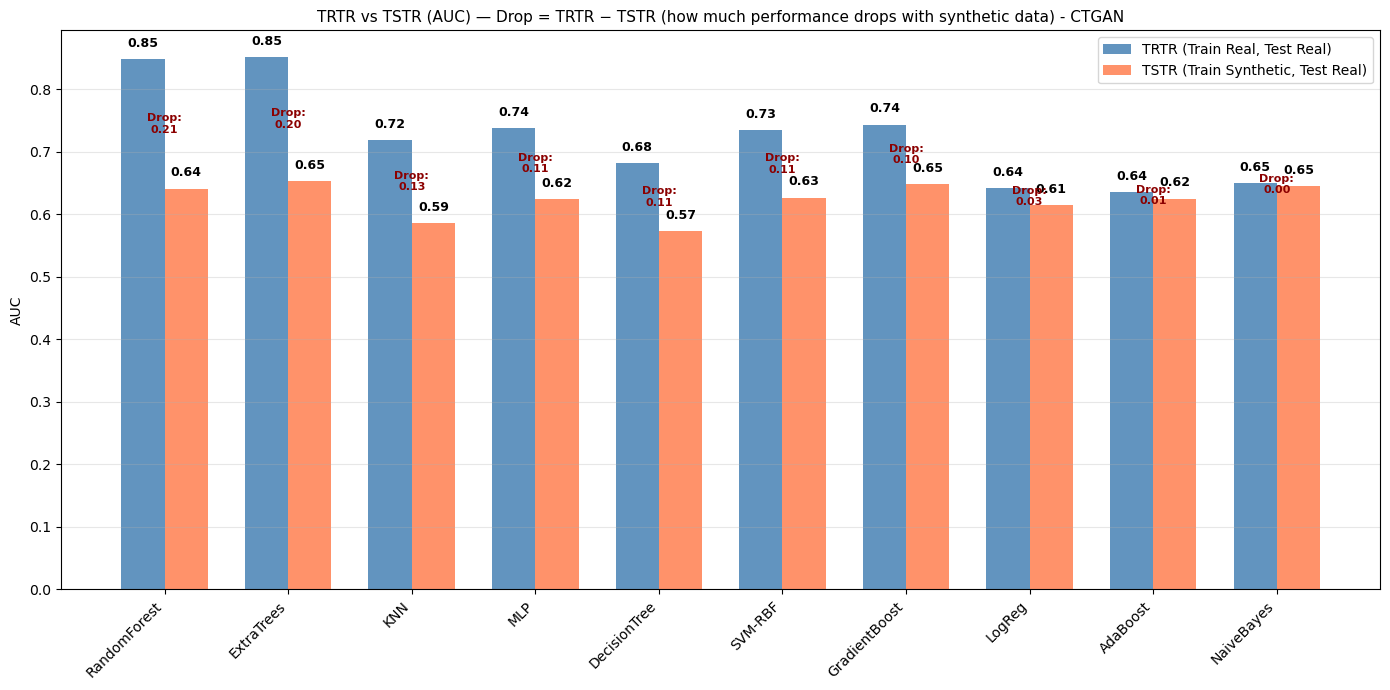

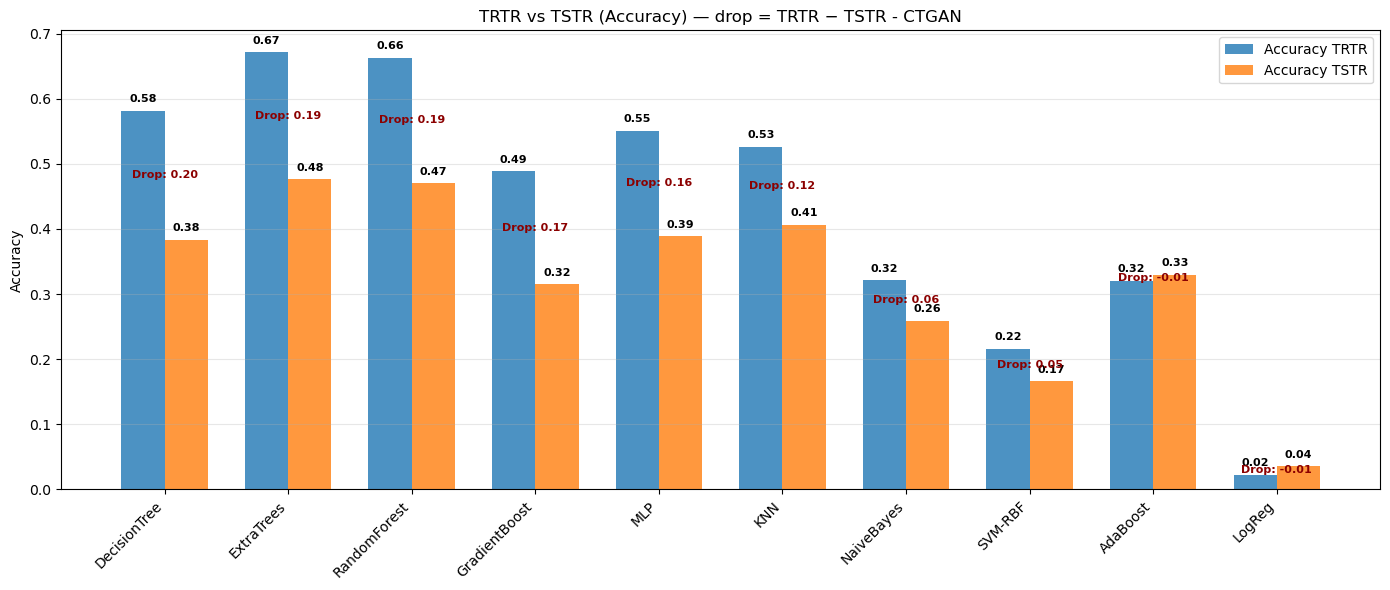

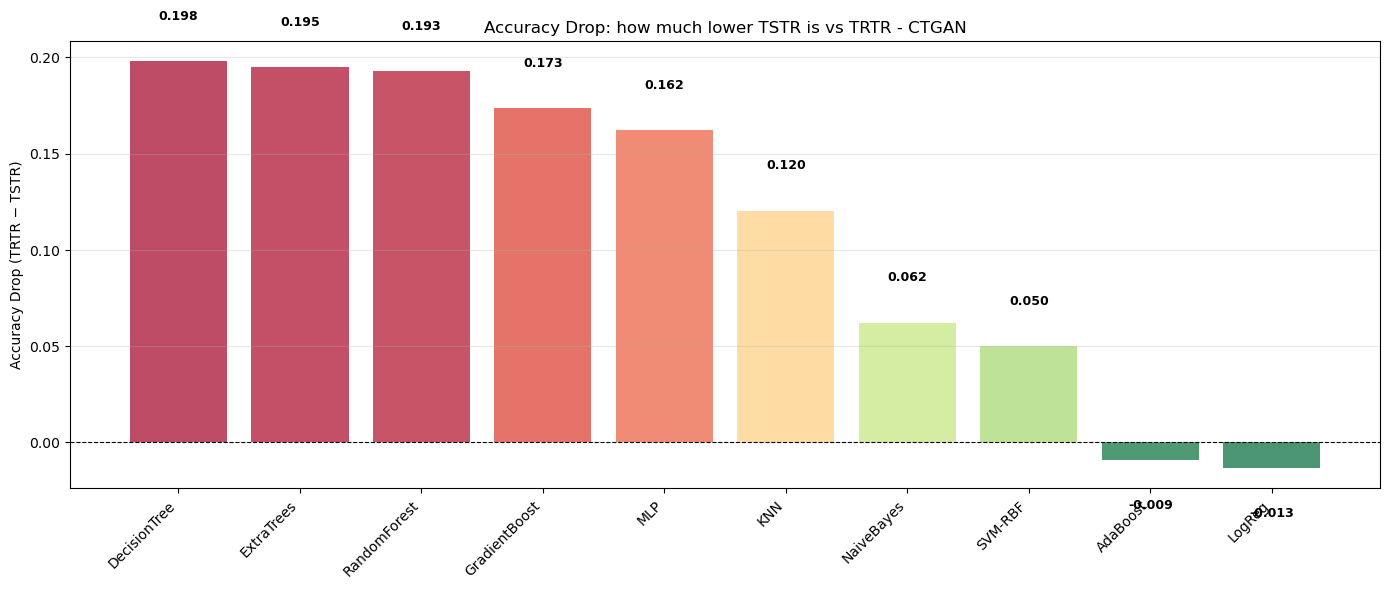

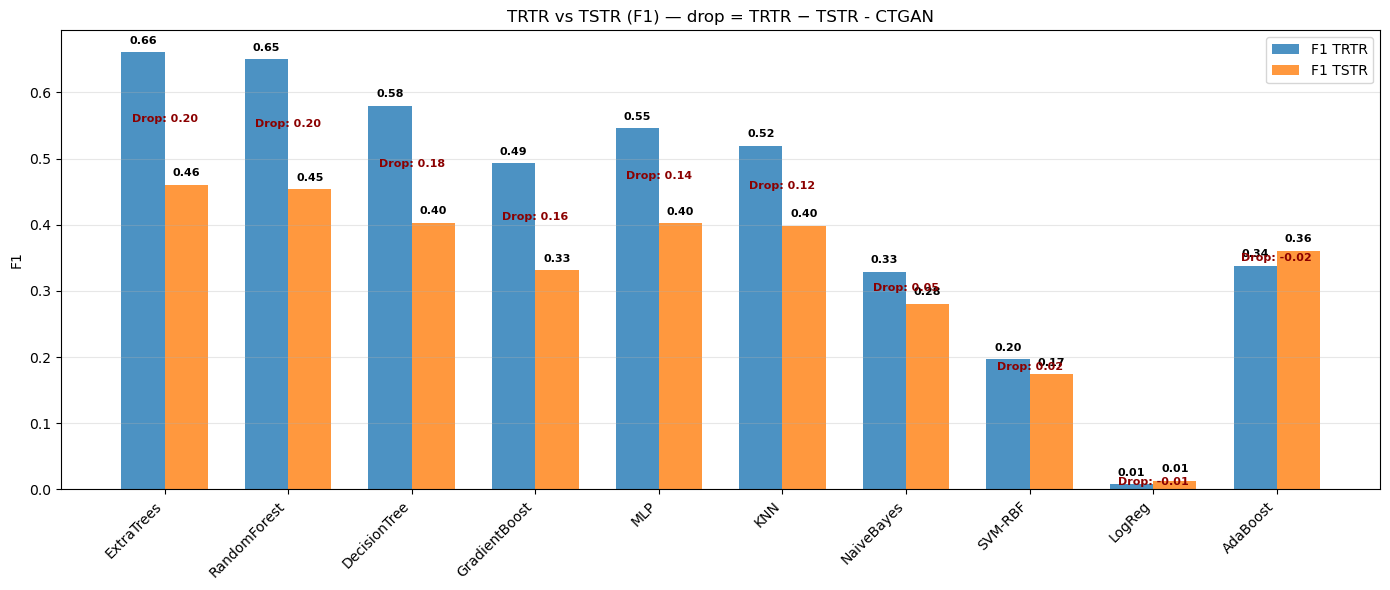

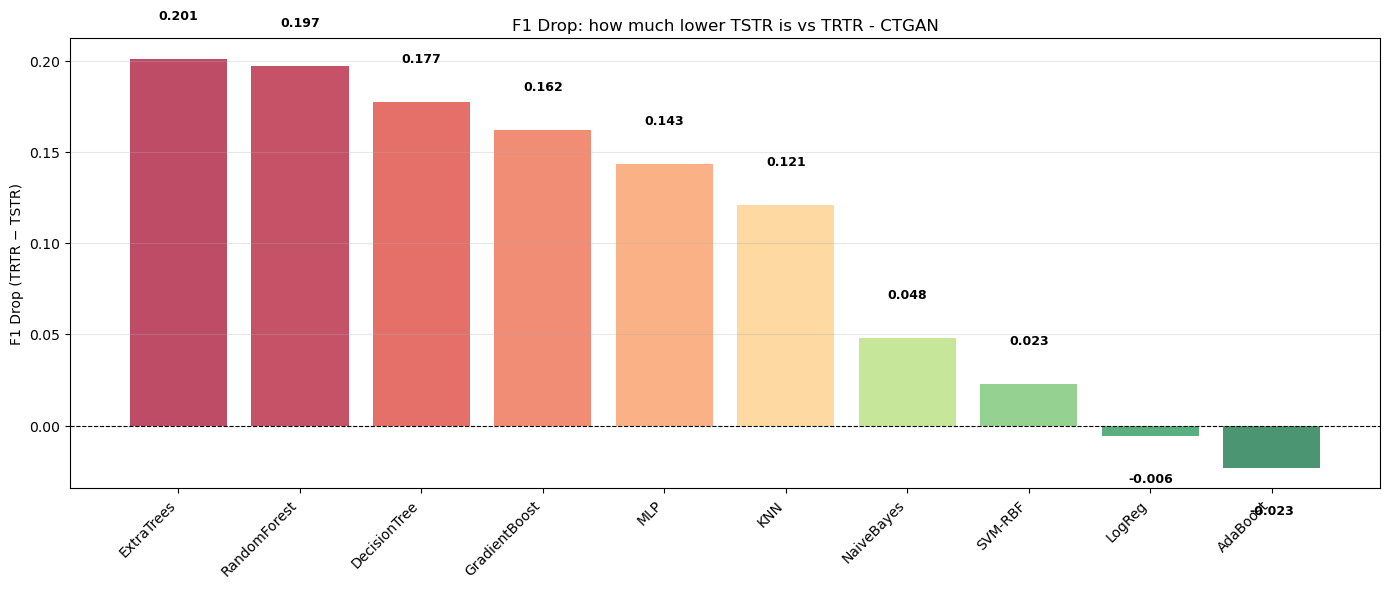

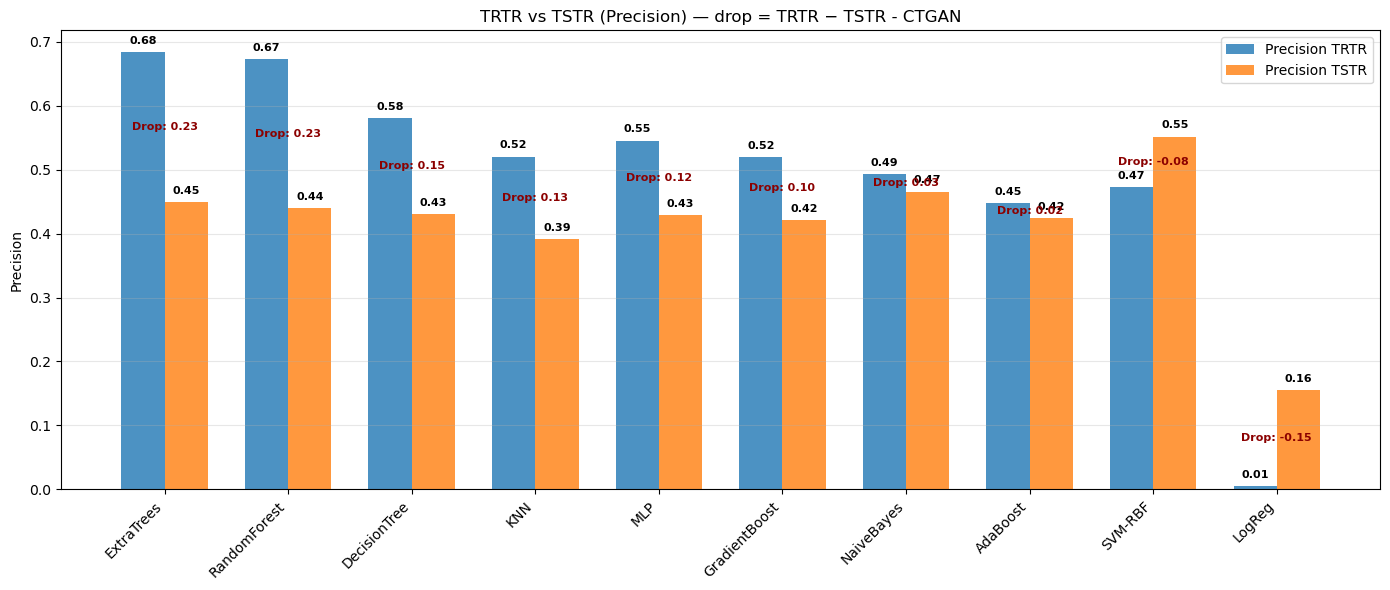

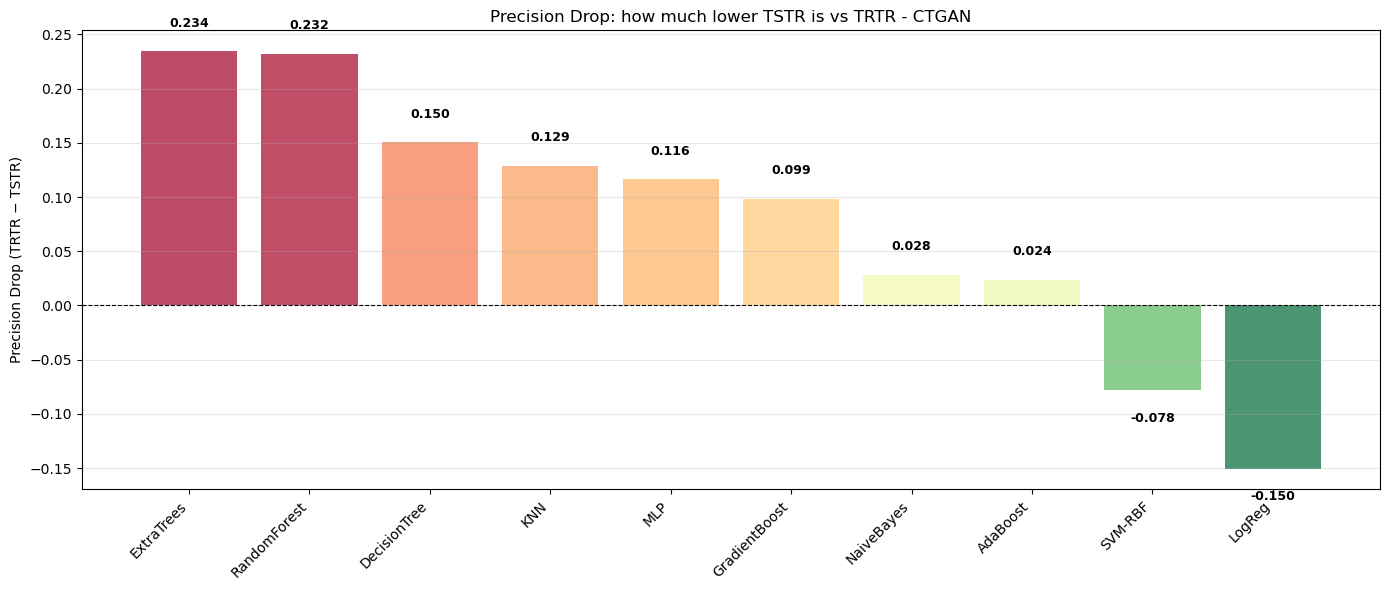

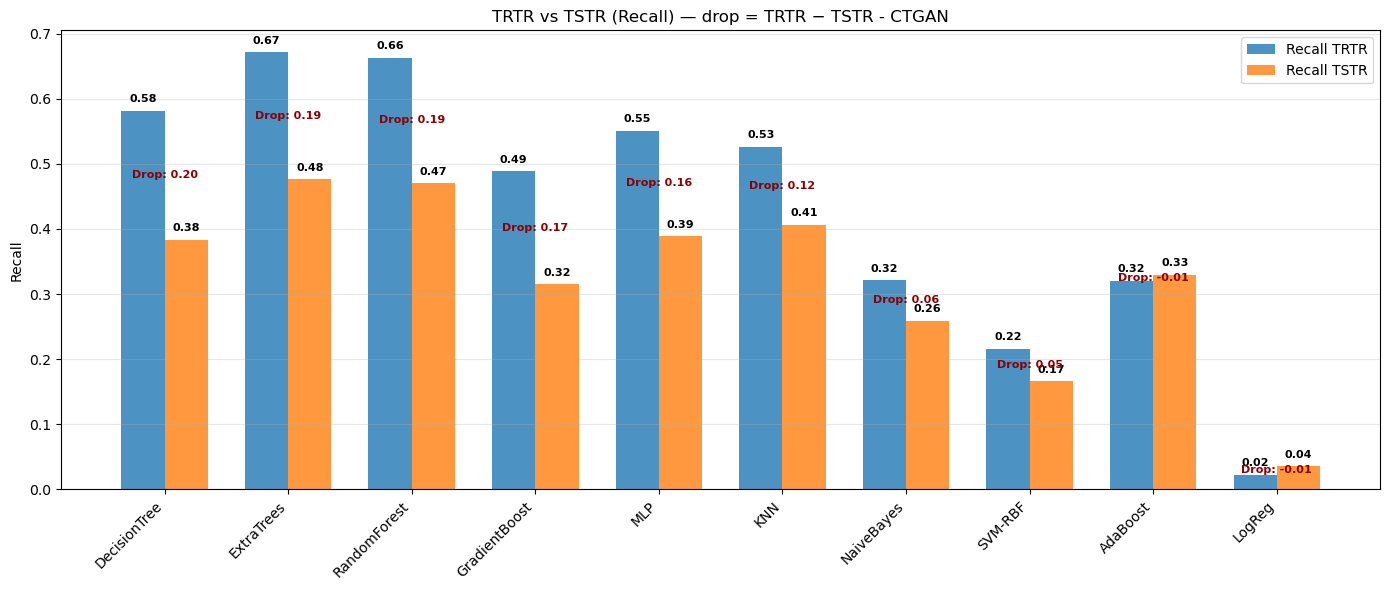

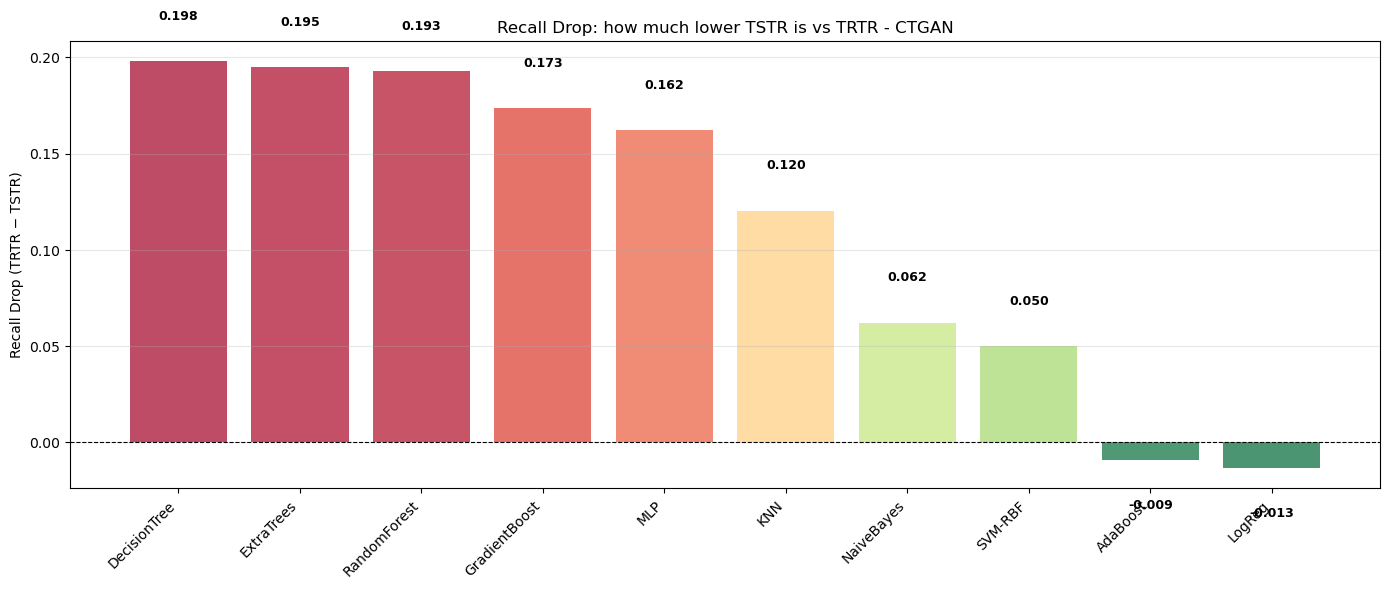

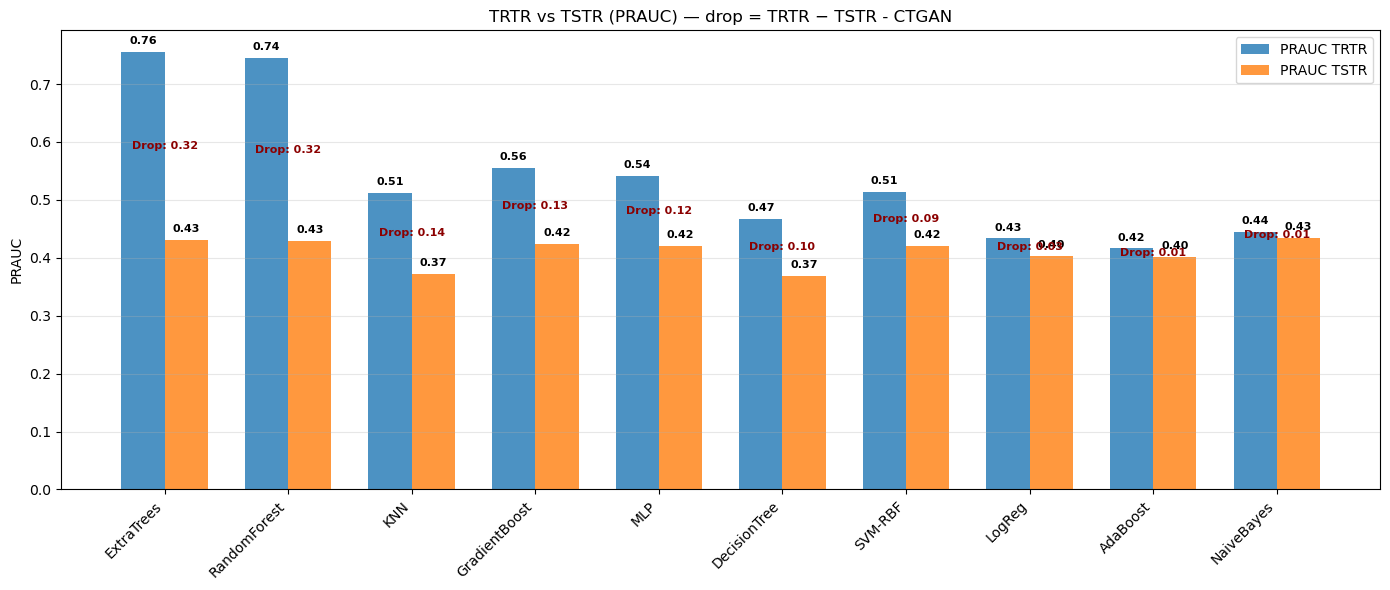

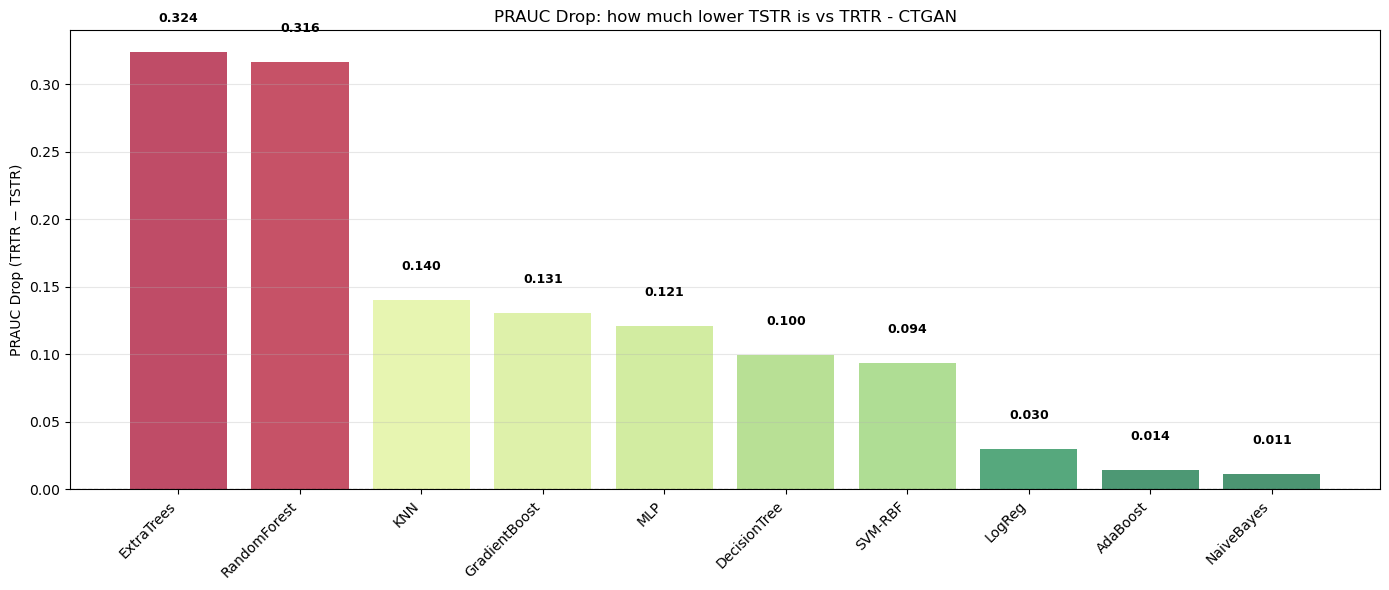


Delta metrics (TRTR − TSTR) — CTGAN


,Model,AUC_Drop,F1_Drop,Accuracy_Drop,Precision_Drop,Recall_Drop,PRAUC_Drop
6,ExtraTrees,0.1985,0.2009,0.1949,0.2345,0.1949,0.3237
5,RandomForest,0.2072,0.1968,0.1929,0.2321,0.1929,0.3164
7,GradientBoost,0.0956,0.1622,0.1735,0.0985,0.1735,0.1308
9,MLP,0.1136,0.1435,0.1622,0.1162,0.1622,0.1209
1,SVM-RBF,0.1079,0.0229,0.0500,-0.0783,0.0500,0.0937
2,KNN,0.1322,0.1209,0.1204,0.1288,0.1204,0.1401
4,DecisionTree,0.1088,0.1772,0.1980,0.1503,0.1980,0.0996
3,NaiveBayes,0.0047,0.0481,0.0622,0.0281,0.0622,0.0111
0,LogReg,0.0278,-0.0055,-0.0133,-0.1504,-0.0133,0.0298
8,AdaBoost,0.0103,-0.0232,-0.0092,0.0236,-0.0092,0.0141



Comparison Graphs for CopulaGAN


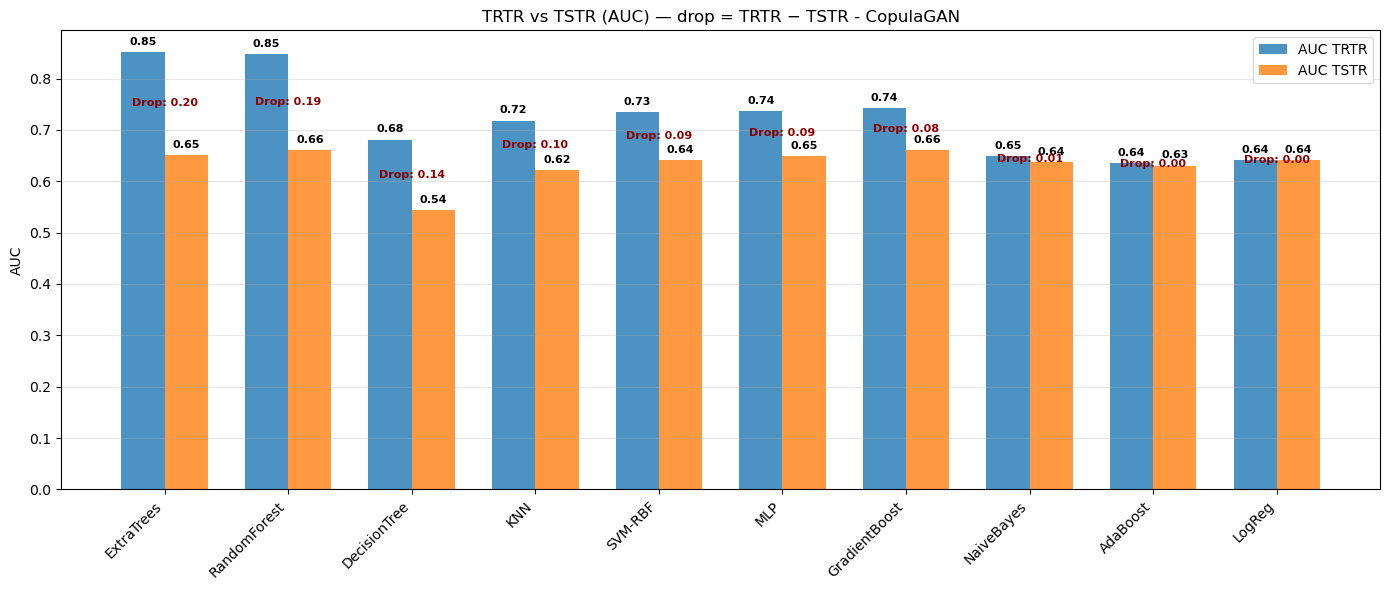

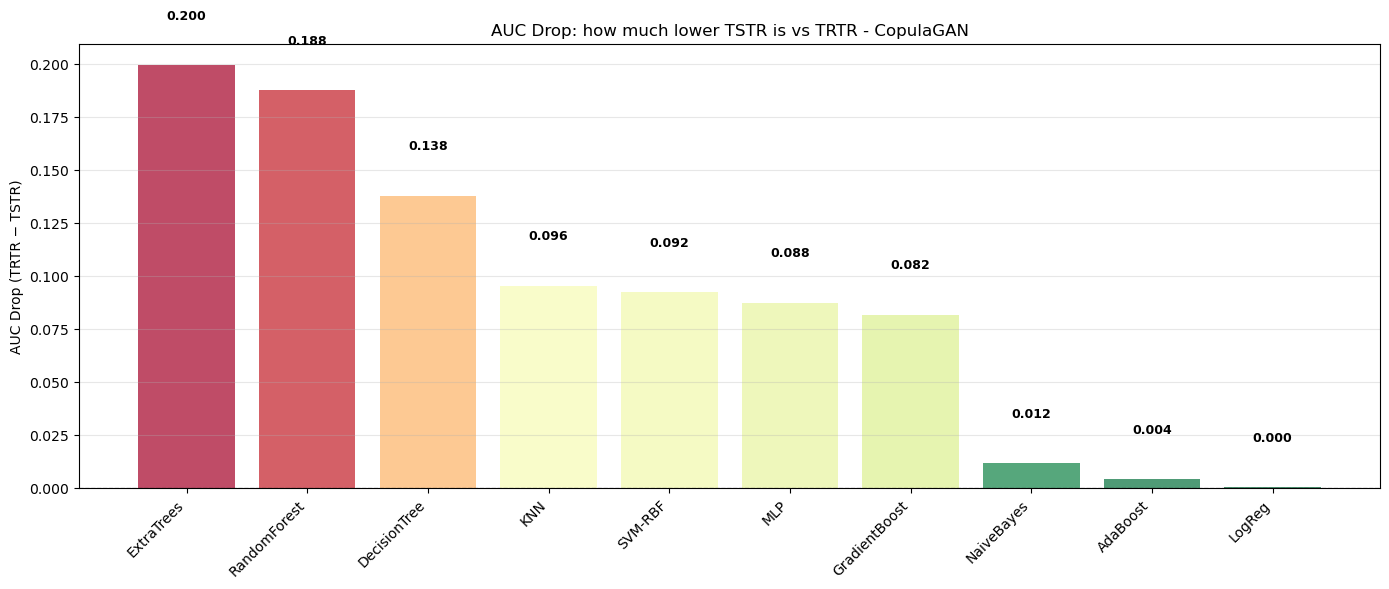

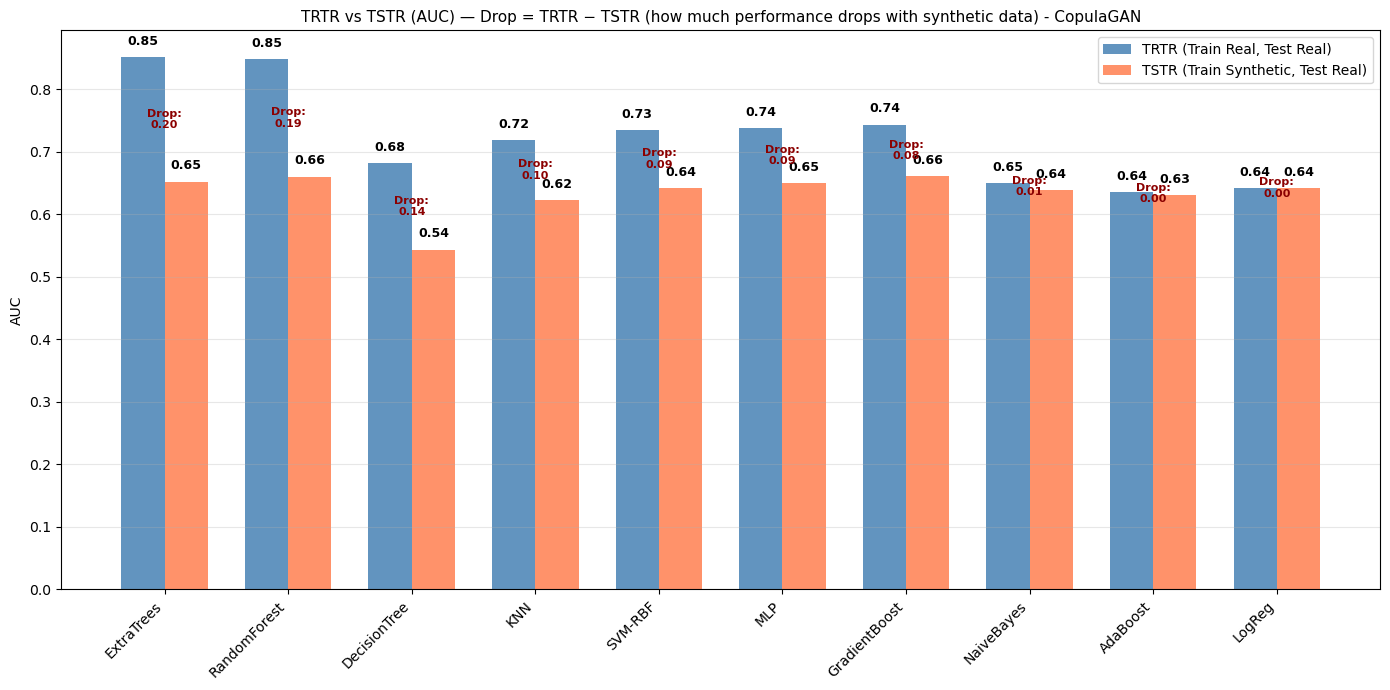

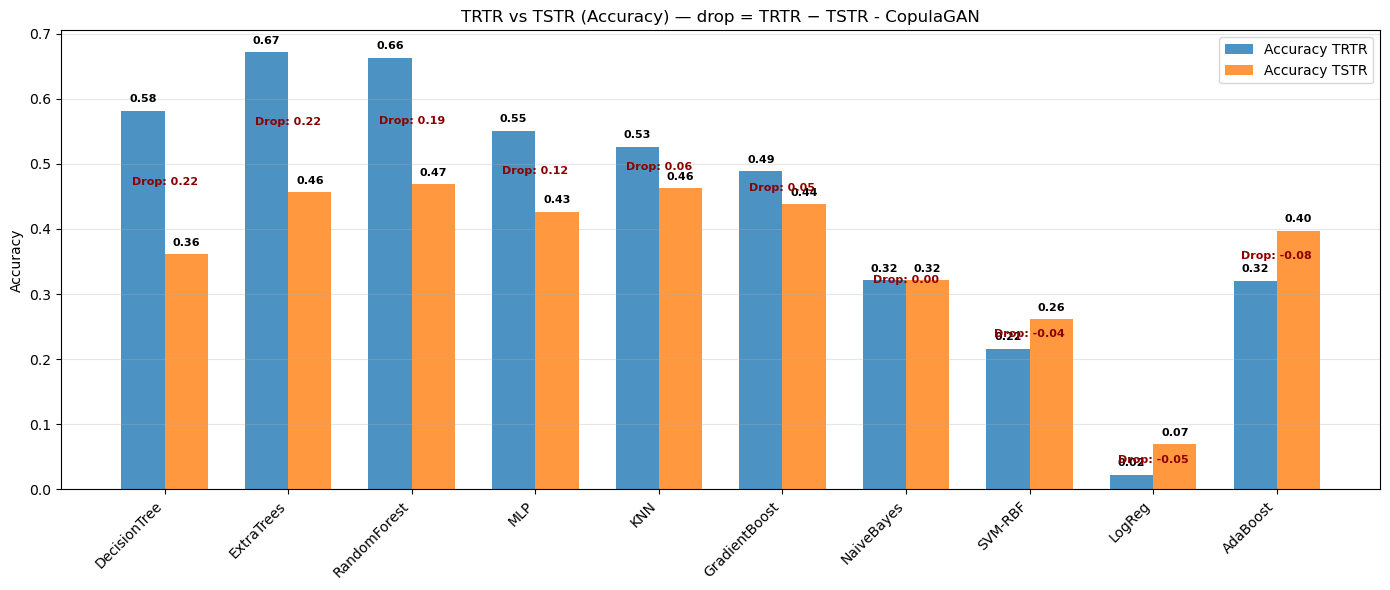

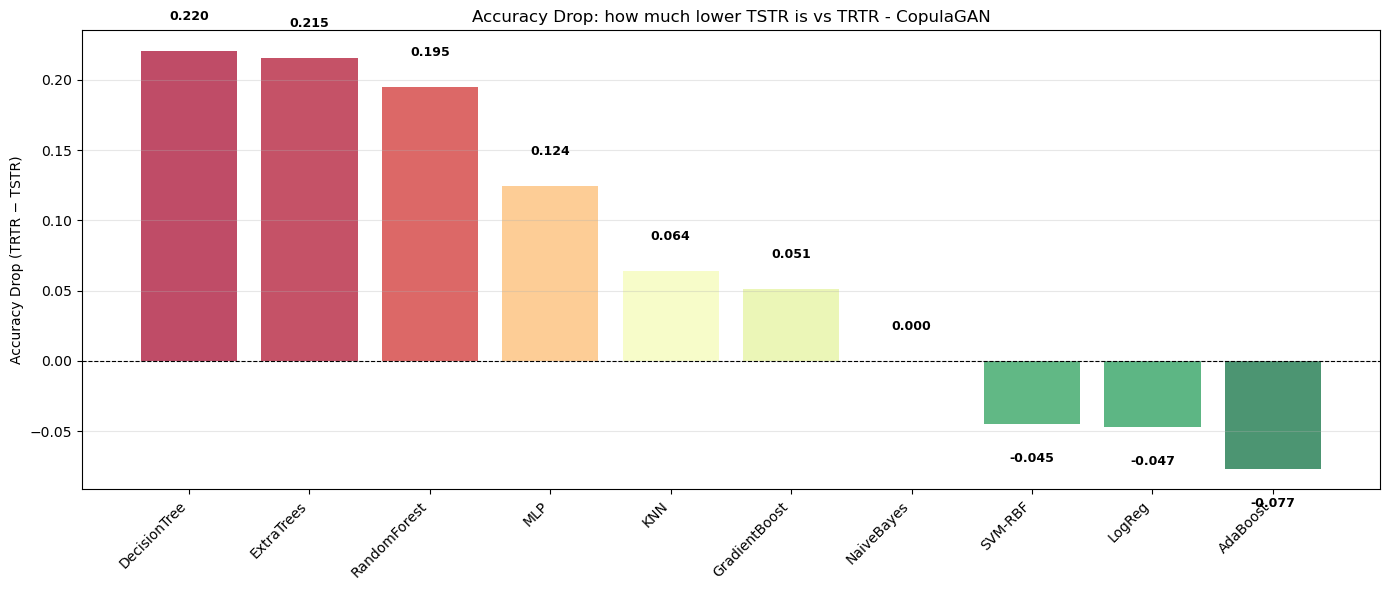

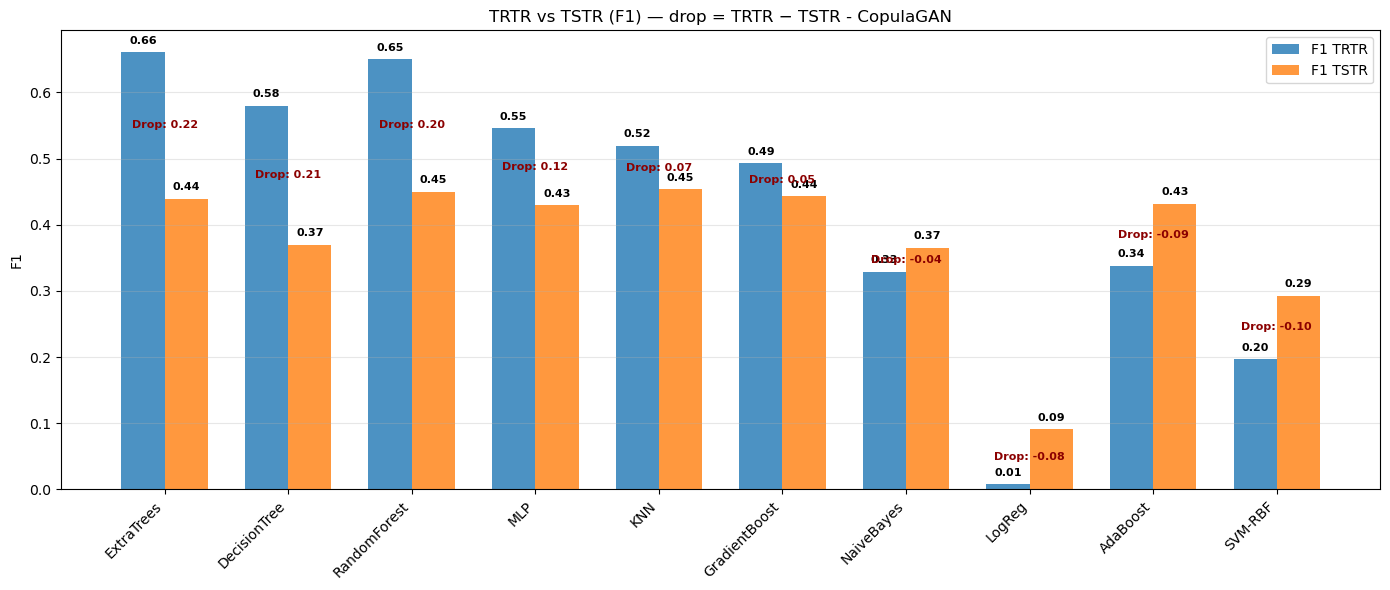

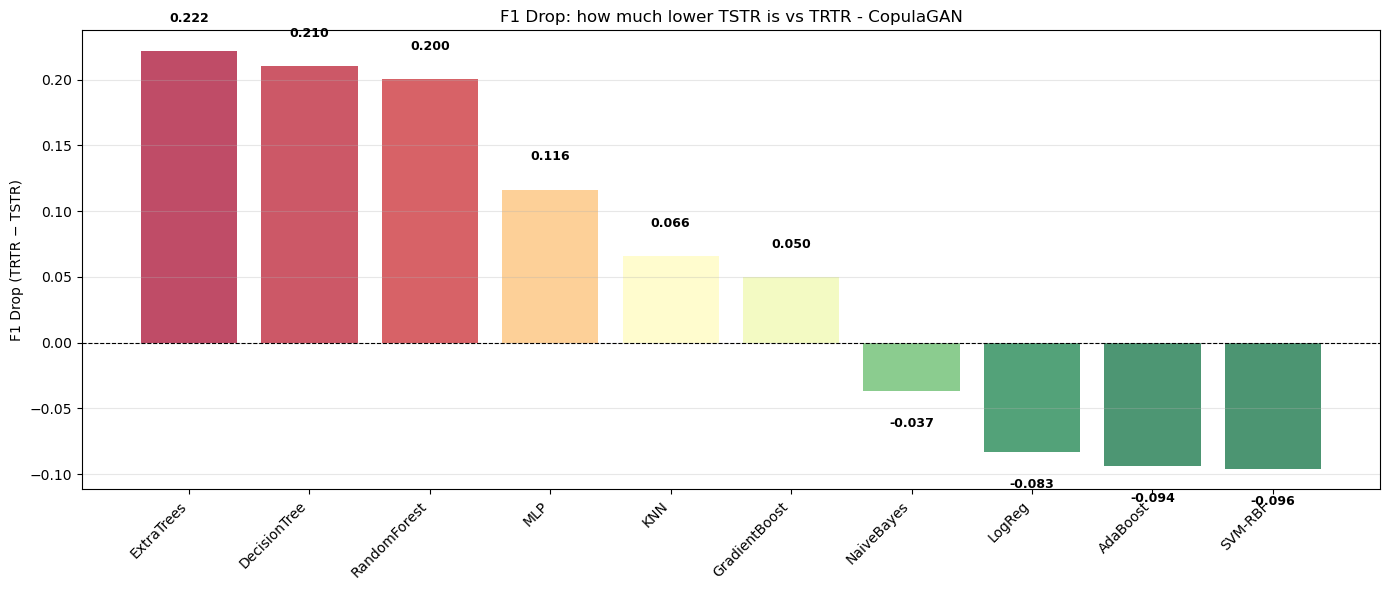

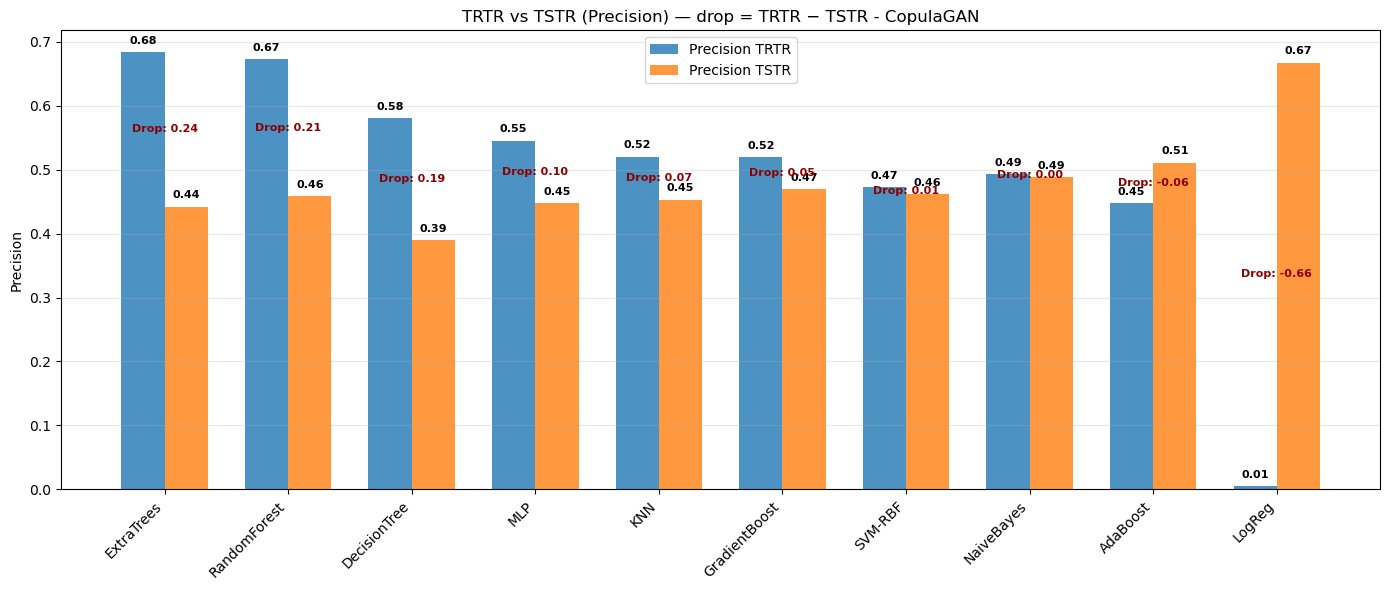

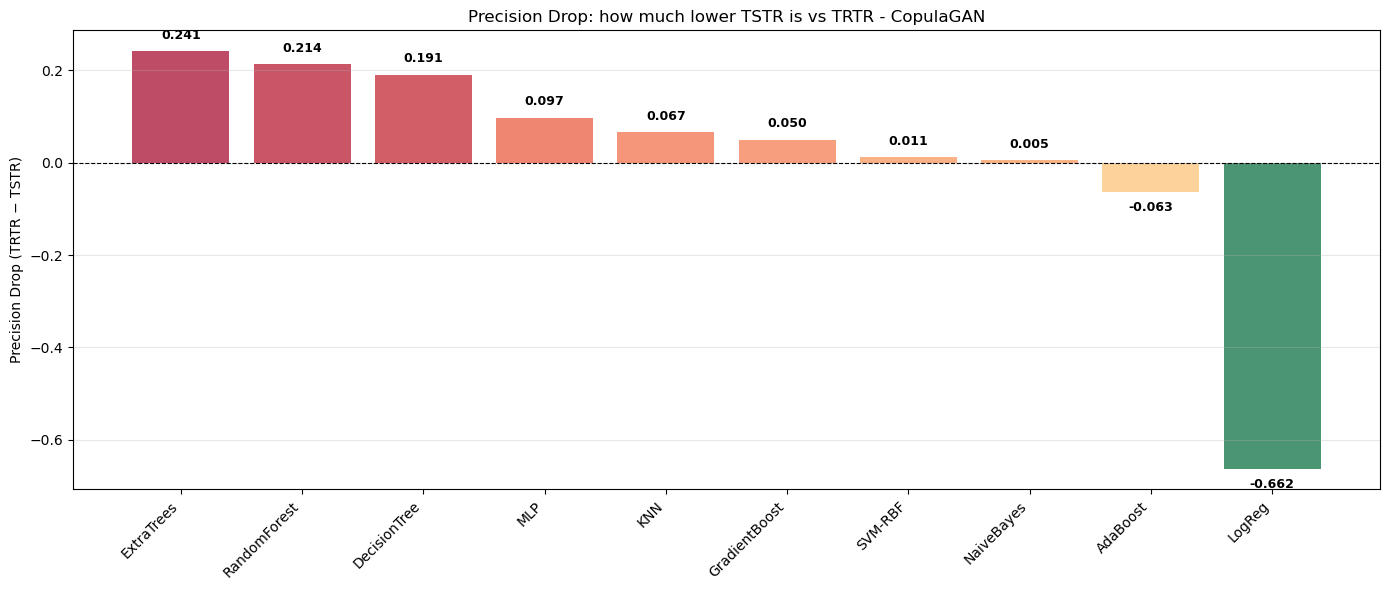

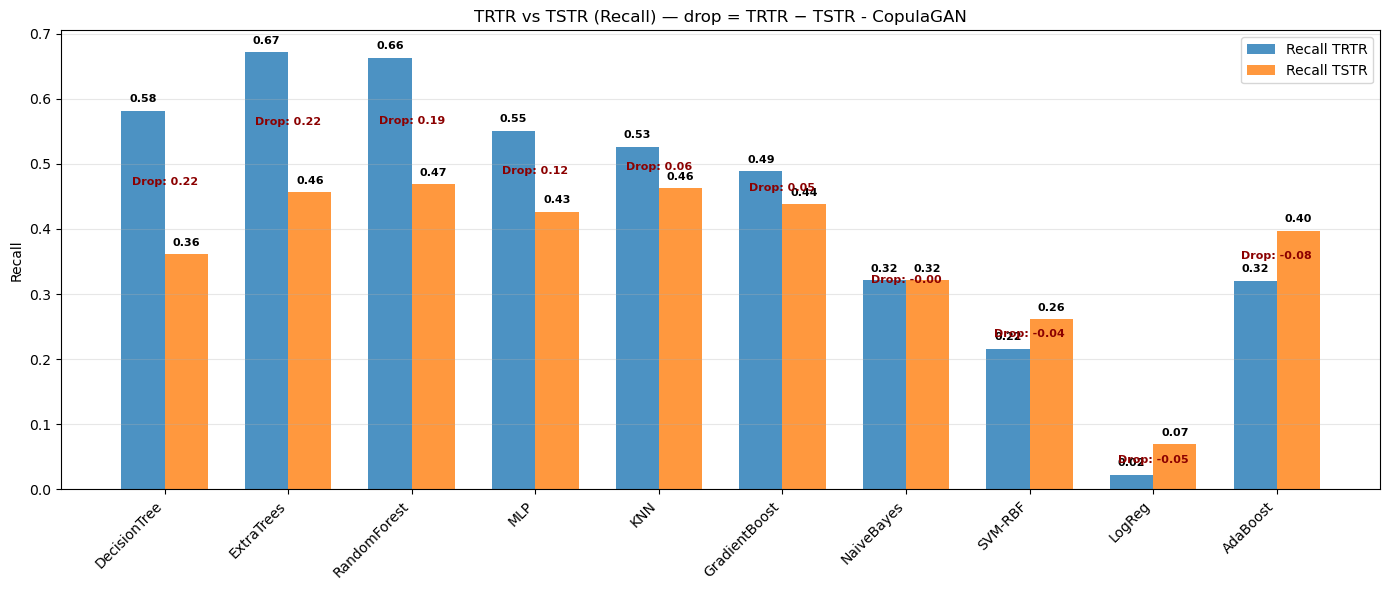

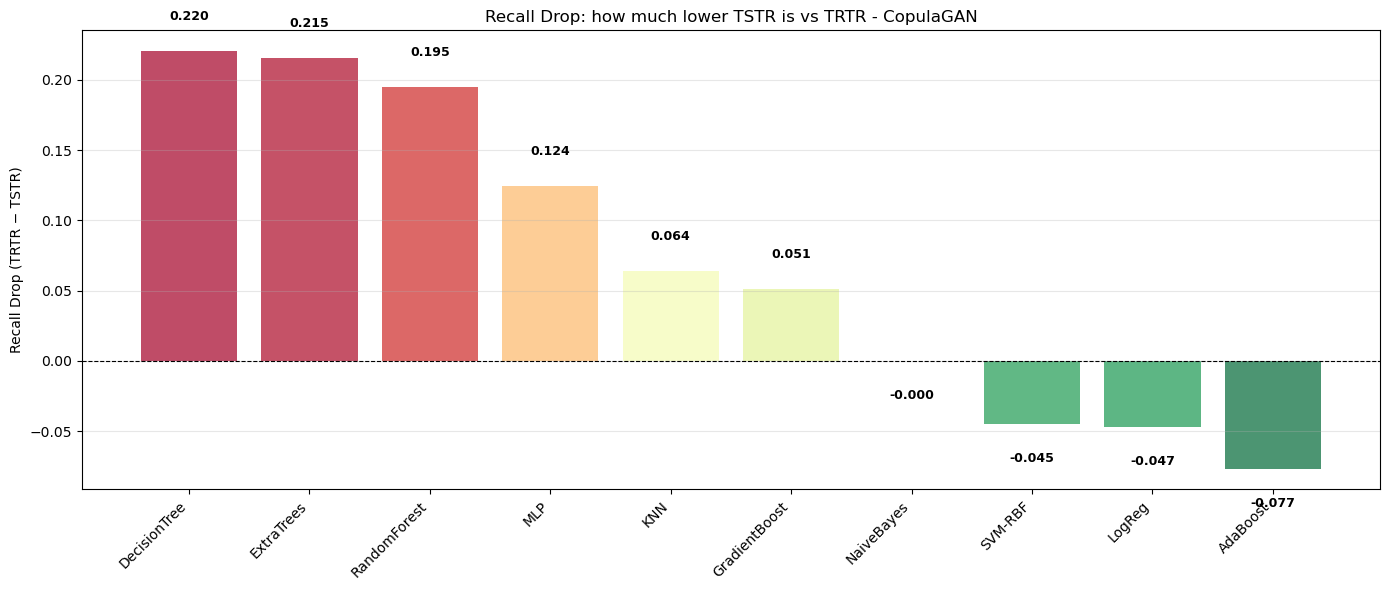

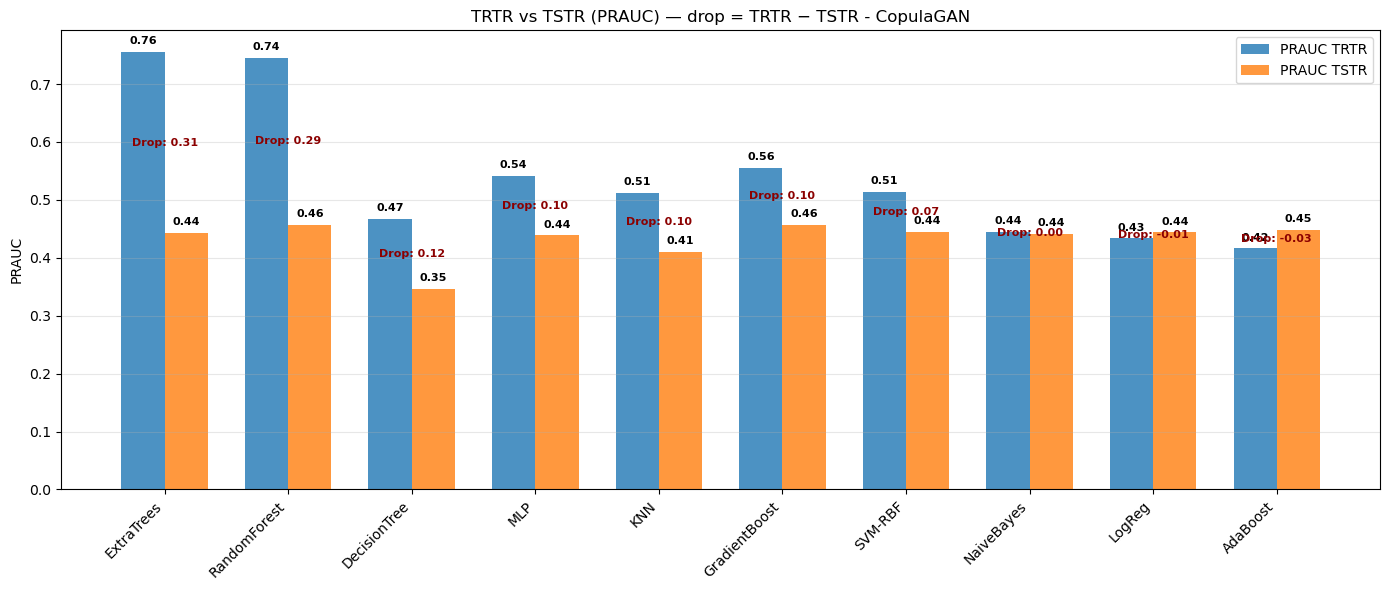

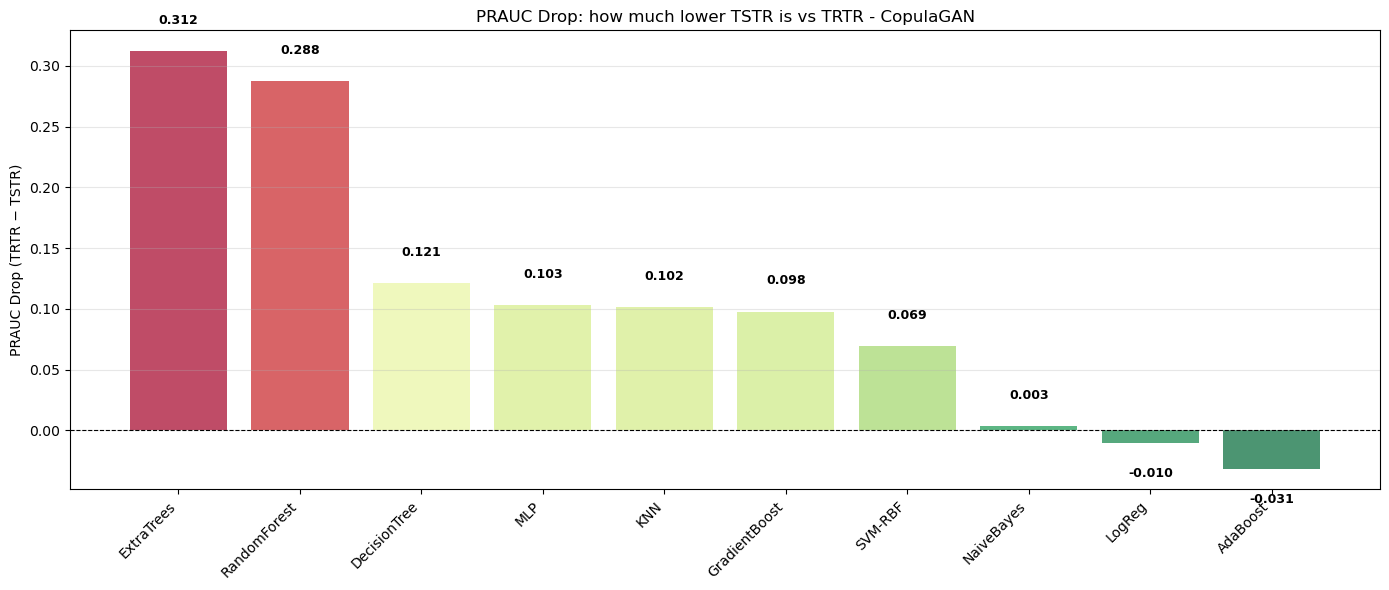


Delta metrics (TRTR − TSTR) — CopulaGAN


,Model,AUC_Drop,F1_Drop,Accuracy_Drop,Precision_Drop,Recall_Drop,PRAUC_Drop
6,ExtraTrees,0.1995,0.2216,0.2153,0.2413,0.2153,0.3122
5,RandomForest,0.1878,0.2002,0.1949,0.2135,0.1949,0.2876
7,GradientBoost,0.0819,0.0500,0.0510,0.0500,0.0510,0.0978
9,MLP,0.0876,0.1164,0.1245,0.0975,0.1245,0.1032
1,SVM-RBF,0.0924,-0.0957,-0.0449,0.0113,-0.0449,0.0694
2,KNN,0.0956,0.0657,0.0643,0.0667,0.0643,0.1016
4,DecisionTree,0.1381,0.2103,0.2204,0.1908,0.2204,0.1214
3,NaiveBayes,0.0118,-0.0367,0.0000,0.0048,-0.0000,0.0032
0,LogReg,0.0005,-0.0831,-0.0469,-0.6623,-0.0469,-0.0104
8,AdaBoost,0.0045,-0.0939,-0.0765,-0.0635,-0.0765,-0.0315



Comparison Graphs for TVAE


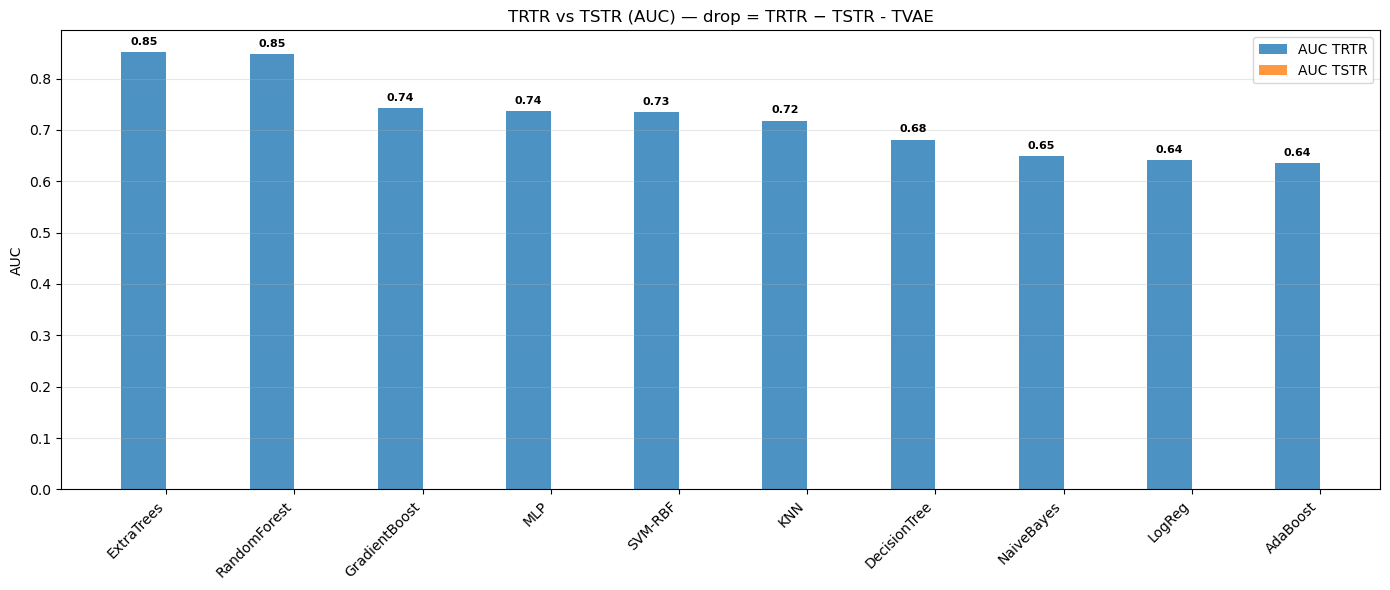

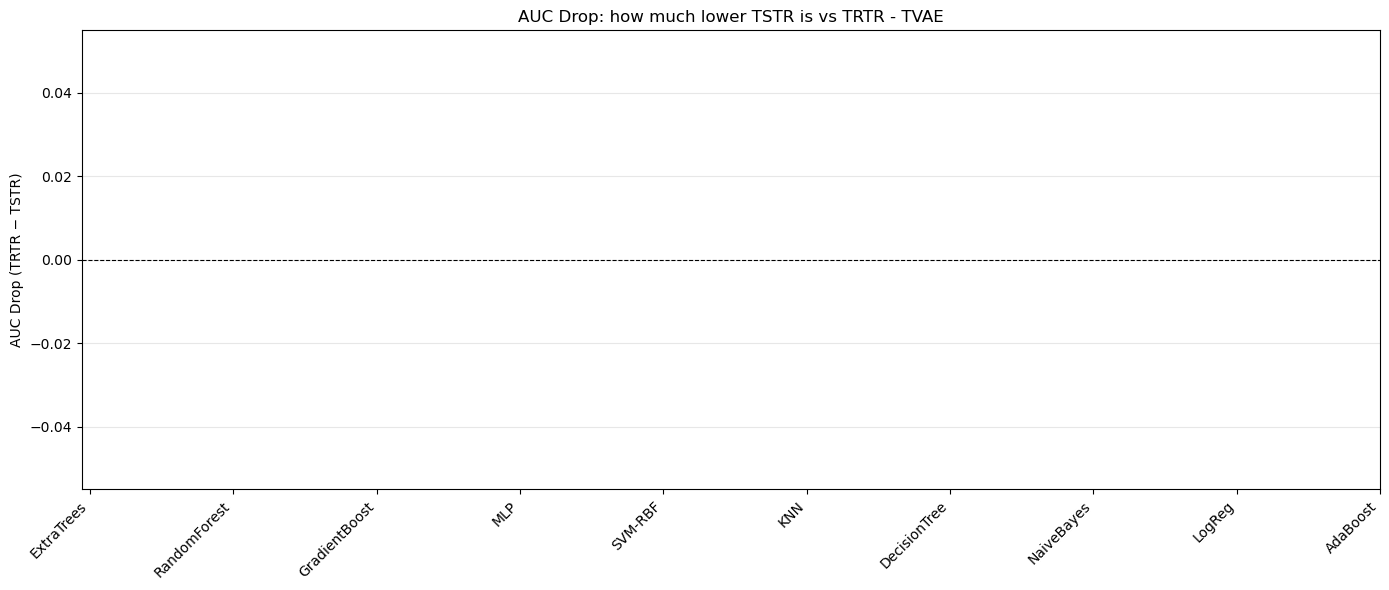

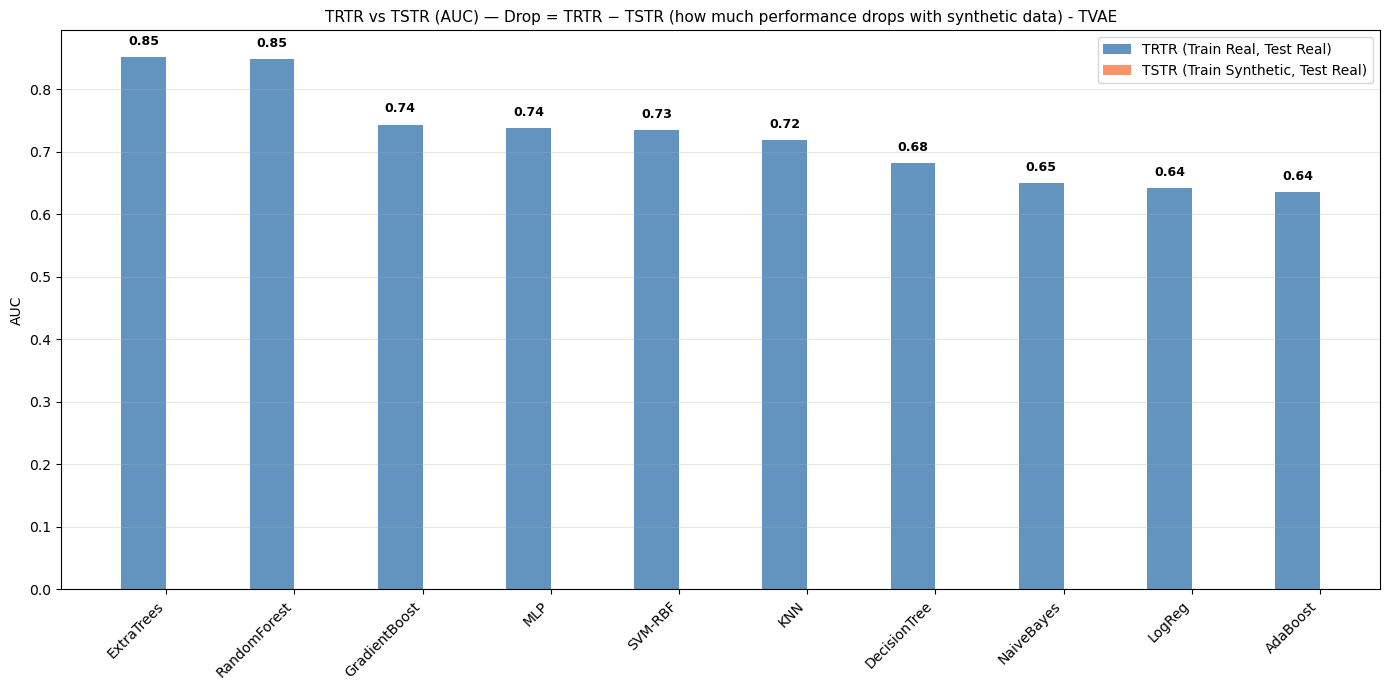

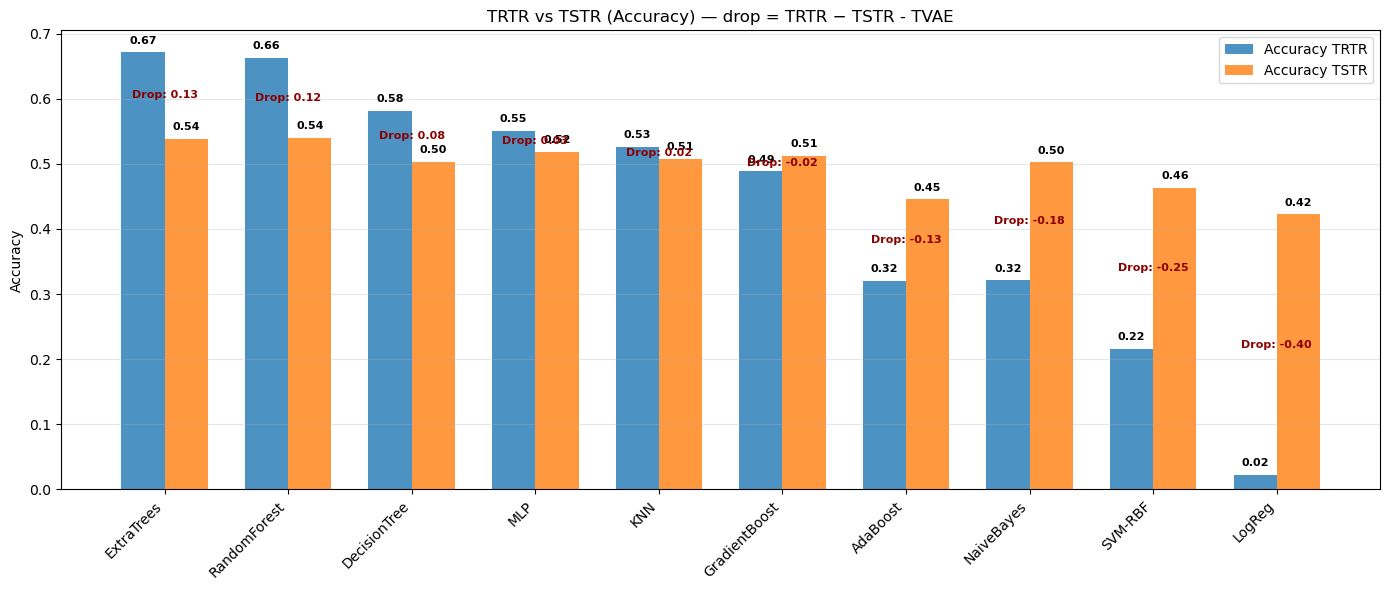

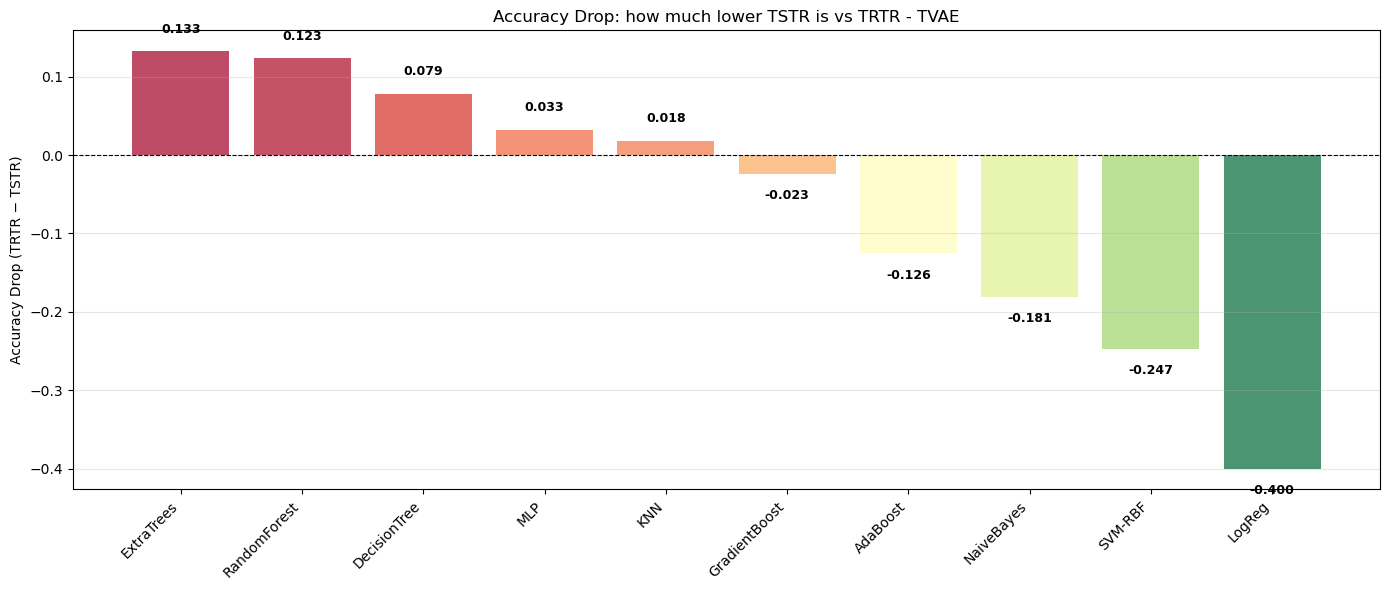

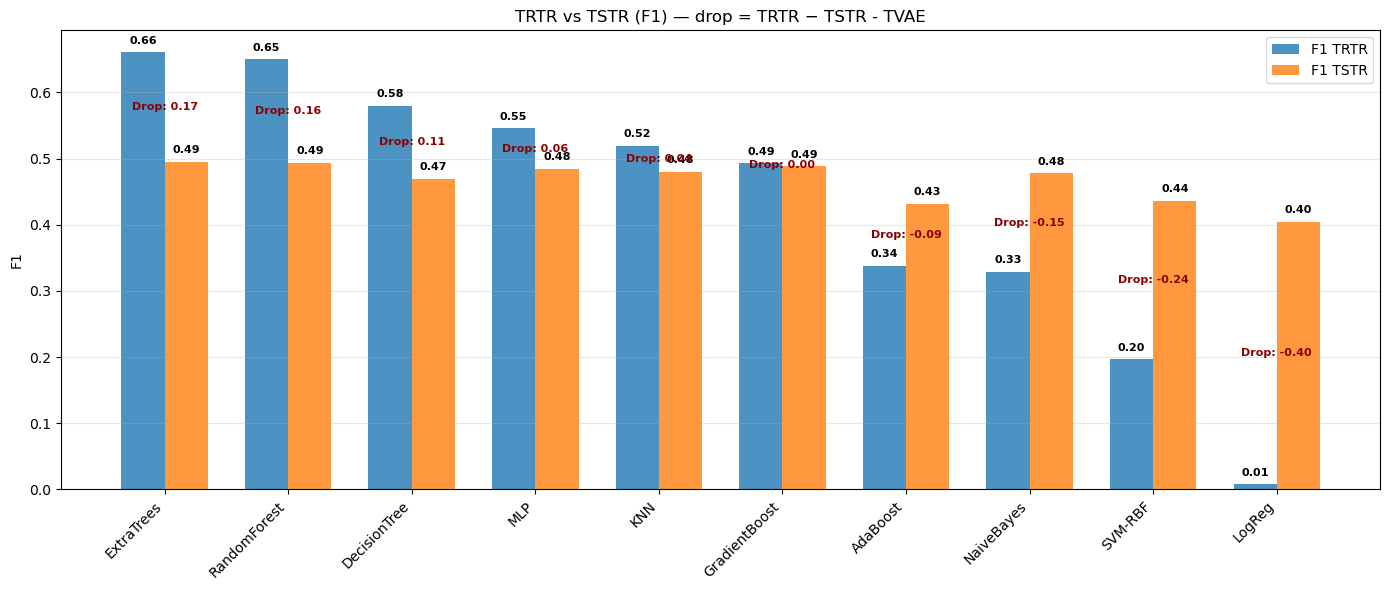

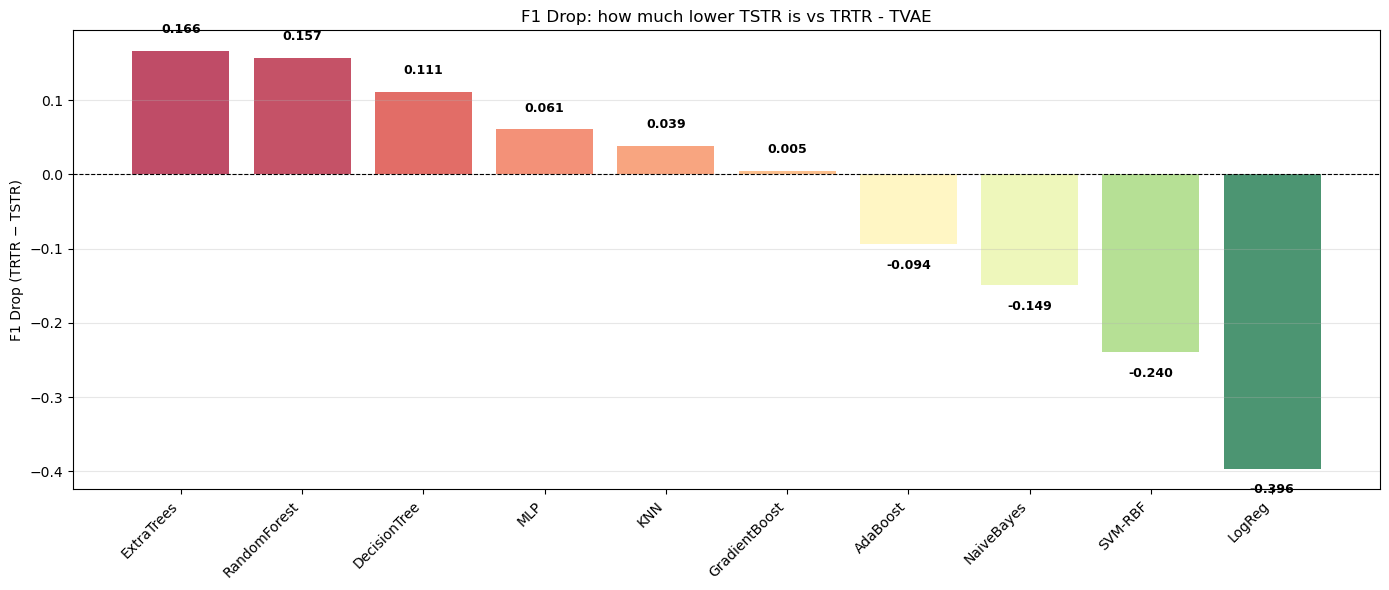

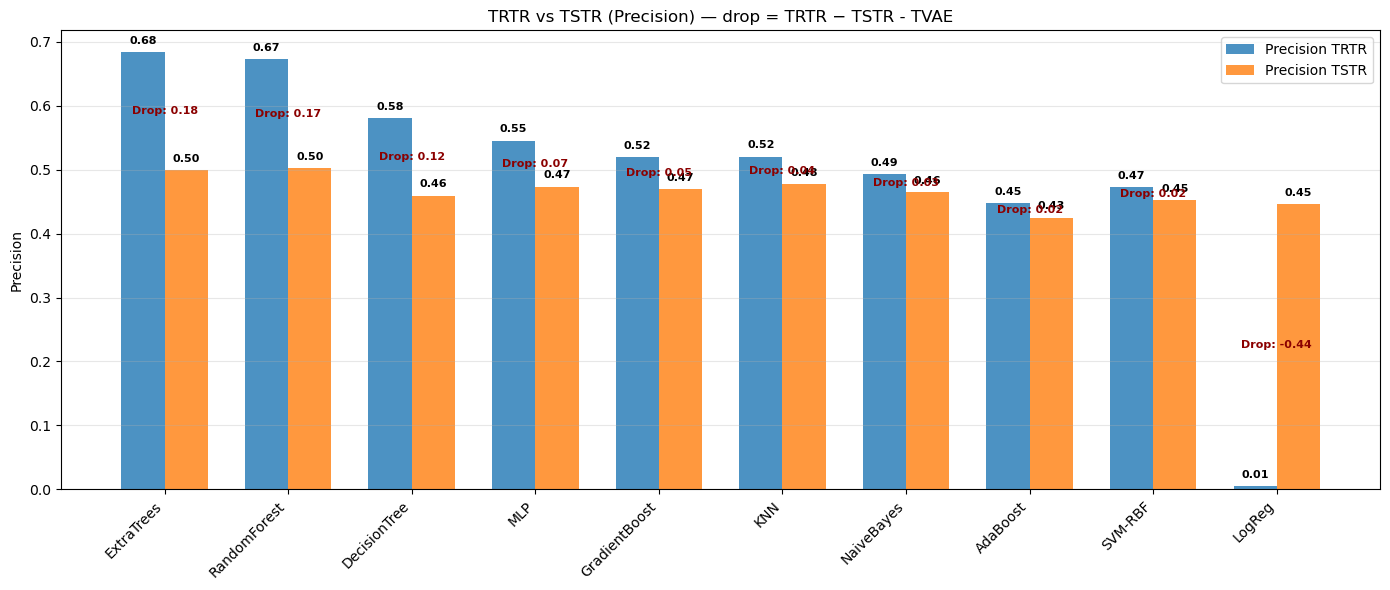

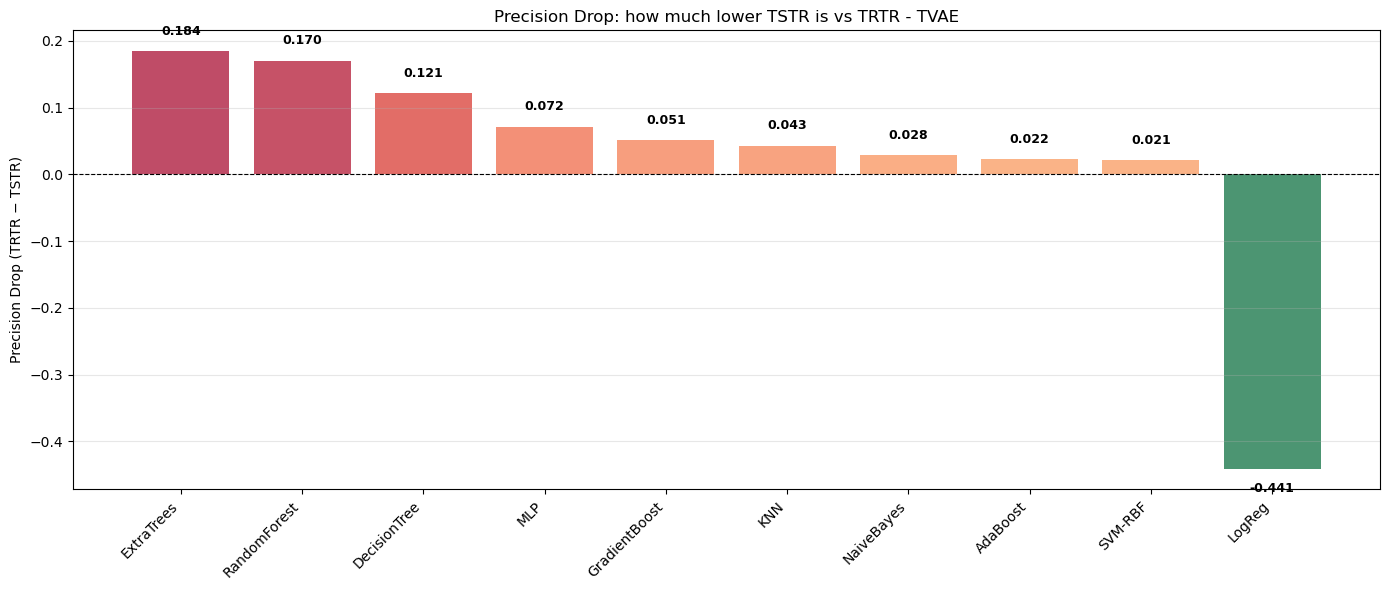

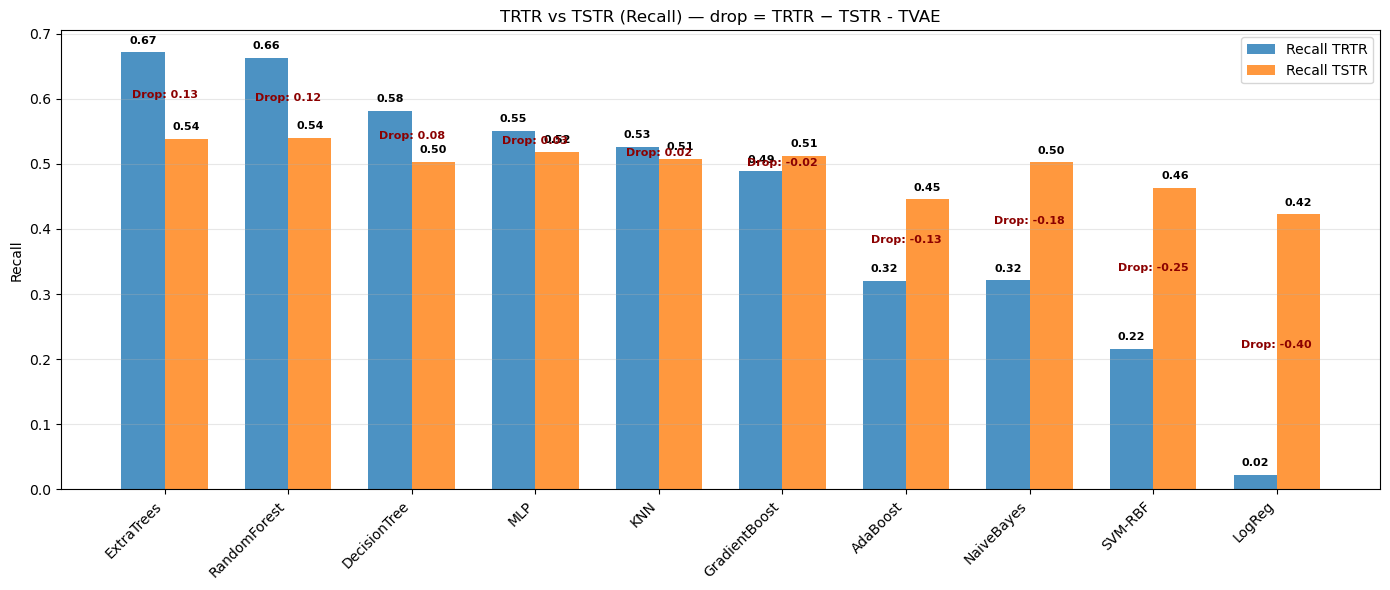

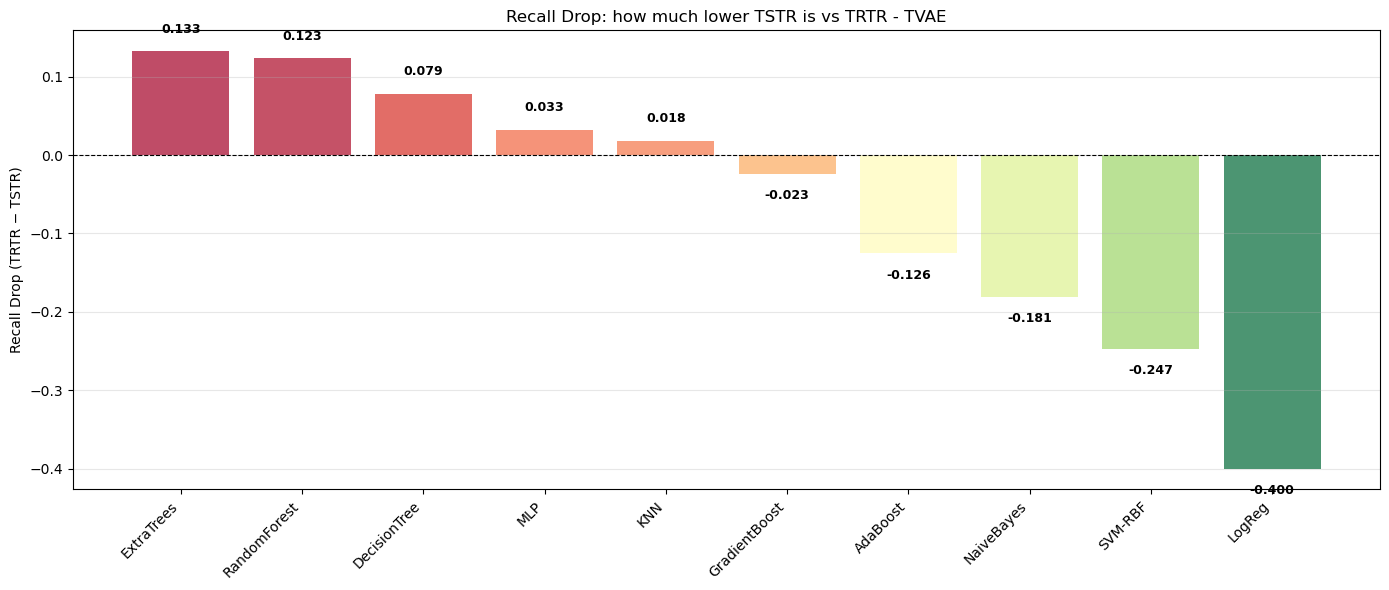

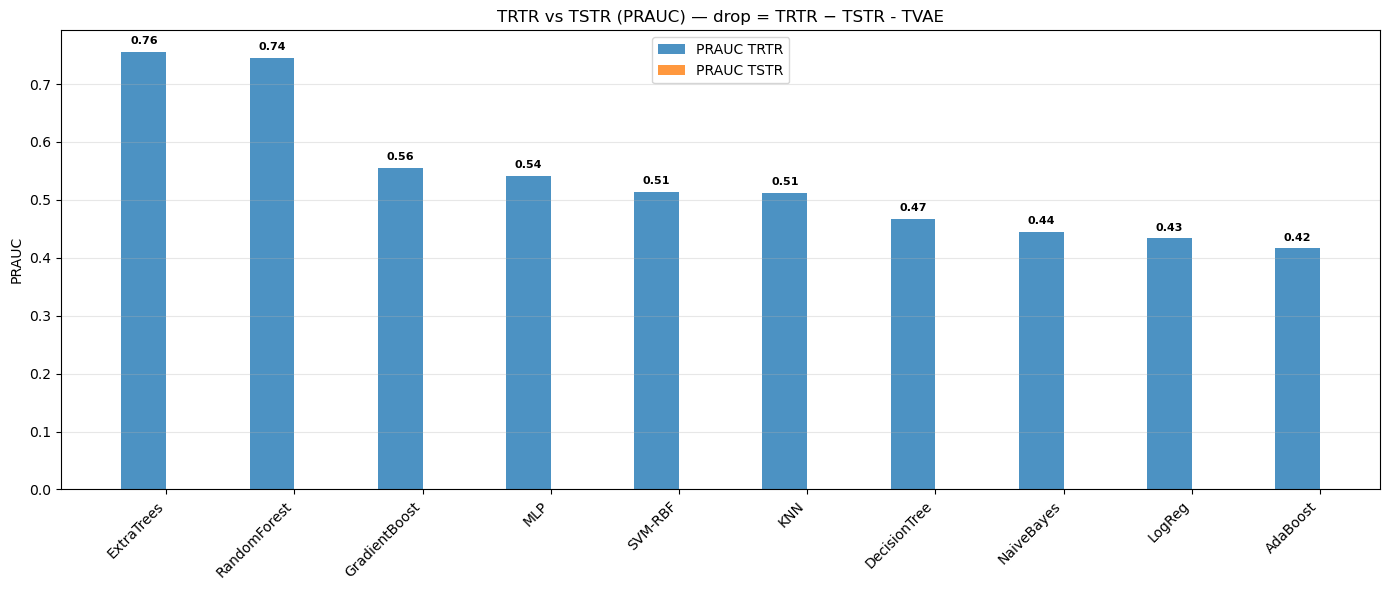

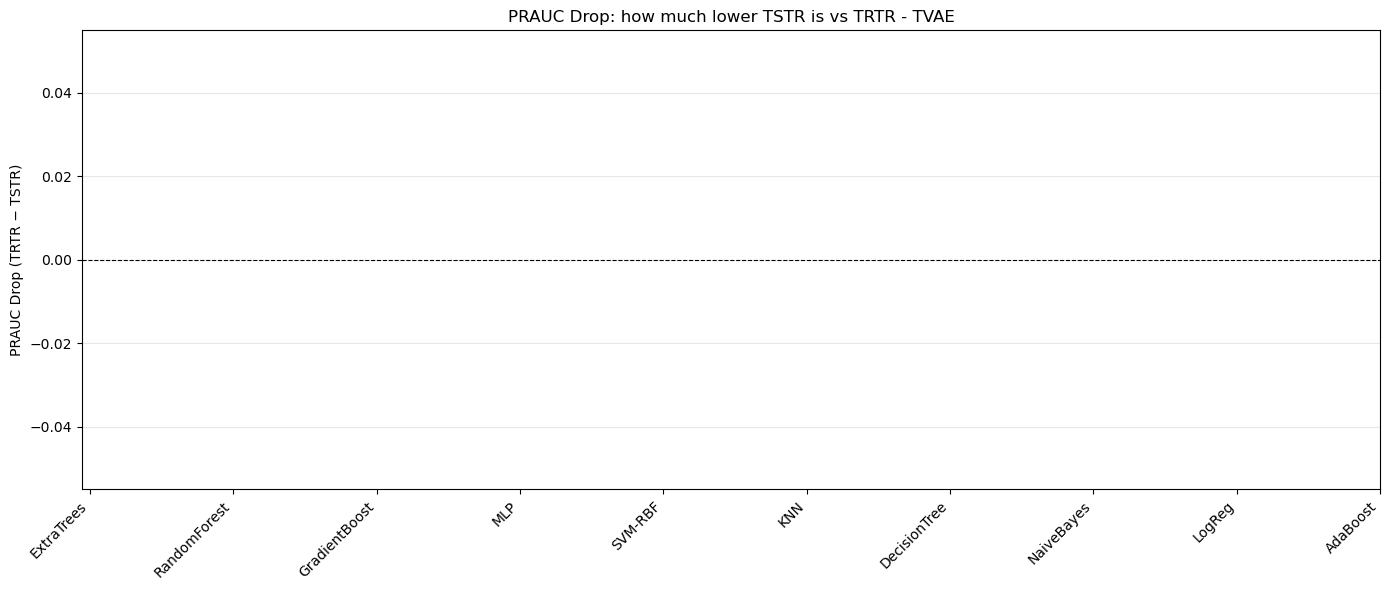


Delta metrics (TRTR − TSTR) — TVAE


,Model,AUC_Drop,F1_Drop,Accuracy_Drop,Precision_Drop,Recall_Drop,PRAUC_Drop
6,ExtraTrees,NaN,0.1661,0.1327,0.1845,0.1327,NaN
5,RandomForest,NaN,0.1570,0.1235,0.1702,0.1235,NaN
7,GradientBoost,NaN,0.0048,-0.0235,0.0507,-0.0235,NaN
9,MLP,NaN,0.0607,0.0327,0.0716,0.0327,NaN
1,SVM-RBF,NaN,-0.2396,-0.2469,0.0210,-0.2469,NaN
2,KNN,NaN,0.0387,0.0184,0.0428,0.0184,NaN
4,DecisionTree,NaN,0.1107,0.0786,0.1213,0.0786,NaN
3,NaiveBayes,NaN,-0.1492,-0.1806,0.0284,-0.1806,NaN
0,LogReg,NaN,-0.3961,-0.4000,-0.4409,-0.4000,NaN
8,AdaBoost,NaN,-0.0936,-0.1255,0.0225,-0.1255,NaN



Comparison Graphs for GaussianCopula


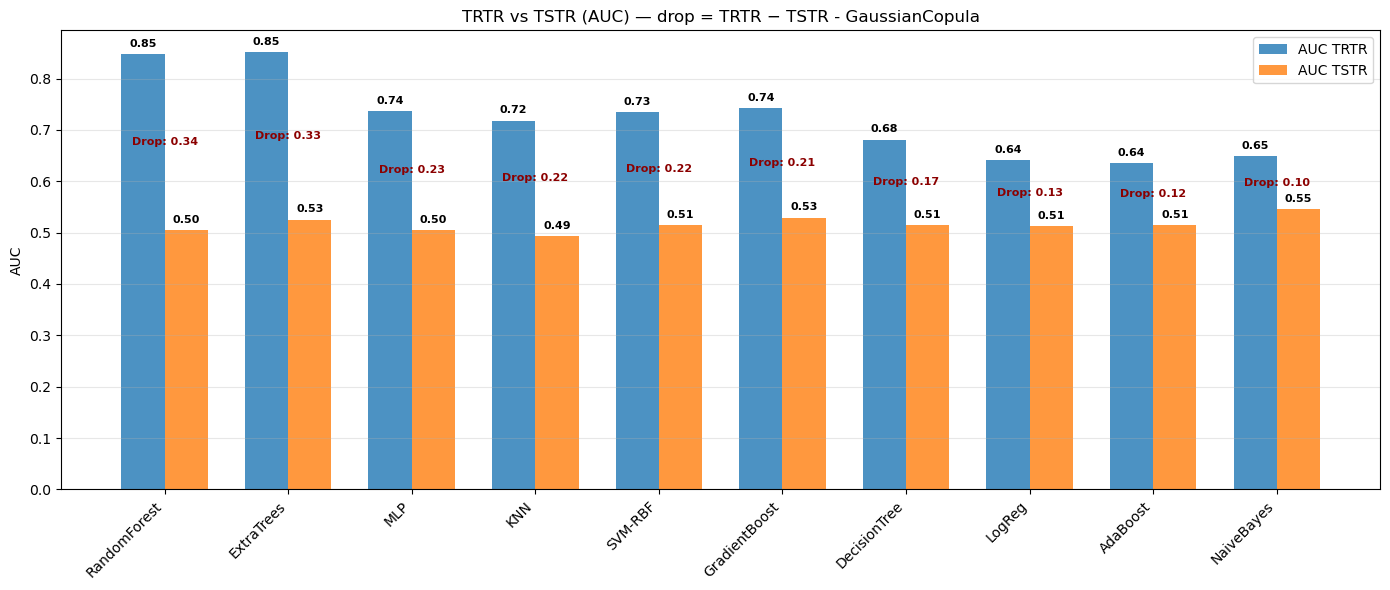

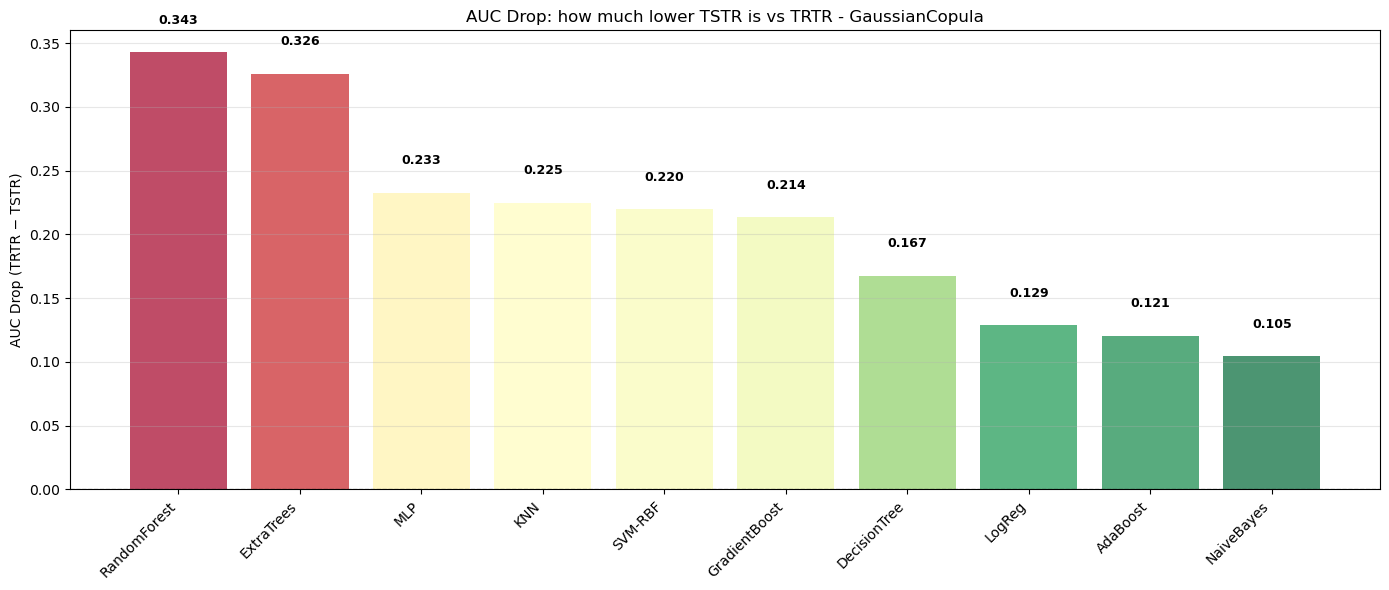

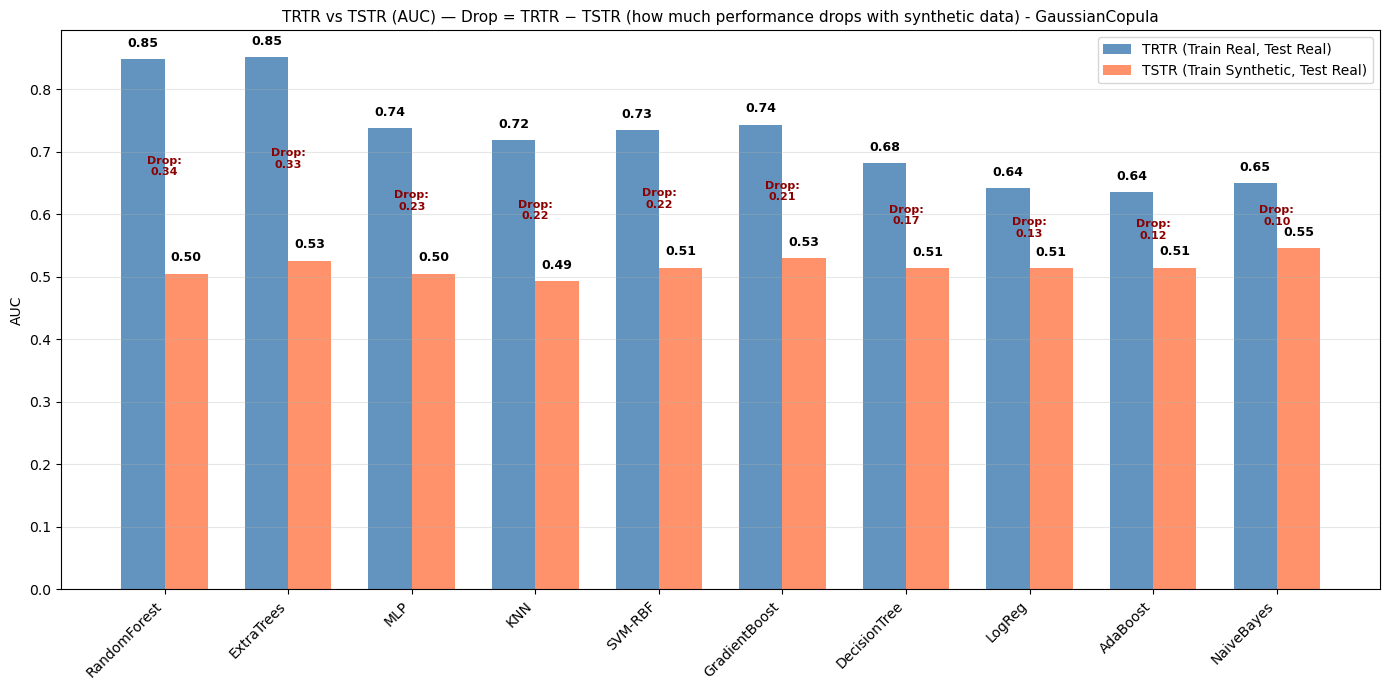

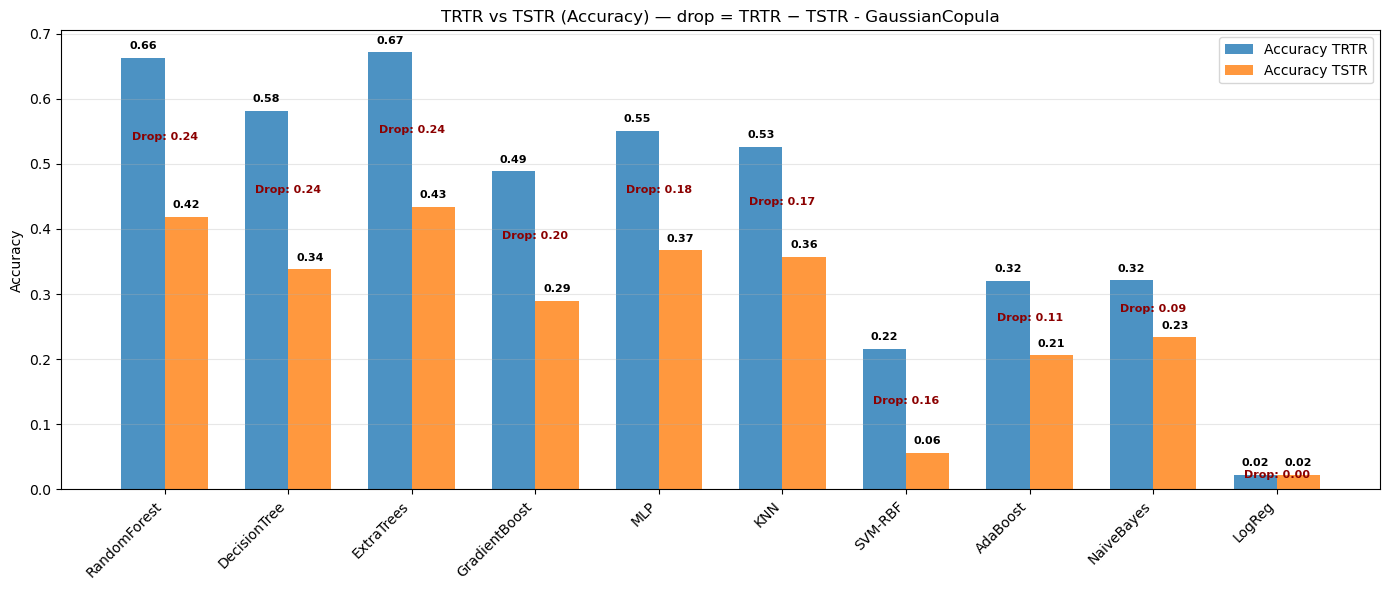

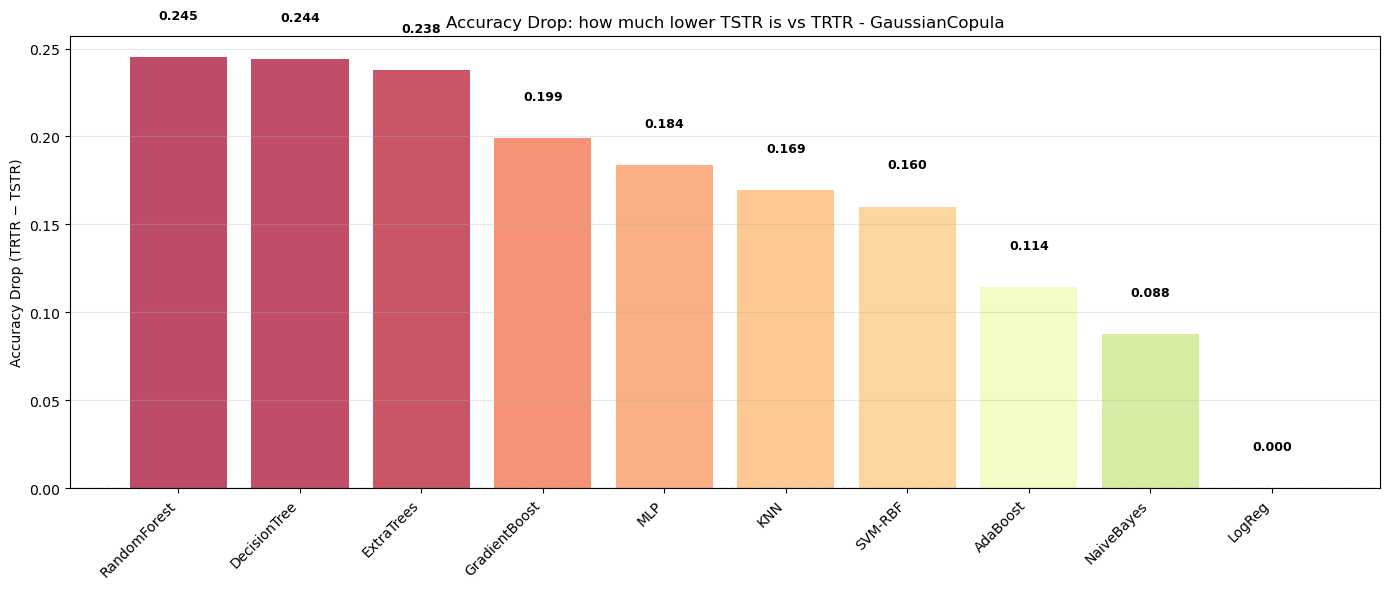

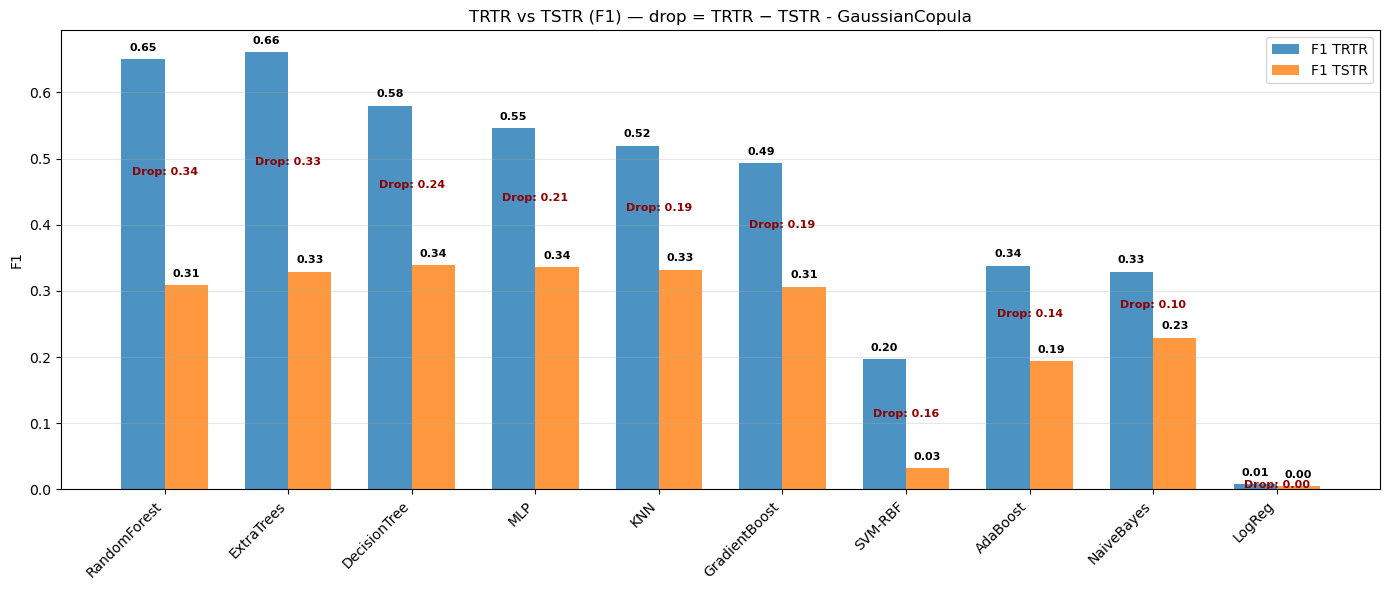

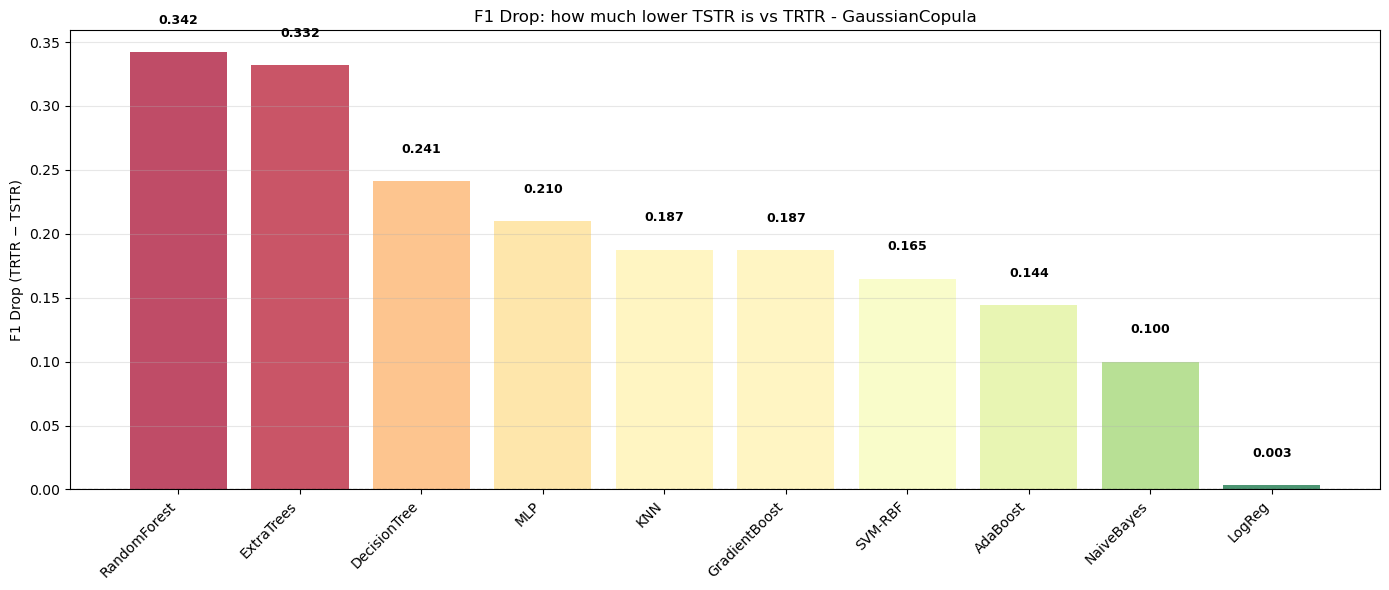

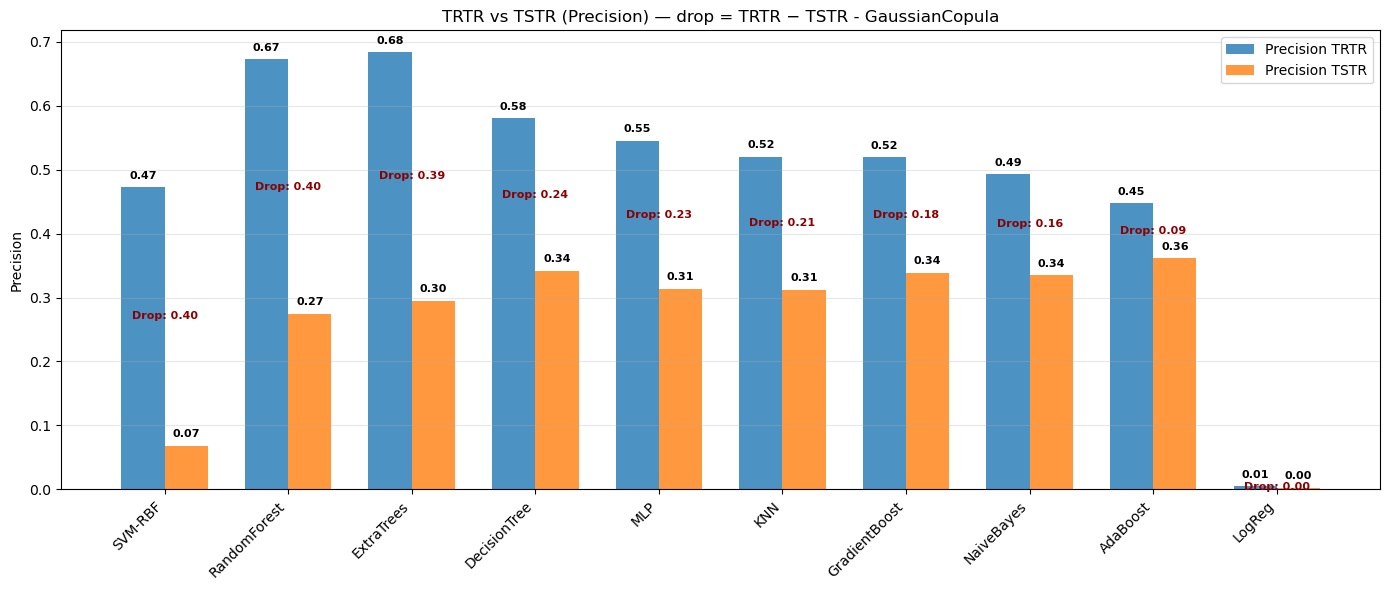

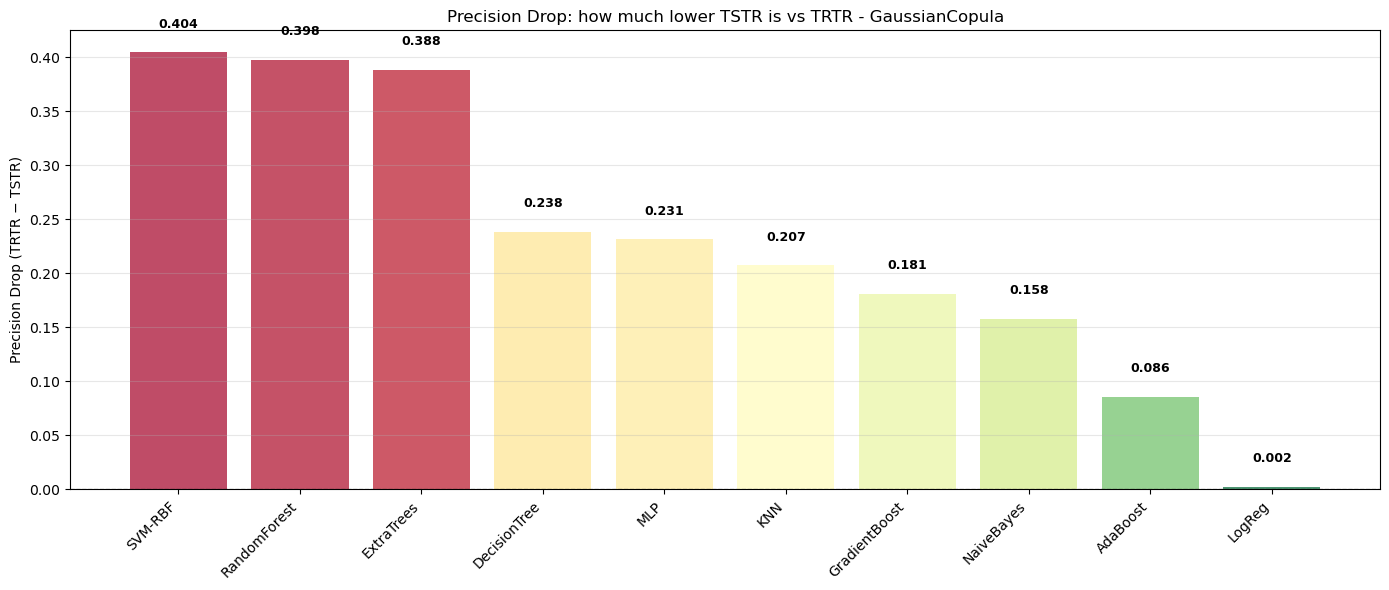

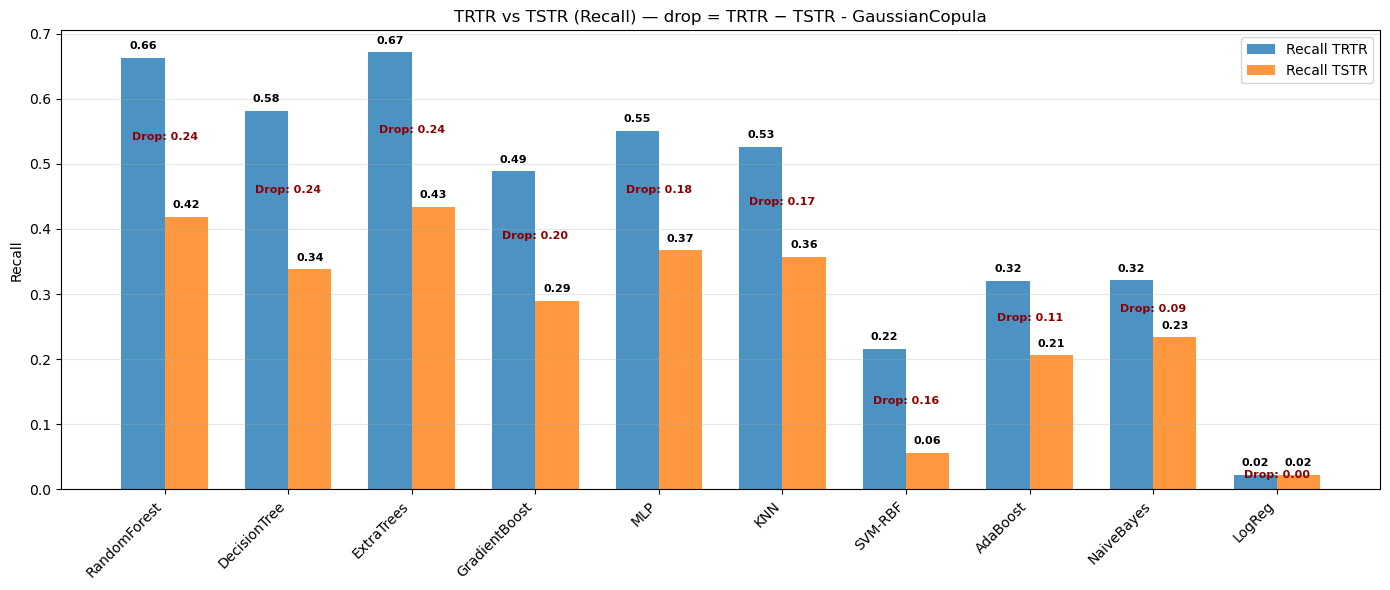

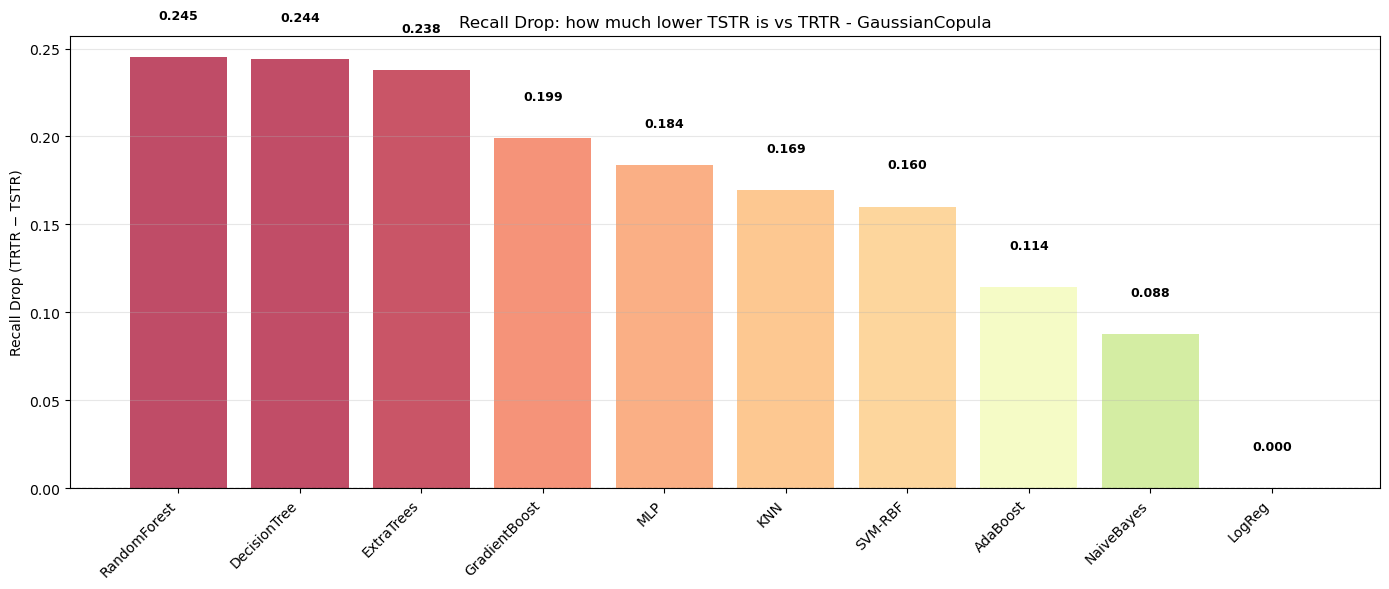

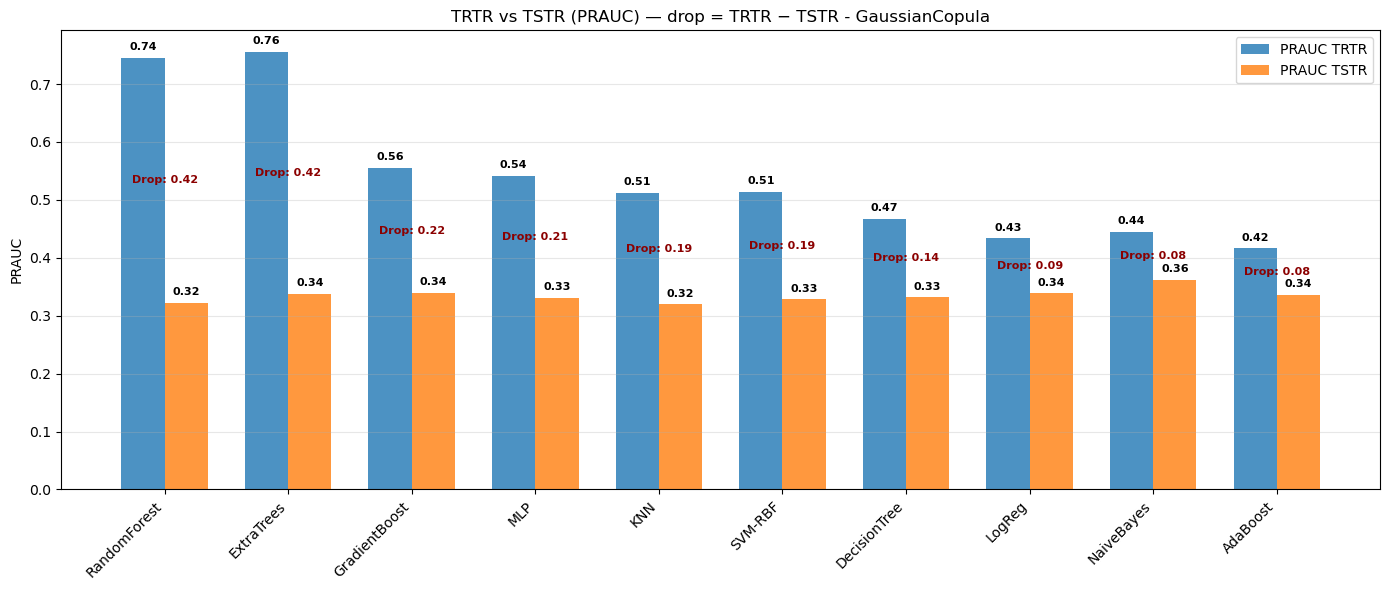

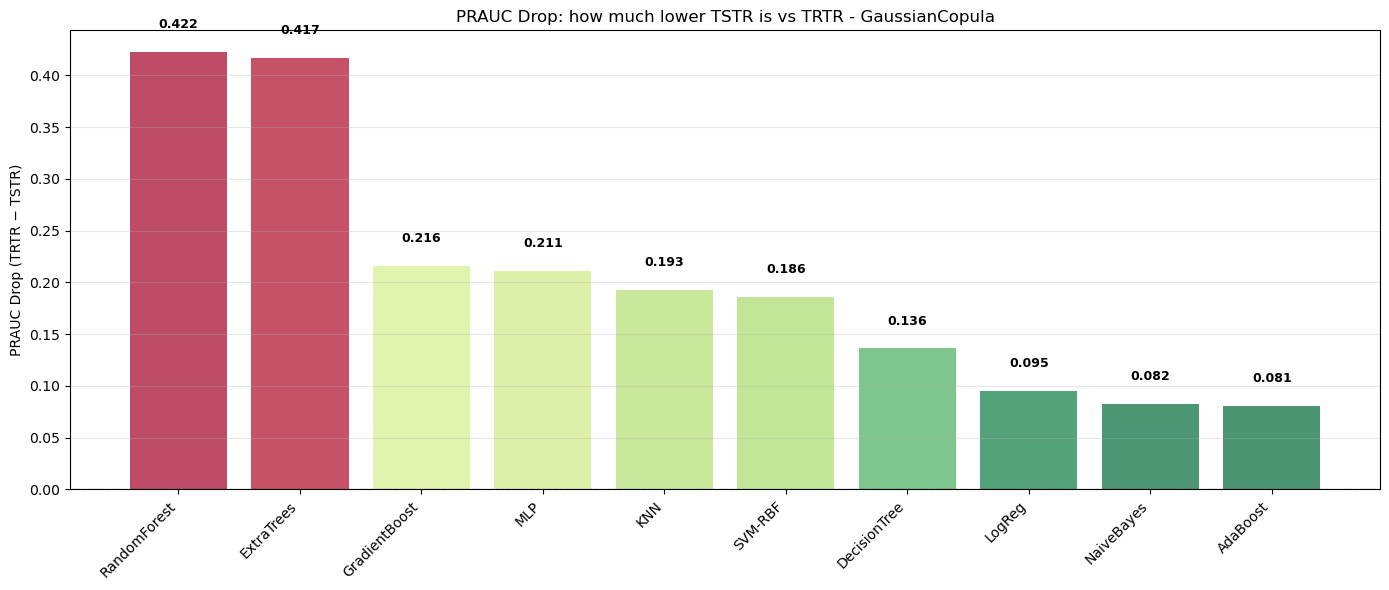


Delta metrics (TRTR − TSTR) — GaussianCopula


,Model,AUC_Drop,F1_Drop,Accuracy_Drop,Precision_Drop,Recall_Drop,PRAUC_Drop
6,ExtraTrees,0.3260,0.3318,0.2378,0.3883,0.2378,0.4168
5,RandomForest,0.3428,0.3421,0.2449,0.3976,0.2449,0.4225
7,GradientBoost,0.2136,0.1872,0.1990,0.1810,0.1990,0.2161
9,MLP,0.2327,0.2097,0.1837,0.2315,0.1837,0.2113
1,SVM-RBF,0.2199,0.1649,0.1602,0.4045,0.1602,0.1863
2,KNN,0.2248,0.1874,0.1694,0.2074,0.1694,0.1929
4,DecisionTree,0.1674,0.2411,0.2439,0.2384,0.2439,0.1362
3,NaiveBayes,0.1046,0.0997,0.0878,0.1579,0.0878,0.0824
0,LogReg,0.1287,0.0033,0.0000,0.0022,0.0000,0.0950
8,AdaBoost,0.1207,0.1442,0.1143,0.0858,0.1143,0.0809


In [62]:
if len(all_results) > 0:
    for model_name, results_df in all_results.items():
        print(f"\n{'='*70}")
        print(f"Comparison Graphs for {model_name}")
        print(f"{'='*70}")
        create_comprehensive_comparison(results_df, model_name=model_name)
        print_delta_metrics_summary(results_df, model_name=model_name)
else:
    print("No results. Run the synthetic data and evaluation cells first.")

## 5. Fidelity: Column Shapes (KS Complement)


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 277.16it/s]|
Column Shapes Score: 88.44%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 201.35it/s]|
Column Pair Trends Score: 87.16%

Overall Score (Average): 87.8%



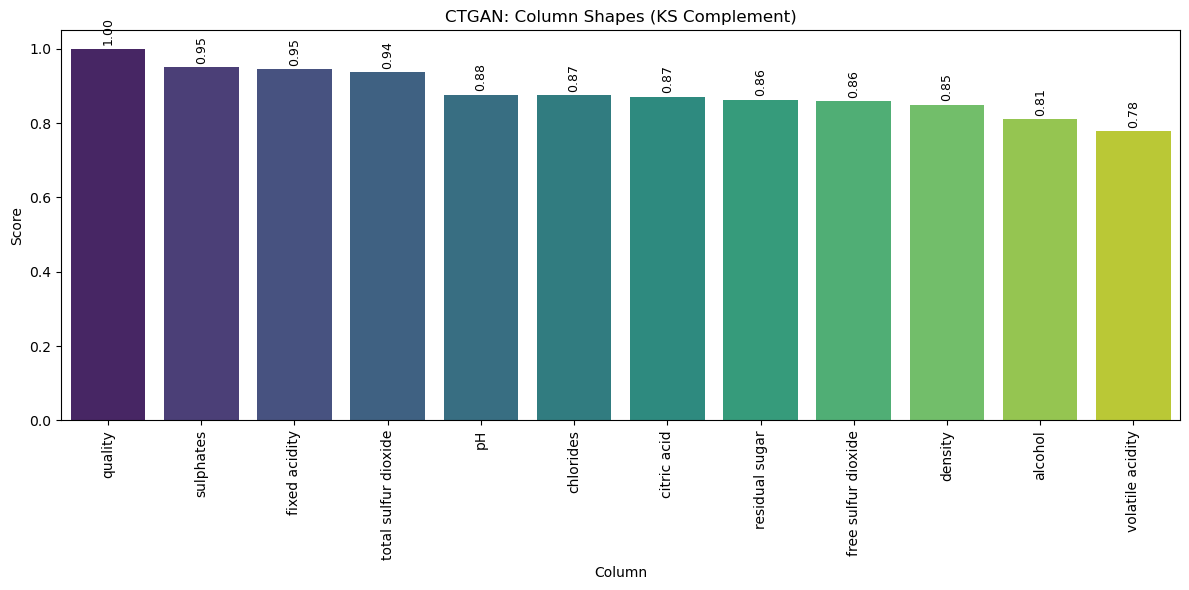

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 272.15it/s]|
Column Shapes Score: 90.29%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 252.32it/s]|
Column Pair Trends Score: 88.77%

Overall Score (Average): 89.53%



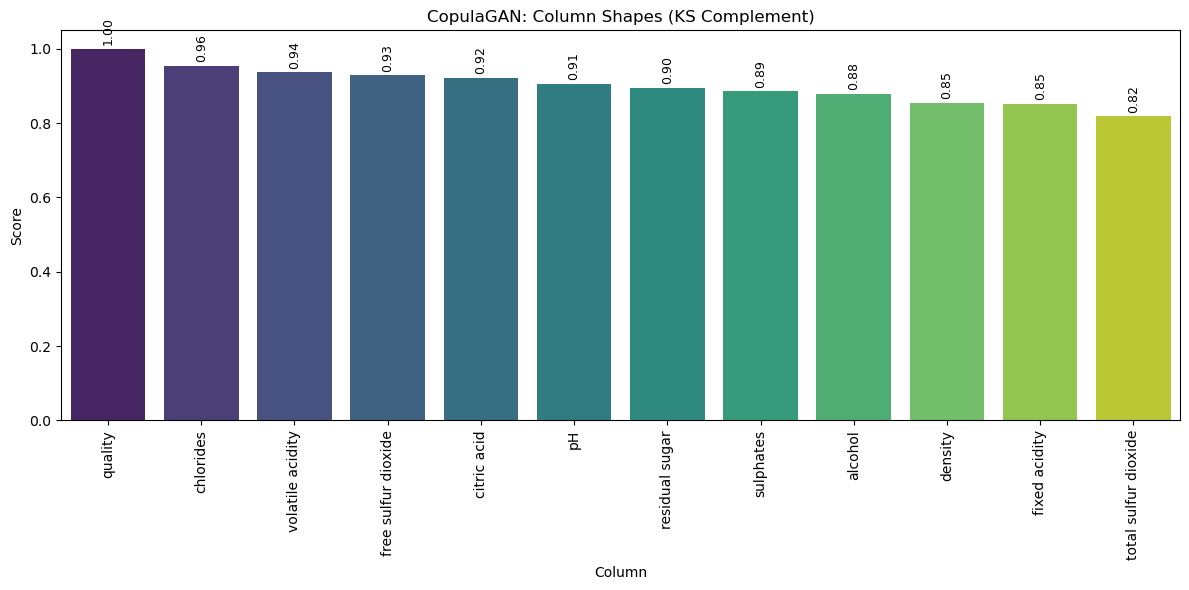

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 32.33it/s]|
Column Shapes Score: 87.3%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 315.60it/s]|
Column Pair Trends Score: 87.16%

Overall Score (Average): 87.23%



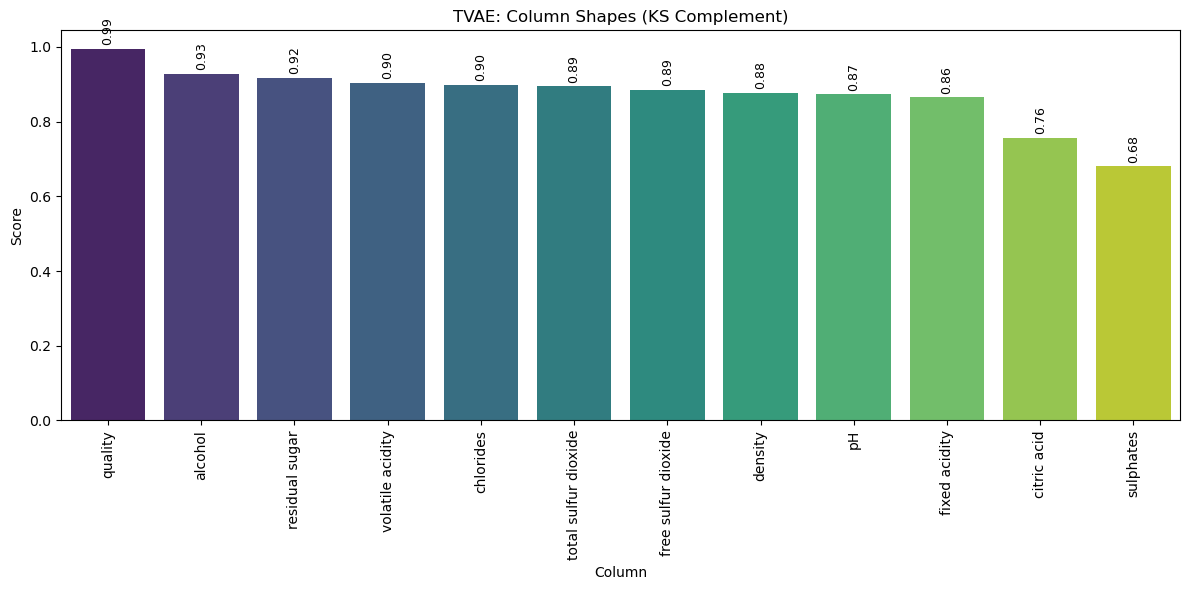

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 486.58it/s]|
Column Shapes Score: 95.11%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 305.08it/s]|
Column Pair Trends Score: 92.83%

Overall Score (Average): 93.97%



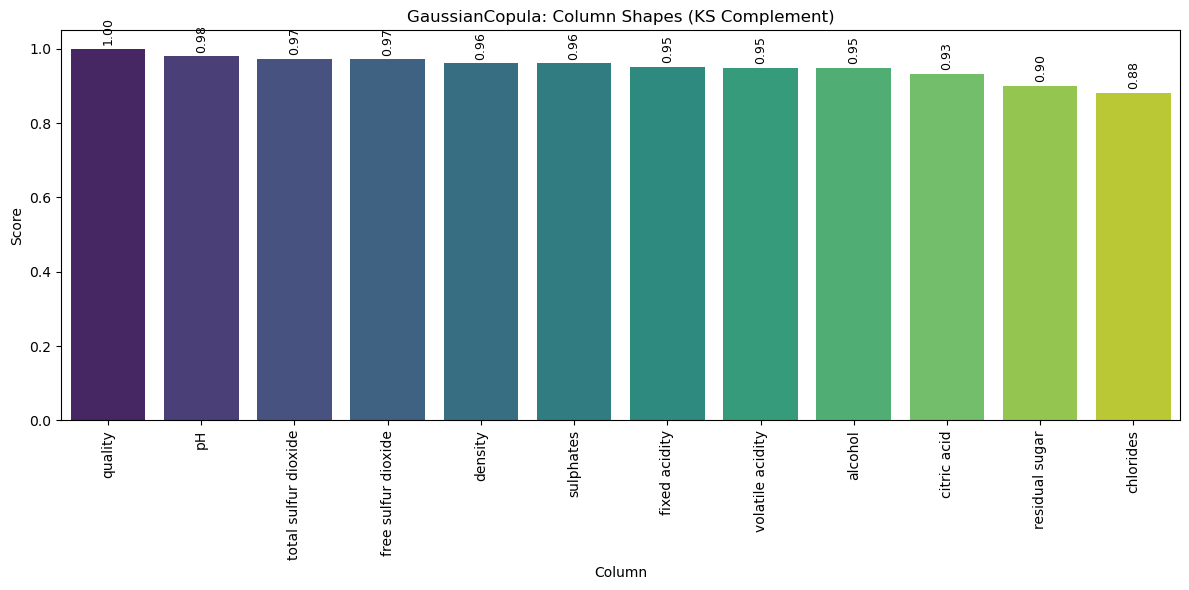

In [63]:
from sdv.evaluation.single_table import QualityReport
import seaborn as sns

synthetic_data_dict = {
    "CTGAN": synthetic_data["CTGAN"],
    "CopulaGAN": synthetic_data["CopulaGAN"],
    "TVAE": synthetic_data["TVAE"],
    "GaussianCopula": synthetic_data["GaussianCopula"]
}

for model_name, synth_df in synthetic_data_dict.items():
    qr = QualityReport()
    qr.generate(real_data=wine_data, synthetic_data=synth_df, metadata=metadata.to_dict())
    details = qr.get_details('Column Shapes')
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='Column', y='Score', data=details.sort_values('Score', ascending=False), palette='viridis')
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.01, f"{p.get_height():.2f}", ha='center', va='bottom', fontsize=9, rotation=90)
    plt.title(f'{model_name}: Column Shapes (KS Complement)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Line graphs: performance decay (TRTR vs TSTR) across 10 classifiers

For each synthetic data model, line plots show **TRTR** (train real, test real) and **TSTR** (train synthetic, test real) for each utility metric. The gap between the two lines is the performance decay when using synthetic data for training.

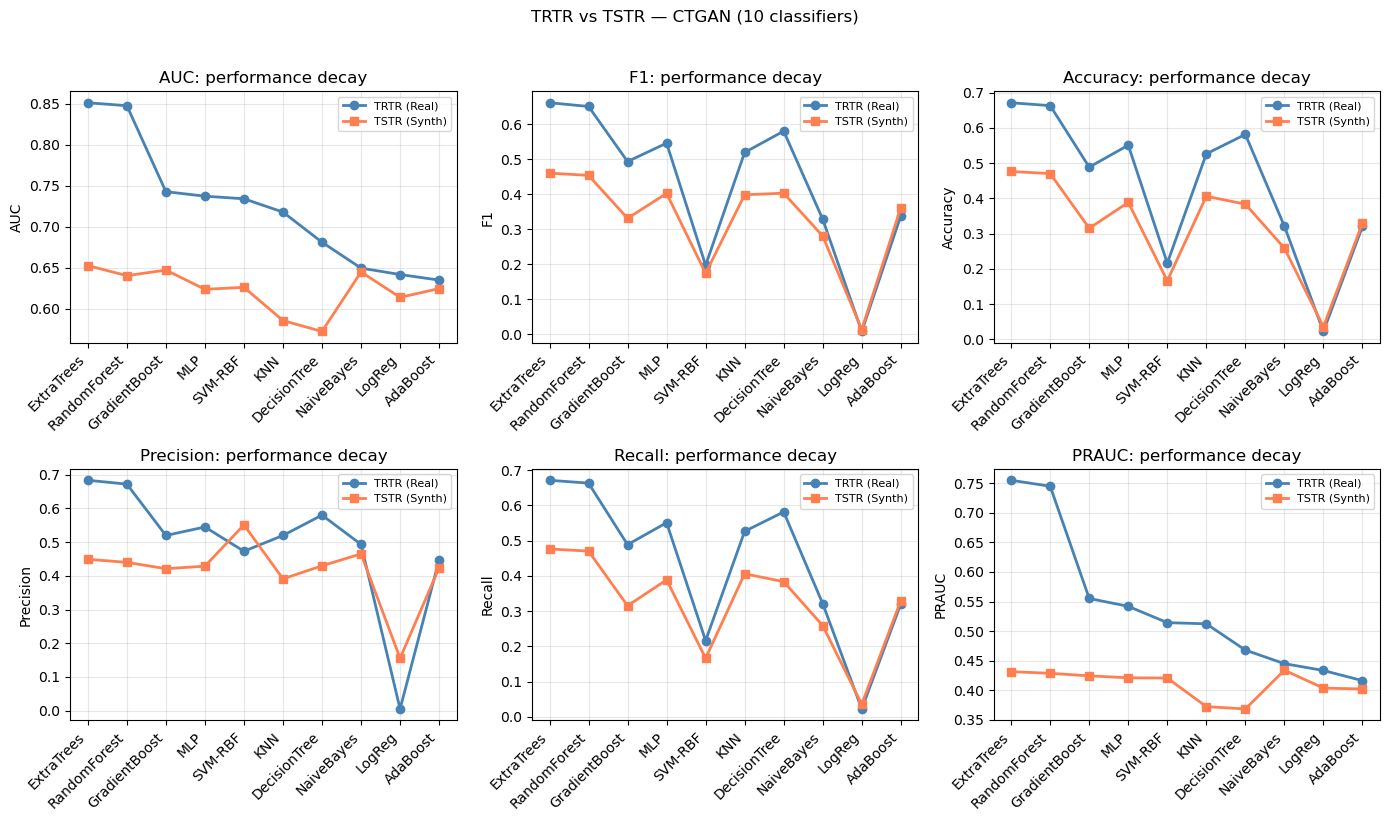

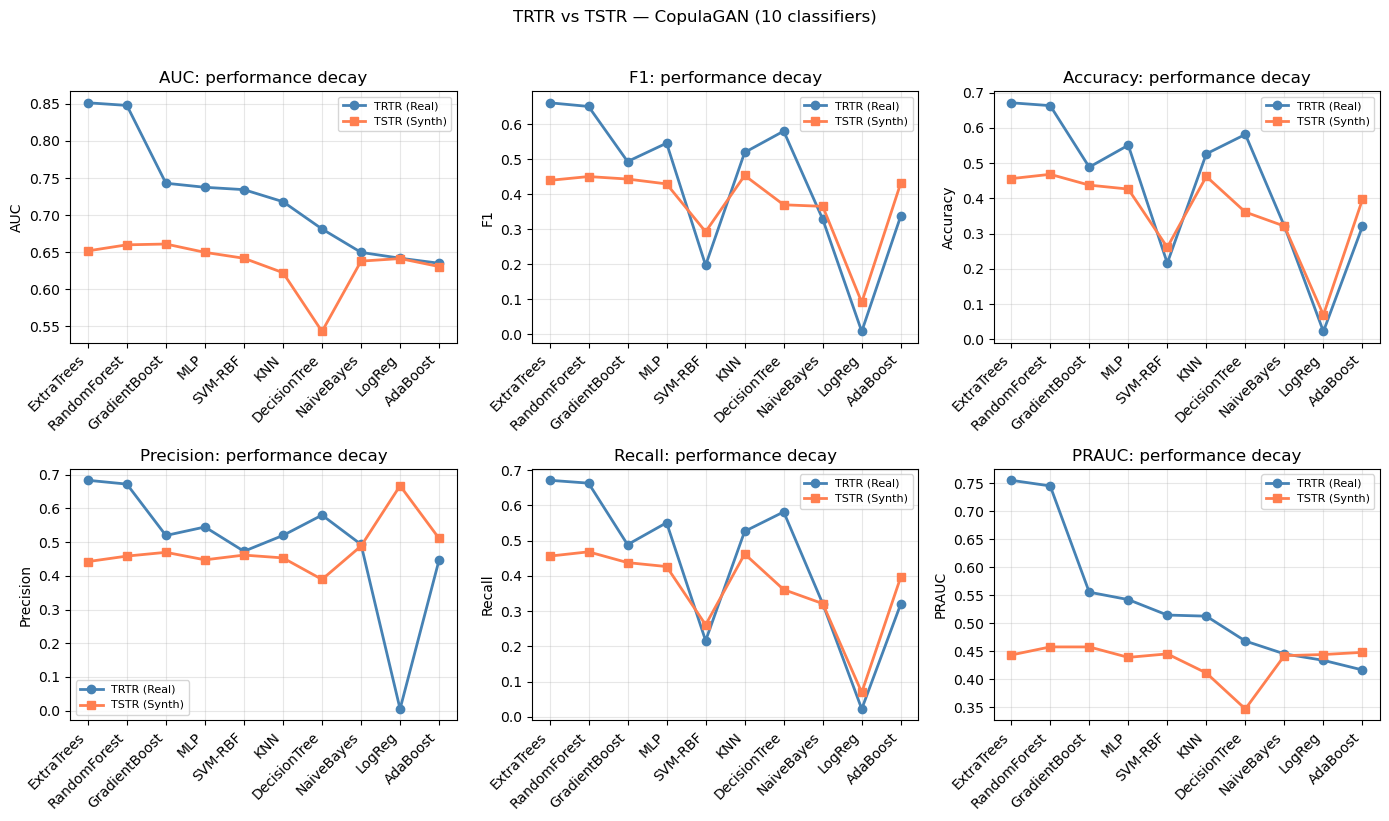

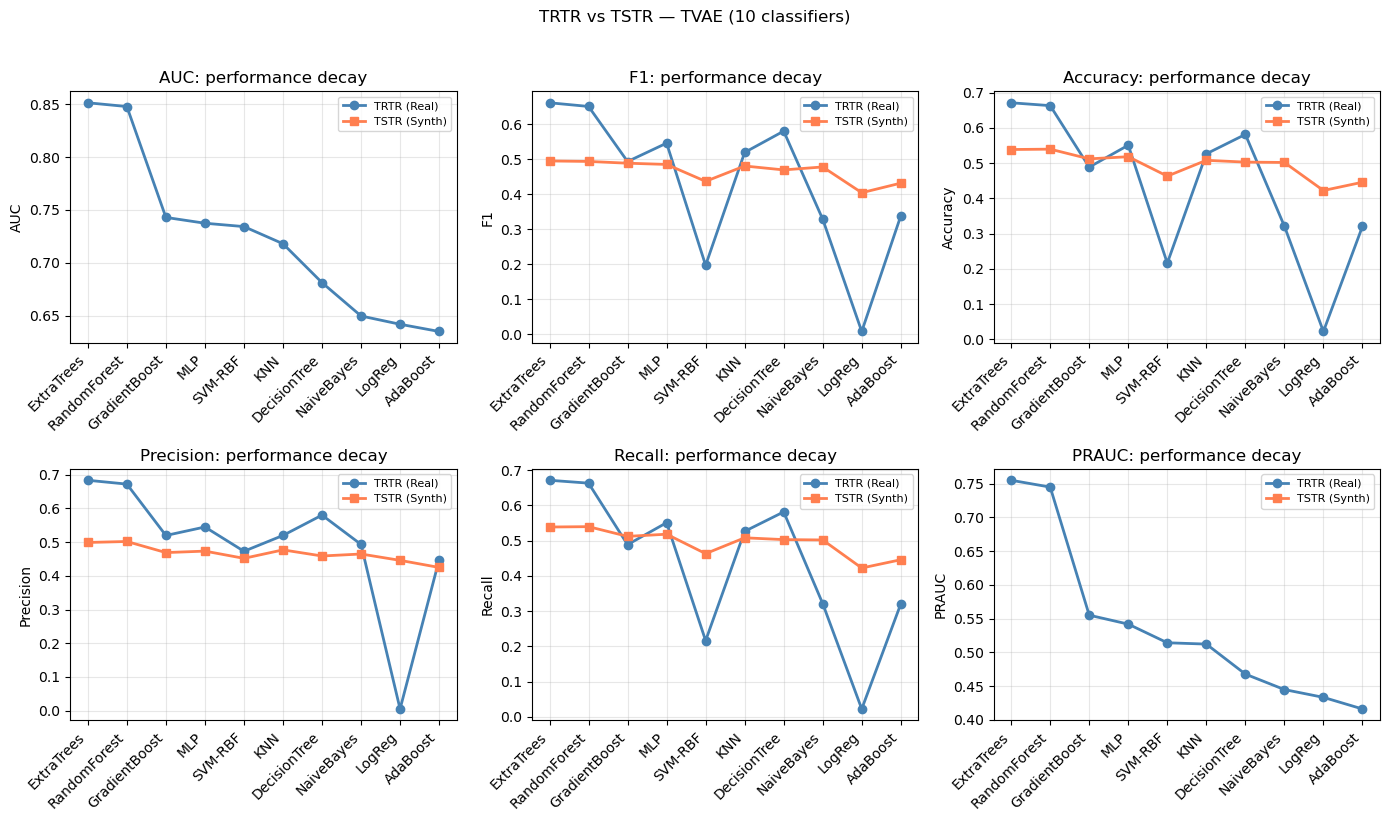

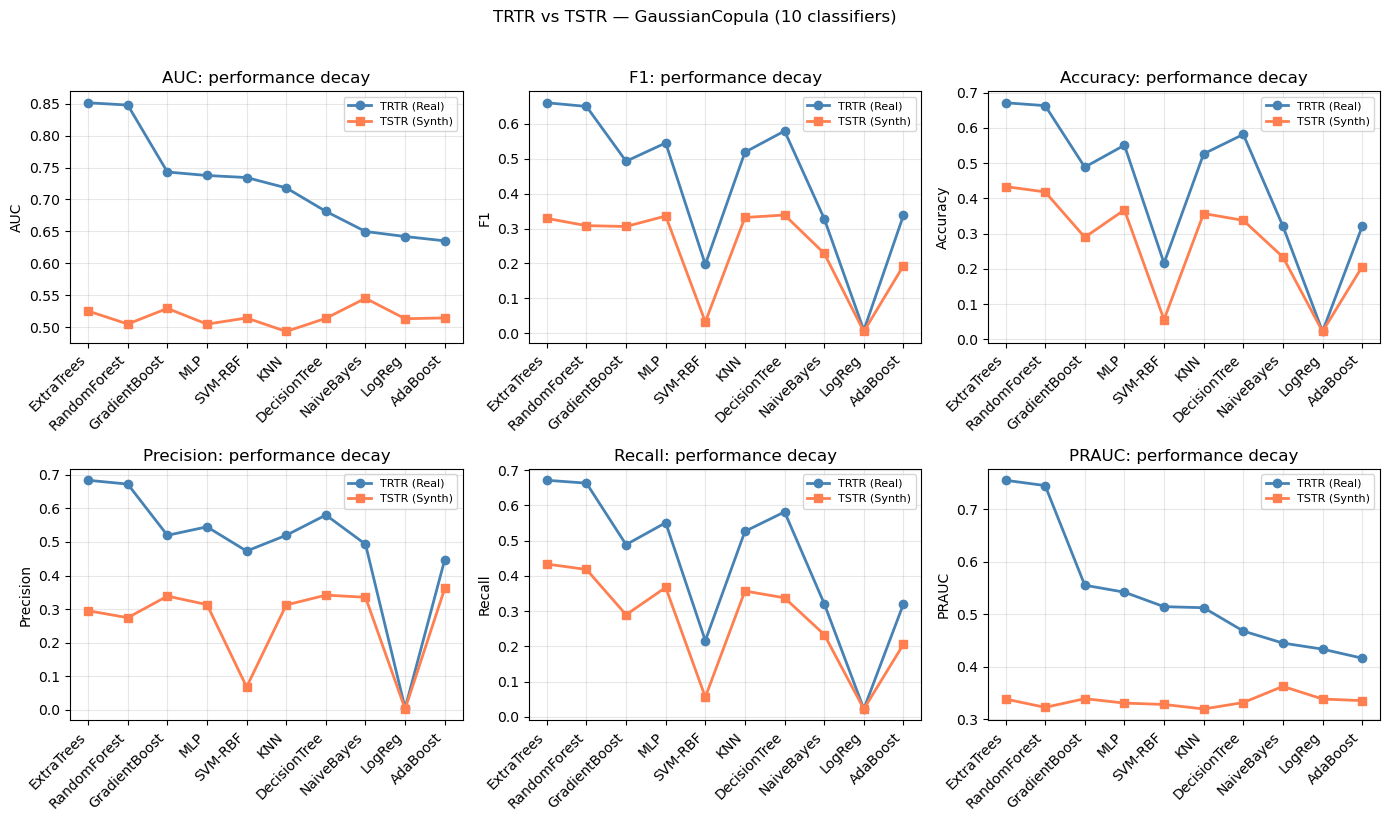

In [64]:
import matplotlib.pyplot as plt

_metrics = ['AUC', 'F1', 'Accuracy', 'Precision', 'Recall', 'PRAUC']
if len(all_results) == 0:
    print("No results. Run the TSTR/TRTR evaluation cells first.")
else:
    for sdv_name, results_df in all_results.items():
        df = results_df.copy()
        classifiers = df["Model"].tolist()
        x = np.arange(len(classifiers))
        fig, axes = plt.subplots(2, 3, figsize=(14, 8))
        axes = axes.flatten()
        for idx, metric in enumerate(_metrics):
            trtr_col = f"{metric}_TRTR"
            tstr_col = f"{metric}_TSTR"
            if trtr_col not in df.columns or tstr_col not in df.columns:
                axes[idx].set_visible(False)
                continue
            ax = axes[idx]
            trtr_vals = df[trtr_col].replace([np.inf, -np.inf], np.nan).values
            tstr_vals = df[tstr_col].replace([np.inf, -np.inf], np.nan).values
            ax.plot(x, trtr_vals, 'o-', color='steelblue', linewidth=2, markersize=6, label='TRTR (Real)')
            ax.plot(x, tstr_vals, 's-', color='coral', linewidth=2, markersize=6, label='TSTR (Synth)')
            ax.set_xticks(x)
            ax.set_xticklabels(classifiers, rotation=45, ha='right')
            ax.set_ylabel(metric)
            ax.set_title(f'{metric}: performance decay')
            ax.legend(loc='best', fontsize=8)
            ax.grid(True, alpha=0.3)
        plt.suptitle(f'TRTR vs TSTR — {sdv_name} (10 classifiers)', fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()

## 6. Fidelity: Wasserstein Distance


In [65]:
from scipy.stats import wasserstein_distance

wasserstein_results = {}

for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    scaler = StandardScaler().fit(wine_data[numeric_cols])
    real_scaled = pd.DataFrame(scaler.transform(wine_data[numeric_cols]), columns=numeric_cols)
    synth_scaled = pd.DataFrame(scaler.transform(synth_df[numeric_cols]), columns=numeric_cols)
    wasserstein_scores = []
    for col in numeric_cols:
        r = real_scaled[col].dropna().astype(float)
        s = synth_scaled[col].dropna().astype(float)
        try:
            w_dist = wasserstein_distance(r, s)
        except Exception:
            w_dist = np.nan
        wasserstein_scores.append({"Column": col, "Wasserstein": w_dist})
    wasserstein_results[model_name] = pd.DataFrame(wasserstein_scores).sort_values("Wasserstein")
    print(f"\nWasserstein distances for {model_name}:")
    print(wasserstein_results[model_name])


Wasserstein distances for CTGAN:
                  Column  Wasserstein
11               quality     0.000000
9              sulphates     0.081978
0          fixed acidity     0.082181
6   total sulfur dioxide     0.173550
3         residual sugar     0.199334
5    free sulfur dioxide     0.239263
4              chlorides     0.254709
2            citric acid     0.265820
8                     pH     0.331469
7                density     0.390985
1       volatile acidity     0.406955
10               alcohol     0.461720

Wasserstein distances for CopulaGAN:
                  Column  Wasserstein
11               quality     0.000000
1       volatile acidity     0.083514
5    free sulfur dioxide     0.119370
3         residual sugar     0.133667
4              chlorides     0.137084
8                     pH     0.223792
2            citric acid     0.231350
9              sulphates     0.247830
10               alcohol     0.250711
0          fixed acidity     0.312835
7               

## 7. Fidelity: JS Divergence


In [66]:
from scipy.spatial.distance import jensenshannon

def compute_js_divergence(real_vals, synth_vals, bins=30):
    real_vals = np.asarray(real_vals)[~np.isnan(np.asarray(real_vals))]
    synth_vals = np.asarray(synth_vals)[~np.isnan(np.asarray(synth_vals))]
    if len(real_vals) == 0 or len(synth_vals) == 0:
        return np.nan
    low, high = min(real_vals.min(), synth_vals.min()), max(real_vals.max(), synth_vals.max())
    if low == high:
        return 0.0
    p_hist, bin_edges = np.histogram(real_vals, bins=bins, range=(low, high), density=True)
    q_hist, _ = np.histogram(synth_vals, bins=bin_edges, density=True)
    p = (p_hist + 1e-12); p /= p.sum()
    q = (q_hist + 1e-12); q /= q.sum()
    return jensenshannon(p, q, base=2) ** 2

js_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    scaler = StandardScaler().fit(wine_data[numeric_cols])
    real_scaled = pd.DataFrame(scaler.transform(wine_data[numeric_cols]), columns=numeric_cols)
    synth_scaled = pd.DataFrame(scaler.transform(synth_df[numeric_cols]), columns=numeric_cols)
    js_scores = [{"Column": col, "JS_Divergence": compute_js_divergence(real_scaled[col], synth_scaled[col])} for col in numeric_cols]
    js_results[model_name] = pd.DataFrame(js_scores).sort_values("JS_Divergence")
    print(f"\nJS Divergence for {model_name}:")
    print(js_results[model_name])


JS Divergence for CTGAN:
                  Column  JS_Divergence
11               quality       0.000000
0          fixed acidity       0.009832
9              sulphates       0.010749
6   total sulfur dioxide       0.011332
3         residual sugar       0.013976
5    free sulfur dioxide       0.015561
4              chlorides       0.023109
2            citric acid       0.025479
8                     pH       0.027805
7                density       0.034951
1       volatile acidity       0.047958
10               alcohol       0.083788

JS Divergence for CopulaGAN:
                  Column  JS_Divergence
11               quality       0.000000
4              chlorides       0.008045
5    free sulfur dioxide       0.012180
1       volatile acidity       0.014445
3         residual sugar       0.015663
9              sulphates       0.017913
7                density       0.022371
10               alcohol       0.023032
8                     pH       0.025278
0          fixed acidity

## 8. Fidelity: Gower Distance

Gower distance measures dissimilarity between real and synthetic samples (handles mixed numeric columns). We report mean Gower distance between datasets (sampled for speed).

In [67]:
# Gower distance (numeric columns only; normalized by range)
def gower_distance_numeric(real_df, synth_df, numeric_cols, n_sample=500):
    """Mean pairwise Gower-like distance: for each real point, mean normalized L1 to nearest synth (or mean over sample)."""
    from sklearn.neighbors import NearestNeighbors
    real = real_df[numeric_cols].dropna()
    synth = synth_df[numeric_cols].dropna()
    n_r = min(n_sample, len(real))
    n_s = min(n_sample, len(synth))
    real_s = real.sample(n_r, random_state=42)
    synth_s = synth.sample(n_s, random_state=42)
    mins = real_s.min()
    maxs = real_s.max()
    rng = (maxs - mins).replace(0, 1)
    real_n = (real_s - mins) / rng
    synth_n = (synth_s - mins) / rng
    nn = NearestNeighbors(n_neighbors=1, metric='manhattan').fit(synth_n)
    dists, _ = nn.kneighbors(real_n)
    return float(np.mean(dists))

gower_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    gower_results[model_name] = gower_distance_numeric(wine_data, synth_df, numeric_cols)
    print(f"{model_name}: mean Gower distance = {gower_results[model_name]:.4f}")
print("\nGower (lower is better):", gower_results)

CTGAN: mean Gower distance = 0.9052
CopulaGAN: mean Gower distance = 0.8680
TVAE: mean Gower distance = 0.7465
GaussianCopula: mean Gower distance = 0.7987

Gower (lower is better): {'CTGAN': 0.9051944169930083, 'CopulaGAN': 0.8680235214157915, 'TVAE': 0.7465068729846663, 'GaussianCopula': 0.7986863003919191}


## 9. Fidelity: MMD (Maximum Mean Discrepancy)

MMD measures the distance between distributions in a reproducing kernel Hilbert space (RBF kernel). Lower MMD means synthetic distribution is closer to real.

In [68]:
# MMD with RBF kernel
def mmd_rbf(real, synth, gamma=None, n_sample=500):
    """Maximum Mean Discrepancy (RBF kernel). real, synth: (n, d) arrays."""
    n_r = min(n_sample, len(real))
    n_s = min(n_sample, len(synth))
    real = np.asarray(real)[:n_r] if real.ndim == 2 else np.asarray(real).reshape(-1, 1)[:n_r]
    synth = np.asarray(synth)[:n_s] if synth.ndim == 2 else np.asarray(synth).reshape(-1, 1)[:n_s]
    if gamma is None:
        gamma = 1.0 / real.shape[1] if real.shape[1] else 1.0
    def rbf(X, Y):
        X = np.atleast_2d(X)
        Y = np.atleast_2d(Y)
        dxx = np.sum(X**2, axis=1, keepdims=True) + np.sum(Y**2, axis=1) - 2 * X @ Y.T
        return np.exp(-gamma * np.maximum(dxx, 0))
    k_rr = rbf(real, real)
    k_ss = rbf(synth, synth)
    k_rs = rbf(real, synth)
    mmd2 = np.mean(k_rr) + np.mean(k_ss) - 2 * np.mean(k_rs)
    return max(0, mmd2) ** 0.5

mmd_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    scaler = StandardScaler().fit(wine_data[numeric_cols])
    real_s = scaler.transform(wine_data[numeric_cols])
    synth_s = scaler.transform(synth_df[numeric_cols])
    mmd_results[model_name] = mmd_rbf(real_s, synth_s)
    print(f"{model_name}: MMD = {mmd_results[model_name]:.4f}")
print("\nMMD (lower is better):", mmd_results)

CTGAN: MMD = 0.2094
CopulaGAN: MMD = 0.1416
TVAE: MMD = 0.2446
GaussianCopula: MMD = 0.1377

MMD (lower is better): {'CTGAN': 0.20941862295805305, 'CopulaGAN': 0.14163932549698563, 'TVAE': 0.24461722440954356, 'GaussianCopula': 0.1377374676723559}


## 10. Fidelity: Cosine Similarity (Correlation Matrices)

Compare correlation structure: compute correlation matrix of real vs synthetic numeric columns, then cosine similarity between the flattened upper triangles (excluding diagonal). Higher is better.

In [69]:
# Cosine similarity between correlation matrices
from numpy.linalg import norm

def correlation_cosine_similarity(real_df, synth_df, numeric_cols):
    r_corr = real_df[numeric_cols].corr().values
    s_corr = synth_df[numeric_cols].corr().values
    n = len(numeric_cols)
    triu_idx = np.triu_indices(n, k=1)
    r_flat = r_corr[triu_idx]
    s_flat = s_corr[triu_idx]
    if norm(r_flat) < 1e-12 or norm(s_flat) < 1e-12:
        return float("nan")
    return float(np.dot(r_flat, s_flat) / (norm(r_flat) * norm(s_flat)))

cosine_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    cosine_results[model_name] = correlation_cosine_similarity(wine_data, synth_df, numeric_cols)
    print(f"{model_name}: correlation cosine similarity = {cosine_results[model_name]:.4f}")
print("\nCosine similarity (higher is better):", cosine_results)

CTGAN: correlation cosine similarity = 0.6297
CopulaGAN: correlation cosine similarity = 0.8262
TVAE: correlation cosine similarity = 0.9105
GaussianCopula: correlation cosine similarity = 0.9415

Cosine similarity (higher is better): {'CTGAN': 0.6297361765048621, 'CopulaGAN': 0.826234865474777, 'TVAE': 0.9104811328508552, 'GaussianCopula': 0.9414666694434255}


## 11. Fidelity: Average Nearest Neighbor Distance

For each real point, compute distance to nearest synthetic point; average. Then (optionally) symmetric: average of real→synth and synth→real. Lower means synthetic points are closer to real (better coverage).

In [70]:
# Average Nearest Neighbor Distance (Euclidean on scaled numeric columns)
from sklearn.neighbors import NearestNeighbors

def ann_distance(real_df, synth_df, numeric_cols, n_sample=500):
    scaler = StandardScaler().fit(real_df[numeric_cols])
    real_s = scaler.transform(real_df[numeric_cols])
    synth_s = scaler.transform(synth_df[numeric_cols])
    n_r = min(n_sample, len(real_s))
    n_s = min(n_sample, len(synth_s))
    real_s = real_s[:n_r]
    synth_s = synth_s[:n_s]
    nn_synth = NearestNeighbors(n_neighbors=1).fit(synth_s)
    nn_real = NearestNeighbors(n_neighbors=1).fit(real_s)
    d_r_to_s, _ = nn_synth.kneighbors(real_s)
    d_s_to_r, _ = nn_real.kneighbors(synth_s)
    ann_r2s = float(np.mean(d_r_to_s))
    ann_s2r = float(np.mean(d_s_to_r))
    return (ann_r2s + ann_s2r) / 2, ann_r2s, ann_s2r

ann_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    ann_mean, ann_r2s, ann_s2r = ann_distance(wine_data, synth_df, numeric_cols)
    ann_results[model_name] = ann_mean
    print(f"{model_name}: ANN (symmetric) = {ann_mean:.4f}  (real→synth = {ann_r2s:.4f}, synth→real = {ann_s2r:.4f})")
print("\nAverage NN distance (lower is better):", ann_results)

CTGAN: ANN (symmetric) = 2.2919  (real→synth = 2.2032, synth→real = 2.3805)
CopulaGAN: ANN (symmetric) = 2.0950  (real→synth = 2.0404, synth→real = 2.1496)
TVAE: ANN (symmetric) = 1.7133  (real→synth = 1.8640, synth→real = 1.5627)
GaussianCopula: ANN (symmetric) = 2.0066  (real→synth = 1.9831, synth→real = 2.0301)

Average NN distance (lower is better): {'CTGAN': 2.2918776457129724, 'CopulaGAN': 2.094990797822827, 'TVAE': 1.713336040612397, 'GaussianCopula': 2.006565049048624}


## 12. Bivariate Analysis

Preservation of pairwise correlations (Δ-correlation) and of feature–target association (Δ correlation with quality). Lower delta means synthetic data preserves relationships better.

In [71]:
# Bivariate analysis: Δ-correlation and feature–target preservation
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler

def bivariate_quality_wine(real_df, synth_df, target='quality'):
    num_cols = [c for c in real_df.columns if c != target and c in synth_df.columns]
    scaler = MinMaxScaler()
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()
    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])
    results_corr = []
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({'var_a': a, 'var_b': b, 'delta_corr': abs(r_corr - s_corr)})
    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    # Feature–target: correlation of each feature with target (real vs synthetic)
    results_target = []
    for col in num_cols:
        r_corr = real_scaled[[col, target]].corr().iloc[0, 1]
        s_corr = synth_scaled[[col, target]].corr().iloc[0, 1]
        results_target.append({"feature": col, "delta_corr_target": abs(r_corr - s_corr)})
    target_df = pd.DataFrame(results_target).sort_values("delta_corr_target", ascending=False)
    return corr_df, target_df

bivariate_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    corr_df, target_df = bivariate_quality_wine(wine_data, synth_df, target='quality')
    bivariate_results[model_name] = {'corr_df': corr_df, 'target_df': target_df}
    print(f"\n{model_name} – Top 5 Δ-correlation (pairs):")
    print(corr_df.head().to_string())
    print(f"\n{model_name} – Top 5 Δ-correlation with quality:")
    print(target_df.head().to_string())


CTGAN – Top 5 Δ-correlation (pairs):
                  var_a                 var_b  delta_corr
30       residual sugar               density    0.698098
40  free sulfur dioxide  total sulfur dioxide    0.576696
7         fixed acidity                    pH    0.444102
51              density               alcohol    0.408912
33       residual sugar               alcohol    0.408091

CTGAN – Top 5 Δ-correlation with quality:
               feature  delta_corr_target
7              density           0.321025
1     volatile acidity           0.221250
4            chlorides           0.167658
9            sulphates           0.140943
5  free sulfur dioxide           0.060952

CopulaGAN – Top 5 Δ-correlation (pairs):
                  var_a                 var_b  delta_corr
30       residual sugar               density    0.330524
51              density               alcohol    0.299590
40  free sulfur dioxide  total sulfur dioxide    0.256054
4         fixed acidity   free sulfur dioxide

## 13. t-SNE Visualization


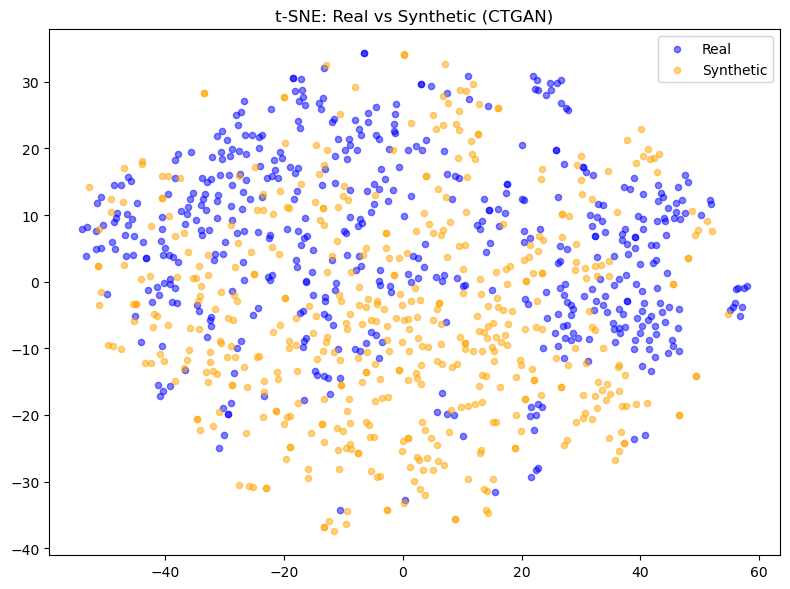

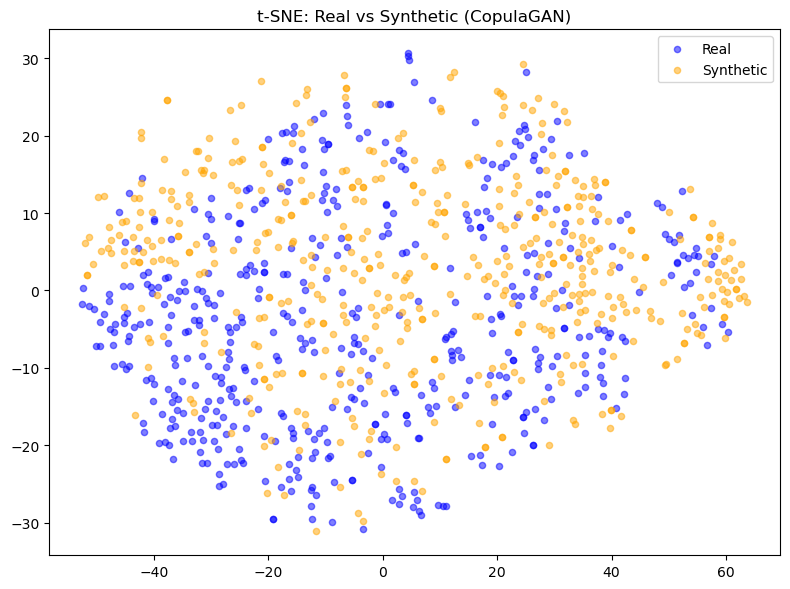

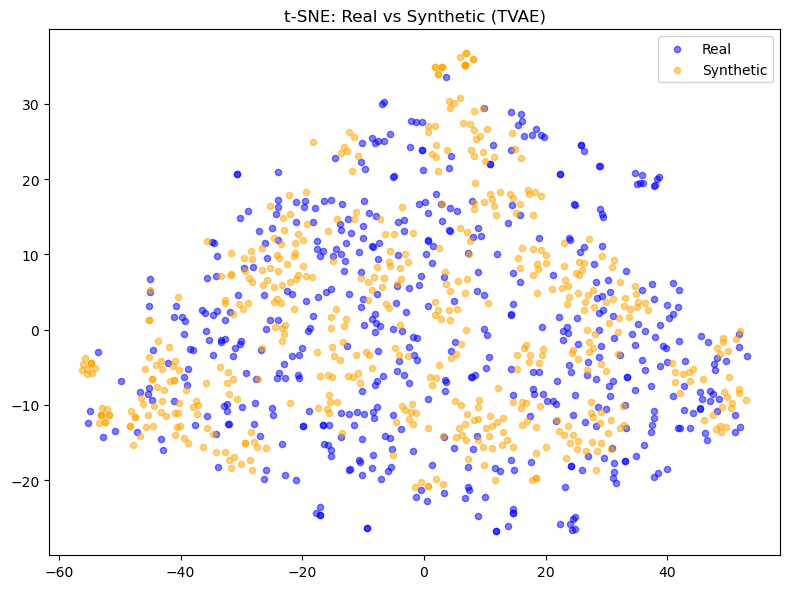

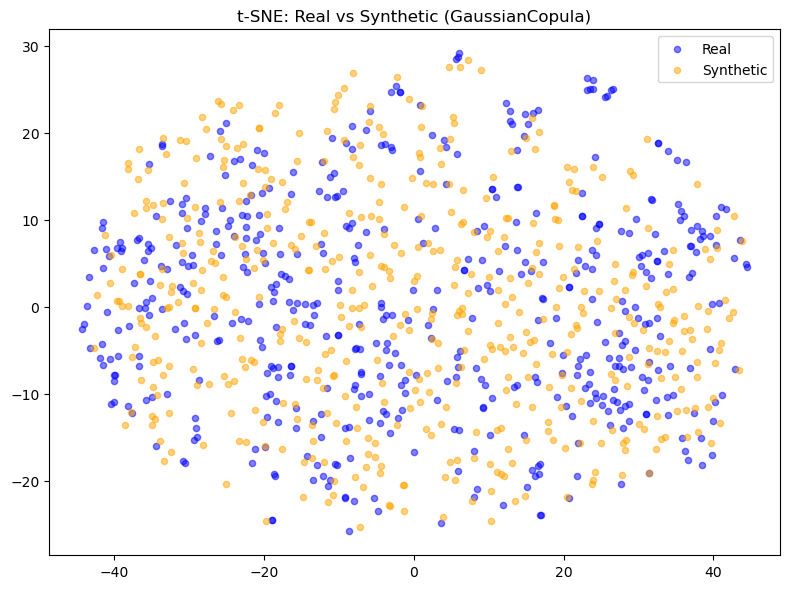

In [72]:
from sklearn.manifold import TSNE

for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    scaler = StandardScaler().fit(wine_data[numeric_cols])
    real_scaled = pd.DataFrame(scaler.transform(wine_data[numeric_cols]), columns=numeric_cols)
    synth_scaled = pd.DataFrame(scaler.transform(synth_df[numeric_cols]), columns=numeric_cols)
    n_real = min(500, len(real_scaled))
    n_synth = min(500, len(synth_scaled))
    combined = np.vstack([real_scaled.sample(n_real, random_state=42), synth_scaled.sample(n_synth, random_state=42)])
    labels = ['Real'] * n_real + ['Synthetic'] * n_synth
    X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(combined)
    plt.figure(figsize=(8, 6))
    plt.scatter(X_tsne[:n_real, 0], X_tsne[:n_real, 1], c='blue', alpha=0.5, label='Real', s=20)
    plt.scatter(X_tsne[n_real:, 0], X_tsne[n_real:, 1], c='orange', alpha=0.5, label='Synthetic', s=20)
    plt.title(f't-SNE: Real vs Synthetic ({model_name})')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Cosine similarity: Hungarian and Greedy mapping

Compare **greedy** (each real row → best synthetic by cosine similarity) and **Hungarian** (optimal 1-to-1 matching) using cosine similarity between real and synthetic samples (reference: Hungarian assesment_full_features.ipynb).

In [73]:
from numpy.linalg import norm

def _normalize_rows_cos(X):
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

_num_cols_cos = wine_data.select_dtypes(include=[np.number]).columns.tolist()
_real_matrix_cos = _normalize_rows_cos(wine_data[_num_cols_cos].to_numpy(float))
_cosine_dfs = {}

In [74]:
for model_name, synth_df in synthetic_data.items():
    _cols = [c for c in _num_cols_cos if c in synth_df.columns]
    if len(_cols) != len(_num_cols_cos):
        continue
    _synth_matrix = _normalize_rows_cos(synth_df[_cols].to_numpy(float))
    _n = min(_real_matrix_cos.shape[0], _synth_matrix.shape[0])
    _cos_mat = _real_matrix_cos[:_n] @ _synth_matrix[:_n].T
    _cosine_dfs[model_name] = pd.DataFrame(
        _cos_mat,
        index=[f"R{i+1}" for i in range(_n)],
        columns=[f"S{j+1}" for j in range(_n)]
    )
print("Cosine similarity matrices:", list(_cosine_dfs.keys()))

Cosine similarity matrices: ['CTGAN', 'CopulaGAN', 'TVAE', 'GaussianCopula']


### Greedy assignment

For each real row, assign the synthetic column with **maximum** cosine similarity (multiple real rows can map to the same synthetic row).

In [75]:
def _greedy_assignment(cos_sim_matrix):
    best_s_idx = np.argmax(cos_sim_matrix, axis=1)
    best_sim = cos_sim_matrix[np.arange(cos_sim_matrix.shape[0]), best_s_idx]
    return best_s_idx, best_sim

_greedy_results = {}
for model_name, _cos_df in _cosine_dfs.items():
    _cm = _cos_df.to_numpy()
    _best_idx, _best_sim = _greedy_assignment(_cm)
    _greedy_results[model_name] = {"best_s_idx": _best_idx, "best_sim": _best_sim, "avg_similarity": float(np.mean(_best_sim))}
    print(f"{model_name} (greedy): avg cosine = {_greedy_results[model_name]['avg_similarity']:.4f}")

CTGAN (greedy): avg cosine = 0.9997
CopulaGAN (greedy): avg cosine = 0.9997
TVAE (greedy): avg cosine = 0.9996
GaussianCopula (greedy): avg cosine = 0.9998


### Hungarian algorithm (1-to-1 matching)

Optimal 1-to-1 matching using cost = 1 − cosine_similarity (maximizes total cosine similarity).

In [76]:
from scipy.optimize import linear_sum_assignment

def _hungarian_assignment(cos_sim_matrix):
    n_real, n_synth = cos_sim_matrix.shape
    if n_real <= n_synth:
        cost = 1.0 - cos_sim_matrix
        row_ind, col_ind = linear_sum_assignment(cost)
        selected_sim = cos_sim_matrix[row_ind, col_ind]
    else:
        cost = 1.0 - cos_sim_matrix.T
        col_ind, row_ind = linear_sum_assignment(cost)
        selected_sim = cos_sim_matrix[row_ind, col_ind]
    return row_ind, col_ind, selected_sim, float(np.mean(selected_sim))

_hungarian_results = {}
for model_name, _cos_df in _cosine_dfs.items():
    _row_ind, _col_ind, _sims, _avg = _hungarian_assignment(_cos_df.to_numpy())
    _hungarian_results[model_name] = {"row_ind": _row_ind, "col_ind": _col_ind, "similarities": _sims, "avg_similarity": _avg}
    print(f"{model_name} (Hungarian): avg cosine = {_avg:.4f}")

CTGAN (Hungarian): avg cosine = 0.9972
CopulaGAN (Hungarian): avg cosine = 0.9986
TVAE (Hungarian): avg cosine = 0.9993
GaussianCopula (Hungarian): avg cosine = 0.9996


### Summary: Greedy vs Hungarian (avg cosine similarity)

In [77]:
pd.DataFrame({
    "Model": list(_greedy_results.keys()),
    "Greedy_avg_cosine": [_greedy_results[m]["avg_similarity"] for m in _greedy_results],
    "Hungarian_avg_cosine": [_hungarian_results[m]["avg_similarity"] for m in _hungarian_results],
})

,Model,Greedy_avg_cosine,Hungarian_avg_cosine
0,CTGAN,0.999715,0.997247
1,CopulaGAN,0.999654,0.998599
2,TVAE,0.999632,0.999288
3,GaussianCopula,0.999831,0.999632


### Mahalanobis distance with Hungarian mapping

Pairwise **Mahalanobis distance** (using the real data covariance) between real and synthetic samples; **Hungarian algorithm** finds the 1-to-1 matching that minimizes total distance. Lower mean distance per match indicates better sample-level fidelity.

### Export: Cosine similarity + Hungarian matched pairs to Excel

For each model, one Excel file with a single sheet: each row is one matched pair (real ↔ synthetic). Columns: **Real_label**, **Synthetic_label**, **Cosine_similarity**, then side-by-side feature values (**Feature_Real**, **Feature_Synth** for each numeric feature).

In [78]:
import os
_out_dir = "Cosine_Hungarian_Excel"
os.makedirs(_out_dir, exist_ok=True)

for model_name in _hungarian_results:
    r = _hungarian_results[model_name]
    row_ind, col_ind = r["row_ind"], r["col_ind"]
    sims = r["similarities"]
    cols = [c for c in _num_cols_cos if c in wine_data.columns and c in synthetic_data[model_name].columns]
    real_matched = wine_data.iloc[row_ind][cols].reset_index(drop=True)
    synth_matched = synthetic_data[model_name].iloc[col_ind][cols].reset_index(drop=True)
    mapping = pd.DataFrame({
        "Real_label": [f"R{i+1}" for i in row_ind],
        "Synthetic_label": [f"S{j+1}" for j in col_ind],
        "Cosine_similarity": sims,
    })
    paired = pd.concat([pd.DataFrame({f"{c}_Real": real_matched[c], f"{c}_Synth": synth_matched[c]}) for c in cols], axis=1)
    combined = pd.concat([mapping, paired], axis=1)
    fname = os.path.join(_out_dir, f"Cosine_Hungarian_matched_{model_name}.xlsx")
    combined.to_excel(fname, index=False, sheet_name="MatchedPairs")
    print(f"Saved {fname} ({len(combined)} rows)")
print(f"Done. Files in '{_out_dir}/'")

Saved Cosine_Hungarian_Excel\Cosine_Hungarian_matched_CTGAN.xlsx (4898 rows)
Saved Cosine_Hungarian_Excel\Cosine_Hungarian_matched_CopulaGAN.xlsx (4898 rows)
Saved Cosine_Hungarian_Excel\Cosine_Hungarian_matched_TVAE.xlsx (4873 rows)
Saved Cosine_Hungarian_Excel\Cosine_Hungarian_matched_GaussianCopula.xlsx (4898 rows)
Done. Files in 'Cosine_Hungarian_Excel/'


In [79]:
from numpy.linalg import inv, LinAlgError
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def _fit_mahalanobis_params(real_matrix, reg=1e-6):
    """Compute mean and inverse covariance for Mahalanobis distance."""
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = inv(cov + (reg * 10) * np.eye(p))
    return mu, inv_cov

def _pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    """Pairwise Mahalanobis distances: (n_real x n_synth)."""
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

_real_matrix_mahal = wine_data[_num_cols_cos].to_numpy(float)
_mu_mahal, _inv_cov_mahal = _fit_mahalanobis_params(_real_matrix_mahal)

_mahal_hungarian_results = {}
for model_name, synth_df in synthetic_data.items():
    _cols = [c for c in _num_cols_cos if c in synth_df.columns]
    if len(_cols) != len(_num_cols_cos):
        continue
    _synth_m = synth_df[_cols].to_numpy(float)
    _n = min(_real_matrix_mahal.shape[0], _synth_m.shape[0])
    _D = _pairwise_mahalanobis(_real_matrix_mahal[:_n], _synth_m[:_n], _inv_cov_mahal)
    _row_ind, _col_ind = linear_sum_assignment(_D)
    _matched_d = _D[_row_ind, _col_ind]
    _mahal_hungarian_results[model_name] = {
        "mean_distance": float(_matched_d.mean()),
        "median_distance": float(np.median(_matched_d)),
        "total_distance": float(_matched_d.sum()),
        "row_ind": _row_ind,
        "col_ind": _col_ind,
    }
    print(f"{model_name} (Mahalanobis + Hungarian): mean distance = {_matched_d.mean():.4f}")

CTGAN (Mahalanobis + Hungarian): mean distance = 3.8366
CopulaGAN (Mahalanobis + Hungarian): mean distance = 3.1719
TVAE (Mahalanobis + Hungarian): mean distance = 2.1803
GaussianCopula (Mahalanobis + Hungarian): mean distance = 2.1815


In [80]:
pd.DataFrame({
    "Model": list(_mahal_hungarian_results.keys()),
    "Mean_Mahalanobis_distance": [_mahal_hungarian_results[m]["mean_distance"] for m in _mahal_hungarian_results],
    "Median_Mahalanobis_distance": [_mahal_hungarian_results[m]["median_distance"] for m in _mahal_hungarian_results],
})

,Model,Mean_Mahalanobis_distance,Median_Mahalanobis_distance
0,CTGAN,3.836640,3.415532
1,CopulaGAN,3.171914,2.898661
2,TVAE,2.180278,1.975778
3,GaussianCopula,2.181533,2.015887


### Hungarian match subset (|S| ≥ |R|) with privacy check

When synthetic has at least as many rows as real: Hungarian picks the best |R| synthetic samples; remaining synthetic samples are checked for **privacy** (max cosine similarity to any real). Samples above a threshold (e.g. 0.95) are flagged as "too close".

### Export: Mahalanobis + Hungarian matched pairs to Excel

For each model, one Excel file with a single sheet: each row is one matched pair (real ↔ synthetic). Columns: **Real_label**, **Synthetic_label**, **Mahalanobis_distance**, then side-by-side feature values (**Feature_Real**, **Feature_Synth**).

In [81]:
from scipy.spatial.distance import cdist
_out_dir_mahal = "Mahalanobis_Hungarian_Excel"
os.makedirs(_out_dir_mahal, exist_ok=True)

for model_name in _mahal_hungarian_results:
    r = _mahal_hungarian_results[model_name]
    row_ind, col_ind = r["row_ind"], r["col_ind"]
    cols = [c for c in _num_cols_cos if c in wine_data.columns and c in synthetic_data[model_name].columns]
    R = wine_data[cols].to_numpy(float)
    S = synthetic_data[model_name][cols].to_numpy(float)
    n = len(row_ind)
    D = cdist(R[:n], S[:n], metric="mahalanobis", VI=_inv_cov_mahal)
    matched_d = D[row_ind, col_ind]
    real_matched = wine_data.iloc[row_ind][cols].reset_index(drop=True)
    synth_matched = synthetic_data[model_name].iloc[col_ind][cols].reset_index(drop=True)
    mapping = pd.DataFrame({
        "Real_label": [f"R{i+1}" for i in row_ind],
        "Synthetic_label": [f"S{j+1}" for j in col_ind],
        "Mahalanobis_distance": matched_d,
    })
    paired = pd.concat([pd.DataFrame({f"{c}_Real": real_matched[c], f"{c}_Synth": synth_matched[c]}) for c in cols], axis=1)
    combined = pd.concat([mapping, paired], axis=1)
    fname = os.path.join(_out_dir_mahal, f"Mahalanobis_Hungarian_matched_{model_name}.xlsx")
    combined.to_excel(fname, index=False, sheet_name="MatchedPairs")
    print(f"Saved {fname} ({len(combined)} rows)")
print(f"Done. Files in '{_out_dir_mahal}/'")

Saved Mahalanobis_Hungarian_Excel\Mahalanobis_Hungarian_matched_CTGAN.xlsx (4898 rows)
Saved Mahalanobis_Hungarian_Excel\Mahalanobis_Hungarian_matched_CopulaGAN.xlsx (4898 rows)
Saved Mahalanobis_Hungarian_Excel\Mahalanobis_Hungarian_matched_TVAE.xlsx (4873 rows)
Saved Mahalanobis_Hungarian_Excel\Mahalanobis_Hungarian_matched_GaussianCopula.xlsx (4898 rows)
Done. Files in 'Mahalanobis_Hungarian_Excel/'


In [82]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

# ------- cosine similarity helpers (full numeric features) -------

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame,
                             synth_df: pd.DataFrame,
                             num_cols=None) -> np.ndarray:
    """
    Compute cosine similarity matrix between real and synthetic samples.
    If num_cols is None, use all numeric columns from real_df.
    """
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    return R_norm @ S_norm.T


# ------- Hungarian-based optimal matching for |S| >= |R| -------

def hungarian_match_subset(real_df: pd.DataFrame,
                           synth_df: pd.DataFrame,
                           num_cols=None,
                           privacy_threshold: float = 0.95):
    """
    Case: |S| >= |R| (e.g., synthetic is larger than real).

    1. Use Hungarian algorithm to pick the best |R| synthetic samples.
    2. For remaining synthetic samples, compute their max similarity to real.
    3. Identify those above privacy_threshold as too-close.
    """

    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_synth < n_real:
        raise ValueError("This function assumes |S| >= |R|.")

    # 1. Hungarian on full cost matrix (N_real x N_synth)
    cost_matrix = 1.0 - cos_sim
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    selected_similarities = cos_sim[row_ind, col_ind]
    avg_similarity = float(selected_similarities.mean())

    # 2. Remaining synthetic samples
    all_synth_indices = set(range(n_synth))
    matched_synth_indices = set(col_ind.tolist())
    remaining_synth_indices = sorted(list(all_synth_indices - matched_synth_indices))

    # For remaining synthetics, compute max similarity to any real
    max_sim_remaining = {}
    for j in remaining_synth_indices:
        max_sim = float(cos_sim[:, j].max())
        max_sim_remaining[j] = max_sim

    # 3. Identify too-close synthetic samples for privacy
    too_close = {j: s for j, s in max_sim_remaining.items()
                 if s >= privacy_threshold}

    return {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "selected_similarities": selected_similarities,
        "avg_similarity": avg_similarity,
        "cos_sim": cos_sim,
        "remaining_synth_indices": remaining_synth_indices,
        "max_sim_remaining": max_sim_remaining,
        "too_close": too_close
    }

In [83]:
# Use wine_data and synthetic_data from this notebook
real_df = wine_data
PRIVACY_THRESHOLD = 0.95

for model_name, synth_df in synthetic_data.items():
    if synth_df.shape[0] < real_df.shape[0]:
        print(f"{model_name}: skipped (|S|={synth_df.shape[0]} < |R|={real_df.shape[0]})\n")
        continue

    result = hungarian_match_subset(real_df, synth_df,
                                    num_cols=None,
                                    privacy_threshold=PRIVACY_THRESHOLD)

    row_ind = result["row_ind"]
    col_ind = result["col_ind"]
    sims = result["selected_similarities"]
    avg_sim = result["avg_similarity"]

    print("=" * 60)
    print(f"{model_name}: Optimal Real → Synthetic (Hungarian, |S| >= |R|)")
    print("=" * 60)
    for r_idx, s_idx, sim in list(zip(row_ind, col_ind, sims))[:15]:
        r_name = f"R{r_idx + 1}"
        s_name = f"S{s_idx + 1}"
        print(f"{r_name}  →  {s_name}   cosine similarity = {sim:.4f}")
    if len(row_ind) > 15:
        print(f"... and {len(row_ind) - 15} more pairs")
    print(f"\nAverage cosine similarity over matched pairs: {avg_sim:.4f}")

    print("\nPrivacy check on remaining synthetic samples:")
    print(f"Total synthetic samples: {synth_df.shape[0]}")
    print(f"Matched synthetic samples: {len(col_ind)}")
    print(f"Remaining synthetic samples: {len(result['remaining_synth_indices'])}")

    too_close = result["too_close"]
    print(f"\nRemaining synthetic samples too close to real (cosine >= {PRIVACY_THRESHOLD}): {len(too_close)}")
    if too_close:
        too_close_sorted = sorted(too_close.items(), key=lambda x: x[1], reverse=True)
        for j, sim in too_close_sorted[:10]:
            print(f"  S{j+1}  max cosine = {sim:.4f}")
    print()

CTGAN: Optimal Real → Synthetic (Hungarian, |S| >= |R|)
R1  →  S3791   cosine similarity = 0.9998
R2  →  S684   cosine similarity = 0.9998
R3  →  S19   cosine similarity = 0.9952
R4  →  S1106   cosine similarity = 0.9998
R5  →  S2809   cosine similarity = 0.9997
R6  →  S4185   cosine similarity = 0.9970
R7  →  S1433   cosine similarity = 0.9998
R8  →  S872   cosine similarity = 0.9998
R9  →  S4864   cosine similarity = 0.9998
R10  →  S3622   cosine similarity = 0.9996
R11  →  S857   cosine similarity = 0.9979
R12  →  S2463   cosine similarity = 0.9997
R13  →  S2320   cosine similarity = 0.9993
R14  →  S3725   cosine similarity = 0.9975
R15  →  S365   cosine similarity = 0.9997
... and 4883 more pairs

Average cosine similarity over matched pairs: 0.9972

Privacy check on remaining synthetic samples:
Total synthetic samples: 4898
Matched synthetic samples: 4898
Remaining synthetic samples: 0

Remaining synthetic samples too close to real (cosine >= 0.95): 0

CopulaGAN: Optimal Real → Sy

### Graphical visualization and PCA + clustering (GaussianCopula)

PCA reduces numeric features to 2 components for visualization; **clustering** (KMeans) on the PCA space reveals how real and synthetic samples group. Plots: (1) PCA 2D colored by Real vs Synthetic, (2) PCA 2D colored by cluster with source labels.

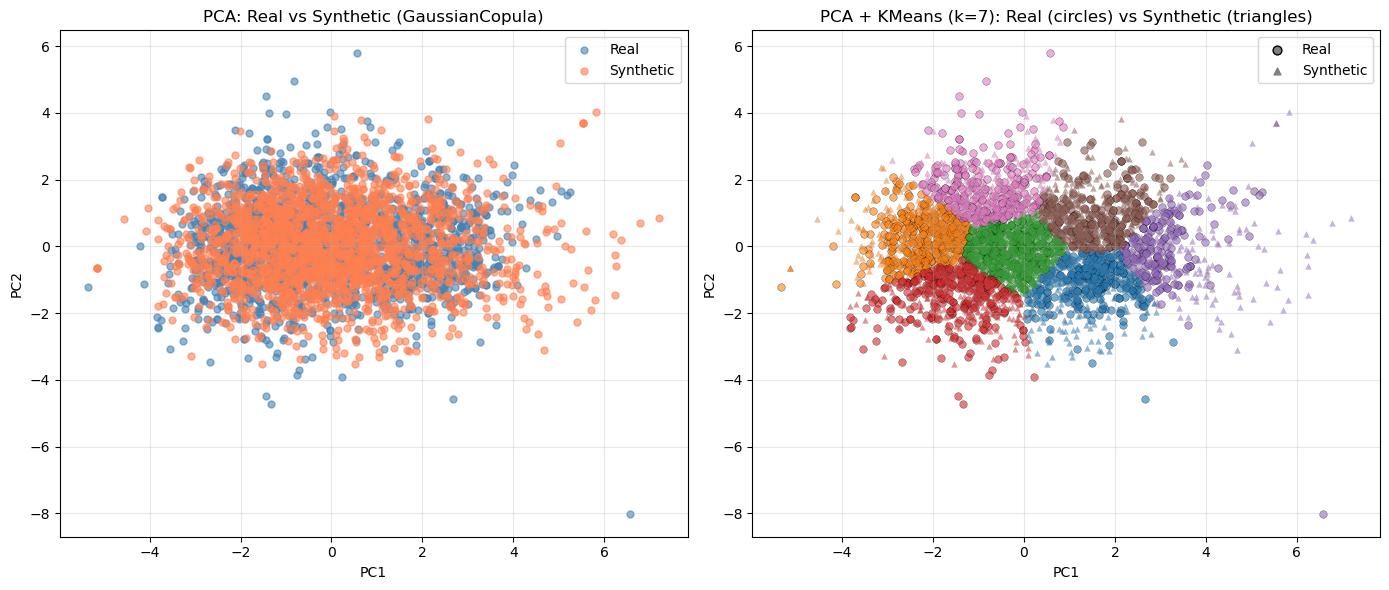

PCA explained variance ratio: [0.281 0.131]


In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

model_name = "GaussianCopula"
synth_df = synthetic_data[model_name]
num_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
n_sample = 2000
np.random.seed(42)
n_r = min(n_sample, len(wine_data))
n_s = min(n_sample, len(synth_df))
real_s = wine_data[num_cols].sample(n=n_r, random_state=42)
synth_s = synth_df[num_cols].sample(n=n_s, random_state=42)
X_real = real_s.to_numpy(float)
X_synth = synth_s.to_numpy(float)

scaler = StandardScaler().fit(X_real)
X_real_sc = scaler.transform(X_real)
X_synth_sc = scaler.transform(X_synth)
combined = np.vstack([X_real_sc, X_synth_sc])
pca = PCA(n_components=2, random_state=42).fit(combined)
Z = pca.transform(combined)
Z_real, Z_synth = Z[:n_r], Z[n_r:]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# (1) PCA: Real vs Synthetic
ax = axes[0]
ax.scatter(Z_real[:, 0], Z_real[:, 1], c='steelblue', alpha=0.6, label='Real', s=25)
ax.scatter(Z_synth[:, 0], Z_synth[:, 1], c='coral', alpha=0.6, label='Synthetic', s=25)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'PCA: Real vs Synthetic ({model_name})')
ax.legend()
ax.grid(True, alpha=0.3)

# (2) Clustering on PCA space: color = cluster, shape = Real (circles) vs Synthetic (triangles)
n_clusters = min(7, max(3, len(np.unique(wine_data['quality']))))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(Z)
labels_real = kmeans.predict(Z_real)
labels_synth = kmeans.predict(Z_synth)
ax = axes[1]
for k in range(n_clusters):
    mask_r = labels_real == k
    mask_s = labels_synth == k
    if mask_r.any():
        ax.scatter(Z_real[mask_r, 0], Z_real[mask_r, 1], c=f'C{k}', alpha=0.6, s=30, marker='o', edgecolors='black', linewidths=0.3)
    if mask_s.any():
        ax.scatter(Z_synth[mask_s, 0], Z_synth[mask_s, 1], c=f'C{k}', alpha=0.5, s=18, marker='^', edgecolors='gray', linewidths=0.2)
ax.scatter([], [], c='gray', s=40, marker='o', label='Real', edgecolors='black')
ax.scatter([], [], c='gray', s=24, marker='^', label='Synthetic', edgecolors='gray')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'PCA + KMeans (k={n_clusters}): Real (circles) vs Synthetic (triangles)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.round(3)}")

### PCA + Mahalanobis (GaussianCopula)

Same PCA 2D projection as above; points are then colored by **Mahalanobis distance** to the real-data distribution (fitted in PCA space). Lower distance (e.g. green) = closer to real distribution; higher (e.g. red) = farther. Real vs synthetic indicated by marker shape.

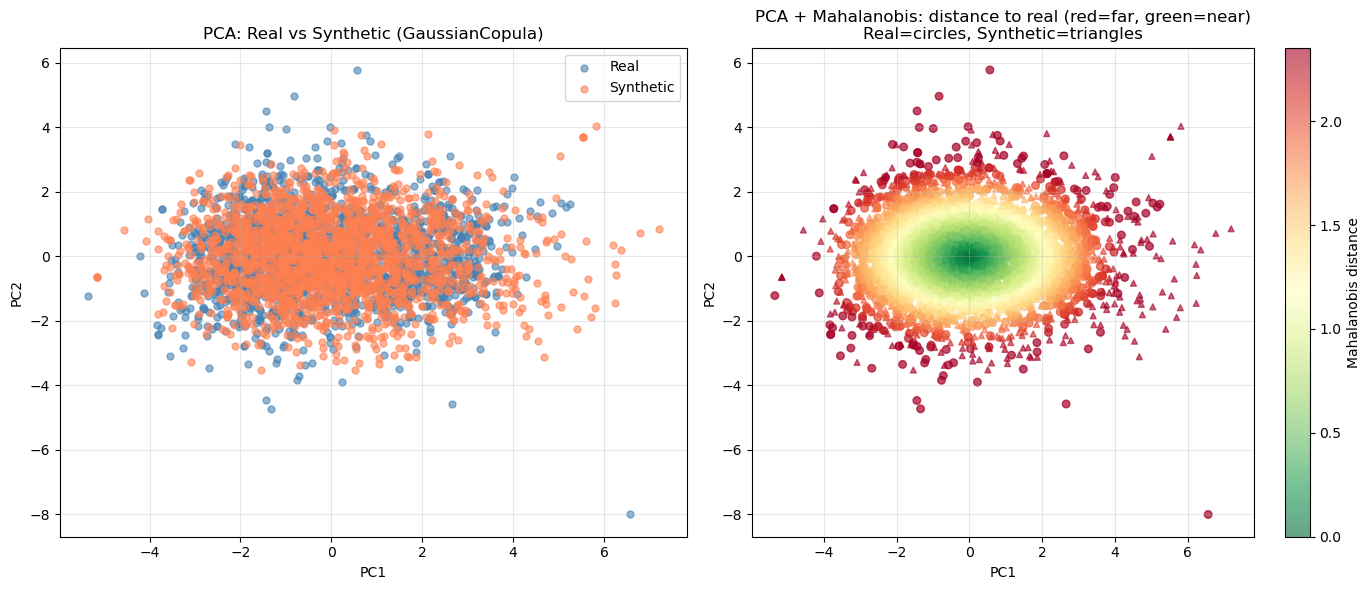

PCA explained variance: [0.281 0.131]
Real   — mean Mahalanobis (2D PCA): 1.2722
Synthetic — mean Mahalanobis (2D PCA): 1.2600


In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from numpy.linalg import inv, LinAlgError
import matplotlib.pyplot as plt

model_name = "GaussianCopula"
synth_df = synthetic_data[model_name]
num_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
n_sample = 2000
np.random.seed(42)
n_r = min(n_sample, len(wine_data))
n_s = min(n_sample, len(synth_df))
real_s = wine_data[num_cols].sample(n=n_r, random_state=42)
synth_s = synth_df[num_cols].sample(n=n_s, random_state=42)
X_real = real_s.to_numpy(float)
X_synth = synth_s.to_numpy(float)
scaler = StandardScaler().fit(X_real)
X_real_sc = scaler.transform(X_real)
X_synth_sc = scaler.transform(X_synth)
combined = np.vstack([X_real_sc, X_synth_sc])
pca = PCA(n_components=2, random_state=42).fit(combined)
Z = pca.transform(combined)
Z_real, Z_synth = Z[:n_r], Z[n_r:]

# Mahalanobis in PCA space: fit on real, compute distance for all points
def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    d2 = np.einsum('ij,jk,ik->i', delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0))
mu_z = np.mean(Z_real, axis=0)
cov_z = np.cov(Z_real, rowvar=False)
if cov_z.ndim == 0:
    cov_z = np.array([[cov_z]])
reg = 1e-6
try:
    inv_cov_z = inv(cov_z + reg * np.eye(2))
except LinAlgError:
    inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))
d_real = _mahal_dist_2d(Z_real, mu_z, inv_cov_z)
d_synth = _mahal_dist_2d(Z_synth, mu_z, inv_cov_z)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# (1) PCA: Real vs Synthetic
ax = axes[0]
ax.scatter(Z_real[:, 0], Z_real[:, 1], c='steelblue', alpha=0.6, label='Real', s=25)
ax.scatter(Z_synth[:, 0], Z_synth[:, 1], c='coral', alpha=0.6, label='Synthetic', s=25)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'PCA: Real vs Synthetic ({model_name})')
ax.legend()
ax.grid(True, alpha=0.3)

# (2) PCA colored by Mahalanobis distance to real distribution
ax = axes[1]
vmax = np.percentile(np.hstack([d_real, d_synth]), 95)
sc_r = ax.scatter(Z_real[:, 0], Z_real[:, 1], c=d_real, cmap='RdYlGn_r', alpha=0.7, s=30, marker='o', vmin=0, vmax=vmax)
sc_s = ax.scatter(Z_synth[:, 0], Z_synth[:, 1], c=d_synth, cmap='RdYlGn_r', alpha=0.6, s=18, marker='^', vmin=0, vmax=vmax)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'PCA + Mahalanobis: distance to real (red=far, green=near)\nReal=circles, Synthetic=triangles')
cbar = plt.colorbar(sc_s, ax=ax)
cbar.set_label('Mahalanobis distance')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"PCA explained variance: {pca.explained_variance_ratio_.round(3)}")
print(f"Real   — mean Mahalanobis (2D PCA): {d_real.mean():.4f}")
print(f"Synthetic — mean Mahalanobis (2D PCA): {d_synth.mean():.4f}")

### Mahalanobis + Hungarian mapping (GaussianCopula)

Same Mahalanobis distance and Hungarian optimal 1-to-1 matching applied to **GaussianCopula** synthetic data only, with graphical visualization: histogram of matched distances and summary statistics.

GaussianCopula — Mahalanobis + Hungarian (n=4898 pairs)
  Mean distance   = 2.1815
  Median distance = 2.0159
  Total distance  = 10685.1495

First 15 matched pairs (Real → Synthetic, Mahalanobis distance):
  R1 → S1107   d = 1.6410
  R2 → S1069   d = 2.0724
  R3 → S2219   d = 2.3187
  R4 → S3096   d = 1.2351
  R5 → S1018   d = 1.4222
  R6 → S1248   d = 2.1048
  R7 → S669   d = 1.9079
  R8 → S743   d = 2.3620
  R9 → S3752   d = 1.7394
  R10 → S1815   d = 1.6857
  R11 → S1638   d = 1.7555
  R12 → S1204   d = 1.3764
  R13 → S4747   d = 1.5274
  R14 → S4877   d = 2.2530
  R15 → S2840   d = 3.3692


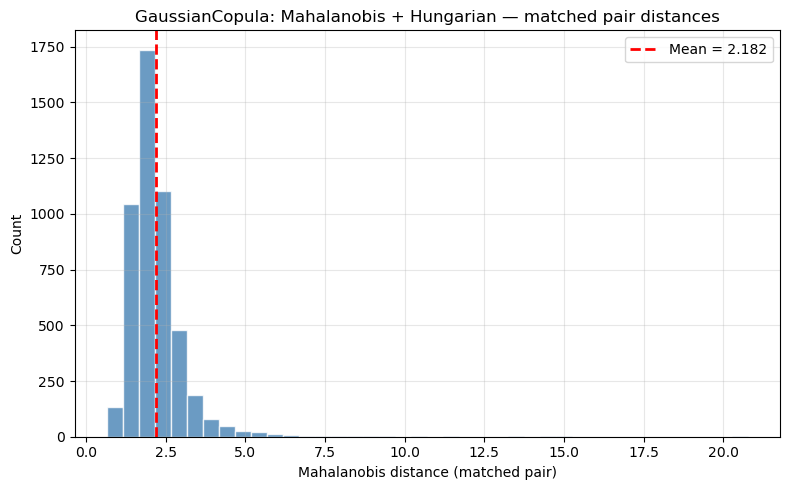

In [86]:
# Mahalanobis + Hungarian for GaussianCopula only (reuse params if available, else compute)
from numpy.linalg import inv, LinAlgError
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

def _fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = inv(cov + (reg * 10) * np.eye(p))
    return mu, inv_cov

model_name = "GaussianCopula"
num_cols_g = _num_cols_cos if '_num_cols_cos' in dir() else wine_data.select_dtypes(include=[np.number]).columns.tolist()
synth_df = synthetic_data[model_name]
cols = [c for c in num_cols_g if c in synth_df.columns]
if len(cols) != len(num_cols_g):
    cols = wine_data.select_dtypes(include=[np.number]).columns.tolist()
    cols = [c for c in cols if c in synth_df.columns]
R = wine_data[cols].to_numpy(float)
S = synth_df[cols].to_numpy(float)
n = min(R.shape[0], S.shape[0])
R, S = R[:n], S[:n]

if '_inv_cov_mahal' in dir() and R.shape[1] == _inv_cov_mahal.shape[0]:
    inv_cov = _inv_cov_mahal
else:
    _, inv_cov = _fit_mahalanobis_params(R)

D = cdist(R, S, metric="mahalanobis", VI=inv_cov)
row_ind, col_ind = linear_sum_assignment(D)
matched_d = D[row_ind, col_ind]

# Summary
print(f"GaussianCopula — Mahalanobis + Hungarian (n={n} pairs)")
print(f"  Mean distance   = {matched_d.mean():.4f}")
print(f"  Median distance = {np.median(matched_d):.4f}")
print(f"  Total distance  = {matched_d.sum():.4f}")
print("\nFirst 15 matched pairs (Real → Synthetic, Mahalanobis distance):")
for t in range(min(15, len(row_ind))):
    print(f"  R{row_ind[t]+1} → S{col_ind[t]+1}   d = {matched_d[t]:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(matched_d, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(matched_d.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {matched_d.mean():.3f}')
ax.set_xlabel('Mahalanobis distance (matched pair)')
ax.set_ylabel('Count')
ax.set_title(f'GaussianCopula: Mahalanobis + Hungarian — matched pair distances')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()